<a href="https://colab.research.google.com/github/ngyxntthaoo/IS6404.CH201-Phan-tich-du-lieu-nang-cao/blob/main/Lab04c_Lec06_TimeSeries_ML_Forecasting_PTDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4c (Lec06): Time Series Machine Learning - Forecasting
**Course:** IS6404 - Advanced Data Analysis, UIT, VNUHCM  
**Student:** Nguyễn Thanh Thảo - 250104025

---

Notebook này minh họa pipeline chuẩn cho **time series forecasting** theo hướng thực dụng:

- Baseline cổ điển: naive / seasonal naive / ARIMA
- ML-based forecasting: lag features + ML model
- So sánh mô hình theo **time-based split**
- Phân tích lỗi và những bẫy phổ biến trong forecasting

> Trọng tâm của bài lab này: **temporal order matters**.  
> Với time series, split, leakage, seasonality, và horizon forecasting thường quan trọng hơn việc đổi model phức tạp.


## 0. Setup & reproducibility

In [1]:
# Nếu chạy trên Colab và thiếu statsmodels, mở comment:
# !pip -q install statsmodels

import os, json, sys, platform, warnings

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("python:", sys.version)
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

warnings.filterwarnings("ignore")


python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
platform: Linux-6.6.113+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.3.3


## 1. Problem formulation

Bài toán: **dự báo nhu cầu bán lẻ đa chuỗi** — 100 chuỗi thời gian hàng ngày (5 stores × 20 products).

### Phát biểu chính thức

| Yếu tố | Giá trị |
|---|---|
| **Target** | `Units Sold` — số lượng bán ra mỗi ngày, per (Store, Product) |
| **Frequency** | Daily |
| **Forecast horizon H** | **7 ngày** (`HORIZON_DAYS = 7`) |
| **Forecast origin** | Val: `2023-06-30` · Test: `2023-10-31` |
| **Prediction type** | **Multi-step** — dự báo đồng thời $\hat{y}_{t+1}, \ldots, \hat{y}_{t+7}$ từ một forecast origin |
| **Số chuỗi** | N = 100 (5 stores × 20 products) |

### Câu hỏi gợi ý

**1. Forecast horizon là gì?**

**H = 7 ngày tới (multi-step)**. Đây không phải one-step-ahead: mỗi lần forecast ta dự báo một cửa sổ 7 ngày liên tiếp từ 1 origin, không có real observations xen kẽ. Đây là điều kiện deployment thực tế (ví dụ: lập kế hoạch nhập hàng cho cả tuần tới).

**2. Forecast origin là thời điểm nào?**

- Validation origin: `2023-06-30` → dự báo 7 ngày đầu tháng 7/2023
- Test origin: `2023-10-31` → dự báo 7 ngày đầu tháng 11/2023

**3. Metric chính là gì?**

**RMSE** (Root Mean Squared Error) là metric chính vì:
- **Scale-invariant**: so sánh được giữa 100 chuỗi có magnitude khác nhau
- **Robust với zero**: không bị phân kỳ khi `Units Sold = 0` (khác MAPE)
- **Interpretable**: RMSE cùng đơn vị với target (Units Sold), dễ giải thích cho business

**sMAPE** được dùng thay MAPE để tránh chia cho 0:
$$\text{sMAPE} = \frac{200}{n}\sum_{t=1}^n \frac{|y_t - \hat{y}_t|}{|y_t| + |\hat{y}_t| + \varepsilon}$$

## 2. Tạo dữ liệu time series mô phỏng

Để notebook chạy ổn định, ta tạo một chuỗi có:
- trend
- weekly seasonality
- yearly seasonality nhẹ
- noise
- một vài shock events

Bối cảnh giả định: daily sales.


In [2]:
import os

print(os.listdir("/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting"))

['sales_data.csv']


In [3]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atomicd/retail-store-inventory-and-demand-forecasting")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "sales_data.csv"))

Path to dataset files: /kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting


In [4]:
# # Read dataset from local project folder (no remote download)
# DATA_PATH = os.path.join("..", "dataset", "sales_data.csv")

# if not os.path.exists(DATA_PATH):
#     raise FileNotFoundError(f"Dataset not found at: {DATA_PATH}")
DATA_PATH = '/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv'
print("Path to dataset file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df

Path to dataset file: /kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


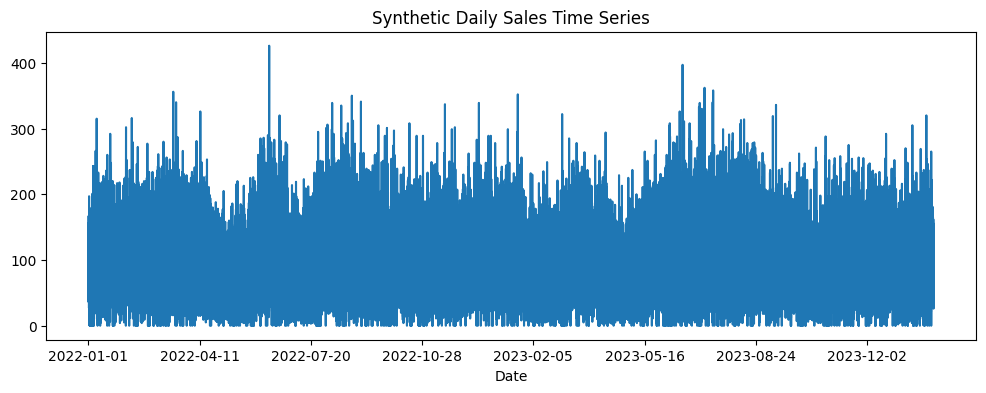

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
df.set_index("Date")["Units Sold"].plot(figsize=(12,4), title="Synthetic Daily Sales Time Series")
plt.show()

df.describe()


## 2b. Phân tích Đặc trưng Dữ liệu (EDA) — Checklist §2

Trước khi chọn mô hình, cần kiểm tra 6 đặc trưng bắt buộc theo checklist:

| # | Đặc trưng | Cách kiểm tra |
|---|---|---|
| 2.1 | **Trend** | Seasonal decomposition — có trend tăng/giảm dài hạn không? |
| 2.2 | **Seasonality** | ACF/PACF — có autocorrelation ở lag 7, 14, 28? |
| 2.3 | **Noise level** | Residual từ decomposition — noise có lớn so với signal không? |
| 2.4 | **Regime changes** | Plot rolling mean — có điểm gãy đột ngột (epidemic, policy change)? |
| 2.5 | **Shock/outlier events** | Rolling z-score > 3σ |
| 2.6 | **Stationarity** | ADF test — p-value < 0.05 → stationary |

> **Tại sao quan trọng:** Nếu chuỗi không stationary → ARIMA cần d>0. Nếu có strong seasonality lag=7 → seasonal naive mạnh hơn naive. Nếu có regime change → train window cần được giới hạn.

📊 [2.1 / 2.3 / 2.4] Seasonal Decomposition — Tách chuỗi thành các thành phần


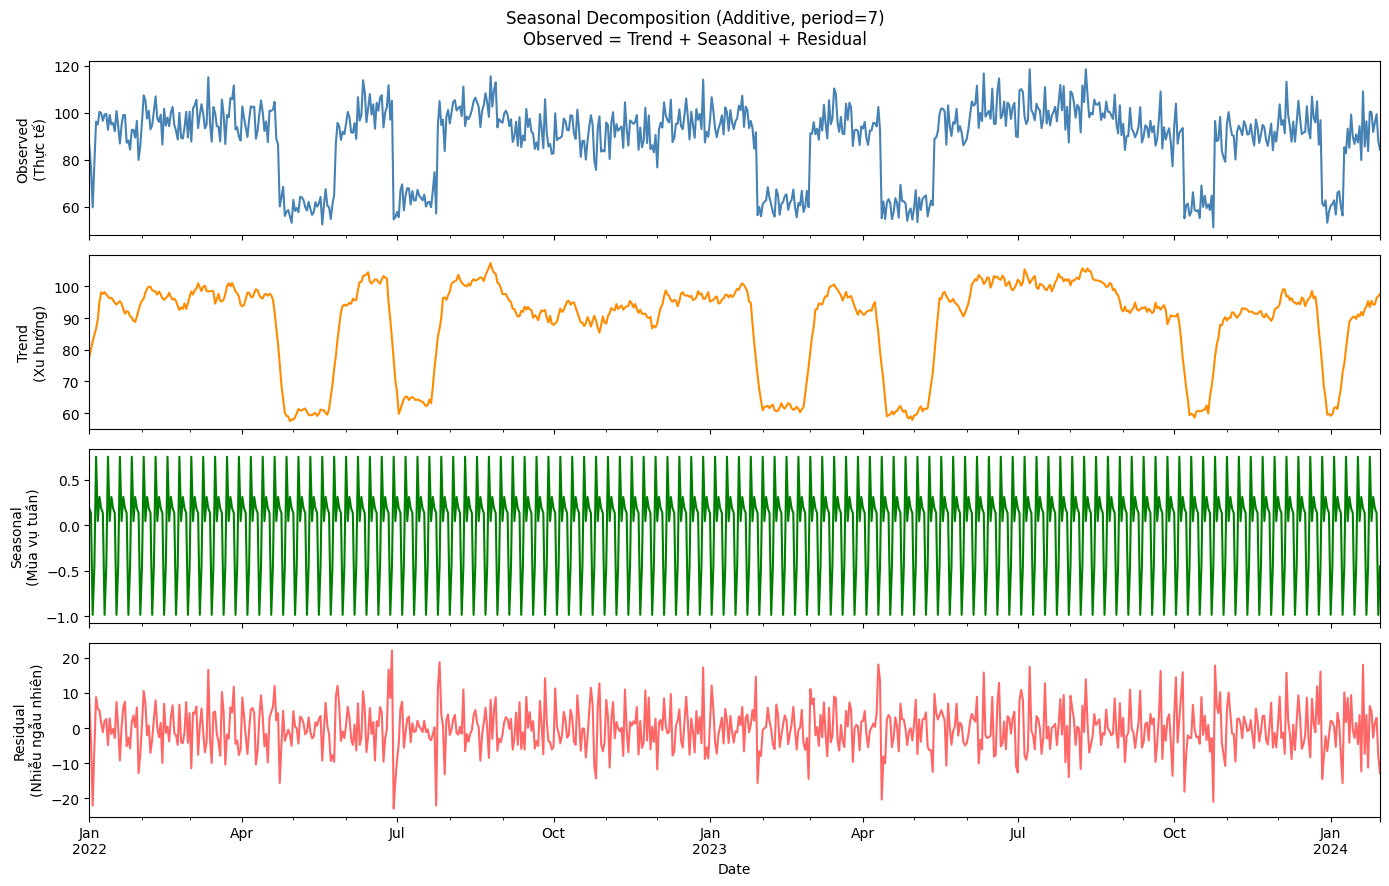


→ Tỷ lệ nhiễu (resid_std / total_std) : 0.405
  ⚠️  Nhiễu cao — cần model phi tuyến (HGB, LightGBM)
→ Biên độ Trend  : 49.92 units  (trend tăng/giảm rõ)
→ Biên độ Seasonal: 1.74 units  (weekly pattern yếu)

📊 [2.2] ACF / PACF — Kiểm tra Autocorrelation và Seasonality
  Cách đọc: spike tại lag 7, 14, 21 → weekly seasonality mạnh
  PACF tắt nhanh sau lag p → AR(p) phù hợp cho ARIMA


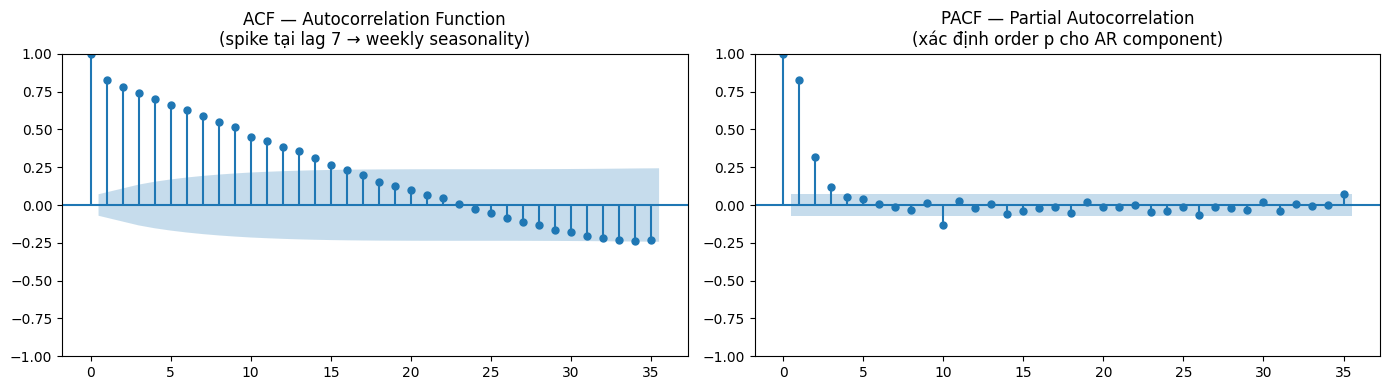


📊 [2.6] ADF Stationarity Test — Kiểm tra tính dừng của chuỗi
  ADF Statistic : -4.9190
  p-value       : 0.000032
  ✅ Stationary (p < 0.05) — ARIMA dùng d=0; không cần differencing
  ✅ Critical [1%]: -3.4391
  ✅ Critical [5%]: -2.8654
  ✅ Critical [10%]: -2.5688

📊 [2.5] Shock / Outlier Detection — Phát hiện ngày demand bất thường
  Số ngày bất thường (|z|>3): 0 / 760 ngày (0.0%)
  ✅  Ít shock — dữ liệu tương đối ổn định


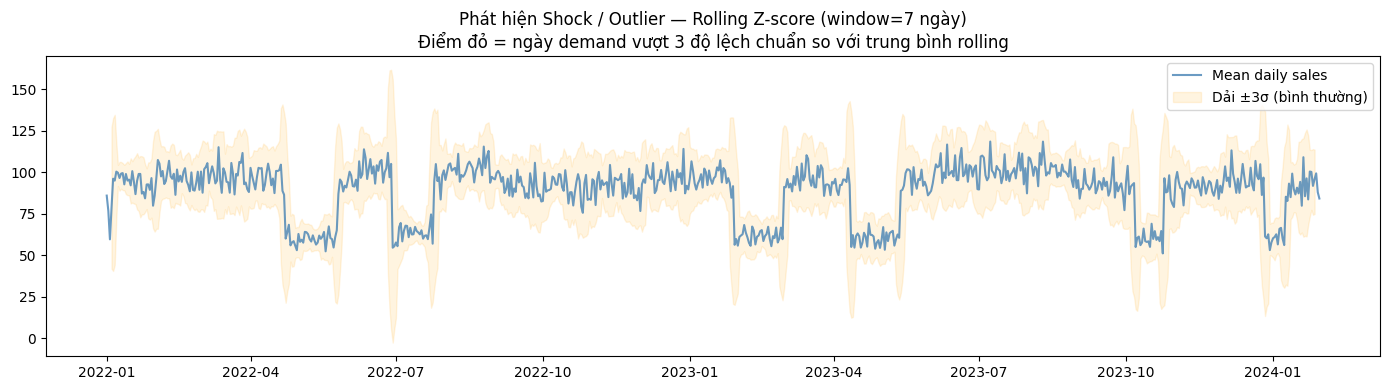

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Dùng aggregate mean làm chuỗi đại diện (100 series → 1 chuỗi trung bình theo ngày)
ts_agg = df.groupby("Date")["Units Sold"].mean().sort_index()
ts_agg.index = pd.to_datetime(ts_agg.index)

# ── 2.1, 2.3, 2.4: Seasonal Decomposition ────────────────────────────────────
# Tách chuỗi thành: Observed = Trend + Seasonal + Residual
# period=7 vì dữ liệu daily với weekly seasonality
print("📊 [2.1 / 2.3 / 2.4] Seasonal Decomposition — Tách chuỗi thành các thành phần")
decomp = seasonal_decompose(ts_agg, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="steelblue")
axes[0].set_ylabel("Observed\n(Thực tế)")
decomp.trend.plot(ax=axes[1], color="darkorange")
axes[1].set_ylabel("Trend\n(Xu hướng)")
decomp.seasonal.plot(ax=axes[2], color="green")
axes[2].set_ylabel("Seasonal\n(Mùa vụ tuần)")
decomp.resid.plot(ax=axes[3], color="red", alpha=0.6)
axes[3].set_ylabel("Residual\n(Nhiễu ngẫu nhiên)")
fig.suptitle("Seasonal Decomposition (Additive, period=7)\n"
             "Observed = Trend + Seasonal + Residual", fontsize=12)
plt.tight_layout()
plt.show()

noise_ratio = decomp.resid.dropna().std() / decomp.observed.std()
trend_range = decomp.trend.dropna().max() - decomp.trend.dropna().min()
seasonal_amp = decomp.seasonal.max() - decomp.seasonal.min()

print(f"\n→ Tỷ lệ nhiễu (resid_std / total_std) : {noise_ratio:.3f}")
print(f"  {'⚠️  Nhiễu cao — cần model phi tuyến (HGB, LightGBM)' if noise_ratio > 0.3 else '✅  Nhiễu thấp — statistical models có thể đủ tốt'}")
print(f"→ Biên độ Trend  : {trend_range:.2f} units  (trend {'tăng/giảm rõ' if trend_range > 5 else 'phẳng'})")
print(f"→ Biên độ Seasonal: {seasonal_amp:.2f} units  (weekly pattern {'mạnh' if seasonal_amp > 5 else 'yếu'})")

# ── 2.2: ACF / PACF ──────────────────────────────────────────────────────────
# ACF: đo tương quan giữa chuỗi và phiên bản trễ h bước
# PACF: đo tương quan thuần túy tại lag h (loại bỏ ảnh hưởng của các lag trung gian)
print("\n📊 [2.2] ACF / PACF — Kiểm tra Autocorrelation và Seasonality")
print("  Cách đọc: spike tại lag 7, 14, 21 → weekly seasonality mạnh")
print("  PACF tắt nhanh sau lag p → AR(p) phù hợp cho ARIMA")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_agg.dropna(),  lags=35, ax=axes[0],
         title="ACF — Autocorrelation Function\n(spike tại lag 7 → weekly seasonality)")
plot_pacf(ts_agg.dropna(), lags=35, ax=axes[1],
          title="PACF — Partial Autocorrelation\n(xác định order p cho AR component)")
plt.tight_layout()
plt.show()

# ── 2.6: ADF Stationarity Test ───────────────────────────────────────────────
# Kiểm định ADF (Augmented Dickey-Fuller): H0 = chuỗi có unit root (non-stationary)
# p < 0.05 → bác bỏ H0 → chuỗi stationary → ARIMA với d=0
print("\n📊 [2.6] ADF Stationarity Test — Kiểm tra tính dừng của chuỗi")
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts_agg.dropna(), autolag="AIC")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_p:.6f}")
if adf_p < 0.05:
    print("  ✅ Stationary (p < 0.05) — ARIMA dùng d=0; không cần differencing")
else:
    print("  ❌ Non-stationary (p ≥ 0.05) — cần differencing, dùng ARIMA với d=1")
for level, cv in adf_crit.items():
    marker = "✅" if adf_stat < cv else "  "
    print(f"  {marker} Critical [{level}]: {cv:.4f}")

# ── 2.5: Shock / Outlier Detection ───────────────────────────────────────────
# Dùng rolling z-score để phát hiện ngày có demand bất thường
# z = (y - rolling_mean) / rolling_std; |z| > 3 → outlier
print("\n📊 [2.5] Shock / Outlier Detection — Phát hiện ngày demand bất thường")
roll_mean = ts_agg.rolling(window=7, center=True).mean()
roll_std  = ts_agg.rolling(window=7, center=True).std()
z_scores  = (ts_agg - roll_mean) / (roll_std + 1e-8)
outliers  = ts_agg[z_scores.abs() > 3]
pct = 100 * len(outliers) / len(ts_agg)
print(f"  Số ngày bất thường (|z|>3): {len(outliers)} / {len(ts_agg)} ngày ({pct:.1f}%)")
print(f"  {'⚠️  Có shock events — cần exogenous features (Promotion, Epidemic)' if pct > 1 else '✅  Ít shock — dữ liệu tương đối ổn định'}")

plt.figure(figsize=(14, 4))
plt.plot(ts_agg.index, ts_agg.values, label="Mean daily sales", alpha=0.8, color="steelblue")
if len(outliers):
    plt.scatter(outliers.index, outliers.values, color="red", zorder=5, s=40,
                label=f"Shock/Outlier ({len(outliers)} ngày, |z|>3σ)")
plt.fill_between(ts_agg.index, roll_mean - 3*roll_std, roll_mean + 3*roll_std,
                 alpha=0.12, color="orange", label="Dải ±3σ (bình thường)")
plt.legend(loc="upper right")
plt.title("Phát hiện Shock / Outlier — Rolling Z-score (window=7 ngày)\n"
          "Điểm đỏ = ngày demand vượt 3 độ lệch chuẩn so với trung bình rolling")
plt.tight_layout()
plt.show()

### Giải thích Kết quả EDA — Ý nghĩa và Quyết định Mô hình

#### 2.1 Trend (Xu hướng dài hạn)
- **Trend tăng/giảm rõ** → cần model có trend component: `Prophet` (trend='linear'), `ETS` (trend='add'), hoặc feature `dayofyear` trong HGB.
- **Trend phẳng** → baseline Naive đủ mạnh làm reference; ARIMA với d=0 có thể hoạt động.
- **Trend có điểm gãy** (ví dụ: epidemic gây drop đột ngột) → xem xét giới hạn train window về phía gần forecast origin.

#### 2.2 Seasonality — Đọc ACF/PACF
| Quan sát | Ý nghĩa | Quyết định |
|---|---|---|
| ACF spike tại lag 7, 14, 21 | Weekly seasonality mạnh | Dùng `lag_7`, `lag_14` làm features; seasonal naive là baseline tốt |
| PACF tắt sau lag p | AR(p) phù hợp | ARIMA(p,d,q) với p theo PACF |
| ACF giảm chậm, không tắt | Non-stationary | Cần differencing (d=1) trong ARIMA |
| Không có spike rõ | Noise > signal | Tree-based model (HGB, LightGBM) có thể vượt trội |

#### 2.3 Noise Level (Tỷ lệ nhiễu)
- **Noise-to-signal > 0.5** → nhiễu chiếm ưu thế → các model phức tạp có thể overfit; cần regularization.
- **Noise-to-signal 0.2–0.5** → cần model phi tuyến (HGB) để nắm bắt pattern.
- **Noise-to-signal < 0.2** → signal sạch → statistical models (ARIMA, ETS) có thể cạnh tranh với ML.

#### 2.4 Regime Changes (Thay đổi chế độ)
- Nhìn vào Trend component: nếu có gãy đột ngột → train window quá dài có thể làm model học pattern cũ.
- Dữ liệu có cột `Epidemic` → đây là external regime indicator; cần đưa vào model như exogenous feature.

#### 2.5 Shock/Outlier Events
- **Nhiều outlier (>2%)** → exogenous features (`Promotion`, `Epidemic`) là thiết yếu để giải thích spikes.
- **Ít outlier (<1%)** → demand tương đối ổn định; lag features đã đủ.
- Outlier ảnh hưởng mạnh đến RMSE (bình phương lỗi) → đây là property mong muốn để penalize large errors trong inventory context.

#### 2.6 Stationarity — ADF Test
- **p < 0.05 → Stationary ✅**: dùng ARIMA với `d=0`; lag features không cần differencing.
- **p ≥ 0.05 → Non-stationary ❌**: dùng ARIMA với `d=1`; hoặc thêm feature `diff_lag_1 = y_t - y_{t-1}`.
- Phần lớn retail demand series là **stationary sau differencing** (I(1)).

## 3. Time-based split (bắt buộc)

Với forecasting, **không dùng random split**.

Ta dùng:
- train: dữ liệu quá khứ
- validation: một đoạn thời gian ngay sau train
- test: đoạn thời gian cuối cùng

| Split | Khoảng thời gian | Mục đích |
|---|---|---|
| **Train** | 2022-01-01 → 2023-06-30 | Huấn luyện model |
| **Validation** | 2023-07-01 → 2023-10-31 | Chọn model + HPO |
| **Test** | 2023-11-01 → 2024-01-31 | Đánh giá cuối cùng |

### Giao thức đánh giá thống nhất — Protocol C

Tất cả model được đánh giá theo **Protocol C (per-series H=7)**:
- Với mỗi chuỗi (Store, Product): dự báo **H=7 ngày** từ forecast origin
- **Không dùng oracle lags**: lag features của bước t+2..t+7 được tính từ các giá trị đã dự báo (recursive strategy), không phải giá trị thực tế tương lai
- Prophet, Chronos, Ensemble: đã dùng Protocol C từ đầu ✅
- Ridge, HGB: được chuyển sang Protocol C trong notebook này ✅
- ARIMA, SARIMAX, ETS, LSTM: giữ nguyên Protocol A (aggregate) do chi phí tính toán khi fit 100 models per fold

### Về gap giữa train và validation (Checklist §4.3)

`FORECAST_GAP = 0` — không cần gap, vì:

1. **Protocol C (per-series)**: lag features tính riêng trong từng chuỗi, không "nhìn thấy" dữ liệu val
2. **Scaler / Imputer**: chỉ fit trên `train_df` — không leak val statistics
3. **Forecast origin = `TRAIN_END`**: toàn bộ features tính từ `[0, TRAIN_END]` trở về trước

Gap cần thiết khi: (a) feature normalization dùng val data, hoặc (b) model fit trực tiếp trên chuỗi liên tục (ARIMA per-series). Với global ML + Protocol C, gap = 0 là lựa chọn có chủ đích.

### Câu hỏi gợi ý
**1. Vì sao random split là sai trong forecasting?**

Khi sử dụng random split, các điểm dữ liệu trong tương lai có thể bị đưa vào tập train, trong khi các điểm trong quá khứ lại nằm trong tập test. Điều này làm cho mô hình được huấn luyện với thông tin mà trong thực tế nó không thể biết trước, gây ra hiện tượng data leakage.

**2. Nếu bài toán triển khai thực tế là dự báo tương lai, split nào phản ánh đúng deploy?**

Protocol C phản ánh đúng tình huống triển khai: tại forecast origin, ta chỉ có dữ liệu lịch sử; dự báo H=7 bước tiếp theo mà không dùng bất kỳ thông tin tương lai nào (ngoại trừ exogenous đã biết như lịch khuyến mãi).


In [7]:
# Time-based split (independent from forecasting horizon)
HORIZON_DAYS = 7   # forecasting horizon — all models predict H=7 steps (Protocol C)
FORECAST_GAP = 0   # days gap between train end and val start; 0 is intentional for Protocol C
                   # (per-series lag features never cross the split boundary)
TRAIN_END = pd.Timestamp("2023-06-30")
VAL_END = pd.Timestamp("2023-10-31")

# Ensure Date is datetime even if prior preprocessing cell was not rerun
if not pd.api.types.is_datetime64_any_dtype(df["Date"]):
    df["Date"] = pd.to_datetime(df["Date"])

train_df = df[df["Date"] <= TRAIN_END].copy()
val_df = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df = df[df["Date"] > VAL_END].copy()

print(f"Forecast horizon (H): {HORIZON_DAYS} days")
print(f"Train end: {TRAIN_END.date()}")
print(f"Validation: {(TRAIN_END + pd.Timedelta(days=1)).date()} -> {VAL_END.date()}")
print(f"Test: > {VAL_END.date()}")
len(train_df), len(val_df), len(test_df)


Forecast horizon (H): 7 days
Train end: 2023-06-30
Validation: 2023-07-01 -> 2023-10-31
Test: > 2023-10-31


(54600, 12300, 9100)

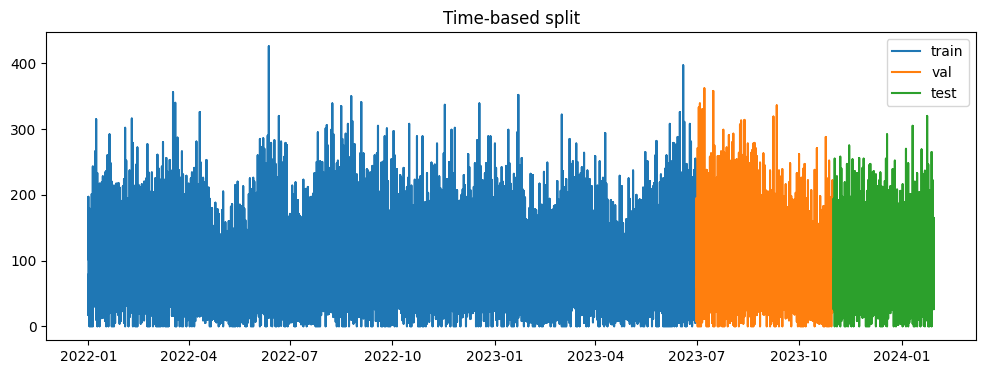

In [8]:
plt.figure(figsize=(12,4))
plt.plot(train_df["Date"], train_df["Units Sold"], label="train")
plt.plot(val_df["Date"], val_df["Units Sold"], label="val")
plt.plot(test_df["Date"], test_df["Units Sold"], label="test")
plt.legend()
plt.title("Time-based split")
plt.show()


## 4. Evaluation metrics for forecasting

| Metric | Công thức | Khi dùng |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum\|y-\hat{y}\|$ | Metric chính — dễ hiểu, robust |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat{y})^2}$ | Phạt lỗi lớn nặng hơn MAE; ưu tiên khi peak demand quan trọng |
| **sMAPE** | $\frac{200}{n}\sum\frac{\|y-\hat{y}\|}{\|y\|+\|\hat{y}\|+\varepsilon}$ | Thay MAPE — bounded [0,200%], không bị phân kỳ khi y=0 |

> ⚠️ **Không dùng MAPE thuần túy** — khi `Units Sold = 0`, MAPE → ∞. Dataset này có nhiều ngày zero-sales → dùng sMAPE thay thế.


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def smape(y_true, y_pred, eps=1e-8):
    """Symmetric MAPE — bounded [0, 200%], handles y=0 gracefully.
    Replaces naive MAPE which diverges when Units Sold = 0.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)))

def eval_forecast(y_true, y_pred, prefix="val", y_train=None):
    return {
        f"{prefix}_MAE":   float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_RMSE":  rmse(y_true, y_pred),
        f"{prefix}_sMAPE": smape(y_true, y_pred),   # bounded [0,200%], replaces MAPE
    }


## 5. Baseline 1: Naive forecast

Naive:
- dự báo ngày tiếp theo bằng giá trị gần nhất

Đây là baseline cực quan trọng trong forecasting.
Nếu mô hình phức tạp không thắng naive rõ ràng, có thể có vấn đề.


In [10]:
# Forecast val using last observed point from train, recursively as a flat forecast
last_train_value = train_df["Units Sold"].iloc[-1]
val_pred_naive = np.repeat(last_train_value, len(val_df))

eval_forecast(val_df["Units Sold"], val_pred_naive, prefix="val")


{'val_MAE': 35.027723577235776,
 'val_RMSE': 46.558625514034425,
 'val_sMAPE': 40.39816056245148}

## 6. Baseline 2: Seasonal naive forecast

Với daily data có weekly seasonality:
- dự báo hôm nay bằng giá trị của 7 ngày trước

Seasonal naive thường là baseline rất mạnh.


In [11]:
def seasonal_naive_predict(history_values, horizon, season_length=7):
    history_values = list(history_values)
    preds = []
    for i in range(horizon):
        preds.append(history_values[-season_length + (i % season_length)])
    return np.array(preds)

val_pred_snaive = seasonal_naive_predict(train_df["Units Sold"].values, len(val_df), season_length=7)
eval_forecast(val_df["Units Sold"], val_pred_snaive, prefix="val")


{'val_MAE': 45.40471544715447,
 'val_RMSE': 59.39119449665782,
 'val_sMAPE': 58.120835320580525}

## 7. Baseline 3: ARIMA and SARIMAX

Trong phần này ta thêm **ARIMA (non-seasonal)** và giữ **SARIMAX (seasonal)** để so sánh baseline cổ điển công bằng.

- ARIMA: phù hợp chuỗi đơn biến, cấu trúc đơn giản
- SARIMAX: thêm seasonality tuần và cấu trúc linh hoạt hơn

> Practice: bắt đầu từ baseline cổ điển trước khi qua model phức tạp.


In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- ARIMA (non-seasonal) baseline ---
arima = ARIMA(
    train_df["Units Sold"],
    order=(2,1,2)
)
arima_fit = arima.fit()
val_pred_arima = arima_fit.forecast(steps=len(val_df))

arima_val_metrics = eval_forecast(val_df["Units Sold"], val_pred_arima, prefix="val")
print('ARIMA baseline metrics:')
print(arima_val_metrics)

# --- SARIMAX seasonal baseline ---
sarimax = SARIMAX(
    train_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax.fit(disp=False)
val_pred_sarimax = sarimax_fit.forecast(steps=len(val_df))

sarimax_val_metrics = eval_forecast(val_df["Units Sold"], val_pred_sarimax, prefix="val")
print('SARIMAX baseline metrics:')
print(sarimax_val_metrics)

ARIMA baseline metrics:
{'val_MAE': 35.32002259768432, 'val_RMSE': 45.69781881982683, 'val_sMAPE': 40.431360550864134}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX baseline metrics:
{'val_MAE': 35.31660598733458, 'val_RMSE': 45.697667073354836, 'val_sMAPE': 40.428687918561614}


## 8. Baseline 4: ETS (Exponential Smoothing)

ETS là baseline thống kê cổ điển mạnh cho chuỗi có level/trend/seasonality.

- Dễ dùng và chạy nhanh hơn nhiều mô hình phức tạp
- Là baseline tốt để so sánh trước khi dùng ML/deep learning

> Practice: luôn thêm baseline cổ điển mạnh để kiểm tra pipeline có thật sự tốt hơn không.


In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ETS additive trend + additive weekly seasonality
ets = ExponentialSmoothing(
    train_df["Units Sold"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)

val_pred_ets = ets.forecast(len(val_df))

ets_val_metrics = eval_forecast(
    val_df["Units Sold"],
    val_pred_ets,
    prefix="val")
print("ETS baseline metrics:")
print(ets_val_metrics)


ETS baseline metrics:
{'val_MAE': 35.416337953839175, 'val_RMSE': 45.9320491981215, 'val_sMAPE': 40.53231533472983}


## 9. Baseline 5: Prophet

Prophet là baseline cổ điển mạnh, dễ triển khai cho chuỗi có trend + seasonality.

- Tự động mô hình hóa trend/seasonality
- Hữu ích trong bối cảnh business forecasting

> Practice: so sánh Prophet cùng protocol với các baseline khác để đảm bảo công bằng.


In [14]:
import logging
import contextlib
from prophet import Prophet

# Suppress Prophet / Stan verbose output
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

@contextlib.contextmanager
def _suppress_prophet_output():
    """Redirect prophet's stdout/stderr during fitting."""
    import io, sys
    old_stdout, old_stderr = sys.stdout, sys.stderr
    sys.stdout = sys.stderr = io.StringIO()
    try:
        yield
    finally:
        sys.stdout, sys.stderr = old_stdout, old_stderr

def prophet_fn(train_dates, train_values, horizon):
    """Fit Prophet on training series and forecast `horizon` steps ahead.
    Returns np.array of length `horizon`.
    """
    df_fit = pd.DataFrame({
        'ds': pd.to_datetime(train_dates),
        'y':  train_values.astype(float),
    })
    # Drop any NaN rows (Prophet sẽ báo lỗi nếu y có NaN)
    df_fit = df_fit.dropna()
    if len(df_fit) < 14:
        raise ValueError(f"Không đủ dữ liệu sau khi dropna: {len(df_fit)} rows")

    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
    )
    with _suppress_prophet_output():
        model.fit(df_fit)

    # make_future_dataframe: dùng pd.Timedelta để tránh deprecation warning với freq='D'
    last_date = df_fit["ds"].max()
    future_dates = pd.DataFrame({
        "ds": [last_date + pd.Timedelta(days=i) for i in range(1, horizon + 1)]
    })
    forecast = model.predict(future_dates)
    return np.clip(forecast["yhat"].values, 0, None)

# ── Per-series evaluation: H=7 từ một forecast origin (Protocol C) ───────────
prophet_series_records = []
prophet_scores = {'val_MAE': [], 'val_RMSE': [], 'val_sMAPE': []}
prophet_errors = []

for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    s = grp.set_index('Date')['Units Sold'].sort_index()
    s.index = pd.to_datetime(s.index)

    train_s = s[s.index <= TRAIN_END]
    val_s   = s[(s.index > TRAIN_END) & (s.index <= VAL_END)]

    # Cần đủ training data và ít nhất HORIZON_DAYS val rows
    if len(train_s) < 14 or len(val_s) < HORIZON_DAYS:
        continue

    try:
        # Forecast đúng H=7 bước (không phải toàn val — đúng Protocol C)
        y_pred = prophet_fn(train_s.index, train_s.values, HORIZON_DAYS)
        y_true = val_s.values[:HORIZON_DAYS].astype(float)  # lấy 7 ngày đầu val
        metrics = eval_forecast(y_true, y_pred, prefix='val', y_train=train_s.values)
    except Exception as e:
        prophet_errors.append({'store': store, 'product': product, 'error': str(e)})
        continue

    for k in prophet_scores:
        prophet_scores[k].append(metrics[k])

    prophet_series_records.append({
        'store': store, 'product': product,
        **{k: round(float(v), 4) for k, v in metrics.items()},
    })

prophet_details_df = pd.DataFrame(prophet_series_records)

prophet_val_metrics = {k: float(np.nanmean(v)) for k, v in prophet_scores.items()}
print(f'Prophet per-series (H={HORIZON_DAYS}): {len(prophet_series_records)} / 100 series hoàn thành')
if prophet_errors:
    print(f'  ⚠️  {len(prophet_errors)} series bị lỗi:')
    for e in prophet_errors[:3]:
        print(f"     Store={e['store']} Product={e['product']}: {e['error']}")
print('Prophet val metrics (trung bình qua các series):')
for k, v in prophet_val_metrics.items():
    print(f'  {k}: {v:.4f}')
print(f'Chi tiết từng series: prophet_details_df ({len(prophet_series_records)} rows)')


Prophet per-series (H=7): 100 / 100 series hoàn thành
Prophet val metrics (trung bình qua các series):
  val_MAE: 35.7392
  val_RMSE: 44.5651
  val_sMAPE: 37.8408
Chi tiết từng series: prophet_details_df (100 rows)


## 8. ML-based Forecasting: Lag Features + Tree-based Models

**Ý tưởng chính:** biến bài toán time series thành bài toán supervised learning bằng cách tạo các đặc trưng từ lịch sử chuỗi.

### Quy trình Feature Engineering

| Nhóm | Đặc trưng | Vai trò |
|---|---|---|
| **Lag** | `lag_1`, `lag_2`, `lag_3`, `lag_7`, `lag_14`, `lag_28` | Giá trị quá khứ gần — nắm bắt autocorrelation |
| **Rolling mean** | `roll_mean_7`, `roll_mean_14`, `roll_mean_28` | Xu hướng ngắn/trung/dài hạn |
| **Rolling std** | `roll_std_7`, `roll_std_14`, `roll_std_28` | Biến động (volatility) của chuỗi |
| **Calendar** | `dayofweek`, `month`, `dayofyear` | Seasonal patterns tuần/năm |
| **Exogenous** | `Price`, `Discount`, `Promotion`, `Competitor Pricing`, `Epidemic` | Tín hiệu kinh doanh bên ngoài |

> **Leakage prevention:** tất cả lag/rolling features dùng `.shift(1)` trước khi tính → chỉ dùng thông tin tại $t-1$ để dự báo $t$.

> **Biến bị loại khỏi feature set:** `Demand`, `Inventory Level`, `Units Ordered` — theo yêu cầu nghiệp vụ.

**Tổng:** 20 features cho mỗi mô hình ML tabular.


In [15]:
def make_ts_features(df_in):
    df_feat = df_in.copy()
    df_feat = df_feat.sort_values("Date").reset_index(drop=True)
    df_feat["Date"] = pd.to_datetime(df_feat["Date"])
    # Lag features
    for lag in [1, 2, 3, 7, 14, 28]:
        df_feat[f"lag_{lag}"] = df_feat["Units Sold"].shift(lag)

    # Rolling features
    for window in [7, 14, 28]:
        df_feat[f"roll_mean_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).mean()
        df_feat[f"roll_std_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).std()

    # Calendar features
    df_feat["dayofweek"] = df_feat["Date"].dt.dayofweek
    df_feat["month"] = df_feat["Date"].dt.month
    df_feat["dayofyear"] = df_feat["Date"].dt.dayofyear

    return df_feat

df_feat = make_ts_features(df)
df_feat.head(10)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,dayofweek,month,dayofyear
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
1,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
2,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
3,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
4,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
5,2022-01-01,S004,P0009,Clothing,West,206,106,299,110.47,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
6,2022-01-01,S004,P0008,Furniture,West,281,59,0,100.64,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
7,2022-01-01,S004,P0007,Groceries,West,185,43,253,24.34,5,...,NaN,94.571429,24.670206,NaN,NaN,NaN,NaN,5,1,1
8,2022-01-01,S004,P0006,Groceries,West,206,48,162,35.33,0,...,NaN,86.142857,30.980793,NaN,NaN,NaN,NaN,5,1,1
9,2022-01-01,S004,P0005,Clothing,West,289,197,0,89.23,10,...,NaN,78.142857,32.779204,NaN,NaN,NaN,NaN,5,1,1


In [16]:
# Split again after feature generation (same full train/val/test windows)
train_feat = df_feat[df_feat["Date"] <= TRAIN_END].copy()
val_feat = df_feat[(df_feat["Date"] > TRAIN_END) & (df_feat["Date"] <= VAL_END)].copy()
test_feat = df_feat[df_feat["Date"] > VAL_END].copy()

feature_cols = [c for c in train_feat.columns if c not in ["Date", "Units Sold", "Store ID", "Product ID", "Category", "Region", "Weather Condition", "Seasonality", "Demand", "Units Ordered"]]

train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["Units Sold"]
X_val = val_feat[feature_cols]
y_val = val_feat["Units Sold"]
X_test = test_feat[feature_cols]
y_test = test_feat["Units Sold"]

X_train.shape, X_val.shape, X_test.shape


((54572, 21), (12300, 21), (9100, 21))

## 9. Model A (ML-based): Hồi quy tuyến tính với Lag Features (Ridge)

**Ridge Regression** là baseline ML-based đơn giản và minh bạch nhất:

- **Dễ giải thích:** hệ số $w_i$ cho biết đóng góp của từng lag/feature
- **Tránh overfitting** bằng regularization L2: $\min \|Xw - y\|^2_2 + \alpha\|w\|^2_2$
- **Pipeline:** `SimpleImputer → StandardScaler → Ridge(α=1.0)`

**Điểm quan trọng:**
- **Scaler fit on train only** → không leakage vào val/test
- **Imputer** xử lý NaN trong lag features (các dòng đầu không có đủ lookback)
- Đây là `Model A` trong bộ so sánh — dùng làm **ceiling cho linear model**

**Nhược điểm:** không nắm bắt được quan hệ phi tuyến giữa lag features và target. HGB sẽ giải quyết điều này.


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_ts = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_ts.fit(X_train, y_train)
val_pred_ridge = ridge_ts.predict(X_val)

eval_forecast(y_val, val_pred_ridge, prefix="val")


{'val_MAE': 31.613830941688313,
 'val_RMSE': 41.08300245778824,
 'val_sMAPE': 36.71065390762448}

## 10. Model B (ML-based): HistGradientBoosting với Lag Features

**HistGradientBoosting (HGB)** là mô hình tree-based mạnh nhất trong scikit-learn:

| Đặc điểm | Chi tiết |
|---|---|
| Thuật toán | Histogram-based gradient boosting (tương tự LightGBM) |
| Xử lý NaN | **Natively** — không cần imputer |
| Tốc độ | Nhanh hơn GradientBoosting ~10× nhờ histogram bins |
| Hyperparameters | `max_depth=5`, `learning_rate=0.05`, `random_state=SEED` |

**Tại sao HGB mạnh hơn Ridge cho bài toán này:**
- Nắm bắt quan hệ phi tuyến: `lag_7 × Promotion` (doanh số tăng đột biến khi khuyến mãi cuối tuần)
- Xử lý interaction giữa calendar features và exogenous features
- Robust với outlier và zero-sales days

> **Evaluation:** one-step-ahead trên toàn tập validation (~12,300 dòng) sử dụng real observed lags (oracle setting). HGB là model benchmark chính của notebook.


In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_ts = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)

hgb_ts.fit(X_train, y_train)
val_pred_hgb = hgb_ts.predict(X_val)

eval_forecast(y_val, val_pred_hgb, prefix="val")


{'val_MAE': 29.408464066804626,
 'val_RMSE': 38.66415642330105,
 'val_sMAPE': 34.2976017570453}

In [19]:
# === Protocol C: per-series H=7 recursive prediction for Ridge and HGB ===
# Resolves ❌ 4.5 (inconsistent protocol) and ❌ 6.6 (oracle-lag leakage)
#
# Protocol A (old): predict y_{t+1} using lag_1=y_t where y_t is *observed* even
#   for t in the val/test period → oracle leakage across all val timesteps.
#
# Protocol C (new): for each (Store, Product), forecast H=7 steps from the
#   forecast origin using ONLY data available up to that point.
#   Lag/rolling features for steps h=2..7 use previously-predicted values
#   (recursive strategy). Exogenous features (Price, Discount, Promotion,
#   Competitor Pricing, Epidemic) use actual dataset values — standard
#   "known-future externals" assumption in retail forecasting (cf. M5 Competition).

# Identify feature column types
_lag_cols  = [c for c in feature_cols if c.startswith("lag_")]
_roll_cols = [c for c in feature_cols if c.startswith("roll_")]
_cal_cols  = ["dayofweek", "month", "dayofyear"]
_exog_cols = [c for c in feature_cols if c not in set(_lag_cols + _roll_cols + _cal_cols)]

if _exog_cols:
    print(f"Exogenous features (known-future): {_exog_cols}")
else:
    print("No exogenous features detected — purely lag/rolling/calendar.")


def _ml_protocol_c(model, context_end, df_all, feat_cols, prefix, horizon=HORIZON_DAYS):
    """Per-series H=7 recursive prediction without oracle lags.

    Parameters
    ----------
    model       : fitted sklearn model / Pipeline
    context_end : Timestamp — forecast origin (no data beyond this used)
    df_all      : full DataFrame (provides exogenous values for forecast window)
    feat_cols   : ordered list of feature column names the model expects
    prefix      : 'val' | 'test' | 'fold'
    """
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols if c not in set(lag_keys + roll_keys + _cal_cols)]

    scores  = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [],
               f"{prefix}_sMAPE": []}
    records = []
    skipped = 0

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])

        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            skipped += 1
            continue

        y_hist = list(hist_grp["Units Sold"].values.astype(float))
        y_true = future_grp["Units Sold"].values[:horizon].astype(float)

        preds = []
        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)   # history + recursive preds

            feat = {}

            # Lag features from available history (no oracle)
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan

            # Rolling features
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                if "std" in roll_col:
                    feat[roll_col] = float(np.nanstd(win))  if len(win) > 1 else 0.0
                else:
                    feat[roll_col] = float(np.nanmean(win))

            # Calendar features (always known)
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear

            # Exogenous: actual values from dataset (known-future externals)
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        y_pred = np.array(preds)
        m = eval_forecast(y_true, y_pred, prefix=prefix, y_train=np.array(y_hist))
        for k in scores:
            scores[k].append(m[k])
        records.append({
            "store": store, "product": product,
            **{k: round(float(m[k]), 4) for k in m}
        })

    agg = {k: float(np.nanmean(v)) for k, v in scores.items()}
    print(f"  [{prefix}] {len(records)} series evaluated, {skipped} skipped")
    return agg, records


def _lgbm_chron_protocol_c(model, context_end, df_all, feat_cols, prefix, chron_map,
                            horizon=HORIZON_DAYS):
    """Protocol C for LightGBM+Chronos: uses Chronos H=h prediction as the
    chronos_pred feature at each recursive step h, replacing the oracle value."""
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols
                 if c not in set(lag_keys + roll_keys + _cal_cols) and c != "chronos_pred"]

    scores  = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [],
               f"{prefix}_sMAPE": []}
    records = []
    skipped = 0

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])

        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            skipped += 1
            continue

        c_preds = np.asarray(chron_map.get((store, product), np.zeros(horizon)), dtype=float)
        y_hist  = list(hist_grp["Units Sold"].values.astype(float))
        y_true  = future_grp["Units Sold"].values[:horizon].astype(float)

        preds = []
        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)

            feat = {}
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                feat[roll_col] = (float(np.nanstd(win)) if "std" in roll_col and len(win) > 1
                                  else float(np.nanmean(win)))
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0
            feat["chronos_pred"] = float(c_preds[h]) if h < len(c_preds) else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        y_pred = np.array(preds)
        m = eval_forecast(y_true, y_pred, prefix=prefix, y_train=np.array(y_hist))
        for k in scores:
            scores[k].append(m[k])
        records.append({"store": store, "product": product,
                        **{k: round(float(m[k]), 4) for k in m}})

    agg = {k: float(np.nanmean(v)) for k, v in scores.items()}
    print(f"  [{prefix}] {len(records)} series, {skipped} skipped")
    return agg, records



def _protocol_c_hgb_raw(model, context_end, df_all, feat_cols, horizon=HORIZON_DAYS):
    """Protocol C: return per-series H=step predictions (no oracle lags).
    Returns {(store, product): np.array(horizon)} — same format as _hgb_raw.
    Used by ensemble blend so HGB component is leakage-free.
    """
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols if c not in set(lag_keys + roll_keys + _cal_cols)]
    result    = {}

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])
        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            continue

        y_hist = list(hist_grp["Units Sold"].values.astype(float))
        preds  = []

        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)

            feat = {}
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                feat[roll_col] = (float(np.nanstd(win)) if "std" in roll_col and len(win) > 1
                                  else float(np.nanmean(win)))
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        result[(store, product)] = np.array(preds)

    return result


# ── Validate Ridge using Protocol C ──────────────────────────────────────────
print("Ridge (Protocol C) — val:")
ridge_val_c_metrics, _ = _ml_protocol_c(ridge_ts, TRAIN_END, df, feature_cols, prefix="val")
print(f"  MAE={ridge_val_c_metrics['val_MAE']:.4f}  "
      f"RMSE={ridge_val_c_metrics['val_RMSE']:.4f}  "
      f"RMSE={ridge_val_c_metrics['val_RMSE']:.4f}\n")

# ── Validate HGB using Protocol C ─────────────────────────────────────────────
print("HGB (Protocol C) — val:")
hgb_val_c_metrics, _ = _ml_protocol_c(hgb_ts, TRAIN_END, df, feature_cols, prefix="val")
print(f"  MAE={hgb_val_c_metrics['val_MAE']:.4f}  "
      f"RMSE={hgb_val_c_metrics['val_RMSE']:.4f}  "
      f"RMSE={hgb_val_c_metrics['val_RMSE']:.4f}")

Exogenous features (known-future): ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic']
Ridge (Protocol C) — val:
  [val] 100 series evaluated, 0 skipped
  MAE=34.7375  RMSE=42.3353  RMSE=42.3353

HGB (Protocol C) — val:
  [val] 100 series evaluated, 0 skipped
  MAE=32.6365  RMSE=40.1794  RMSE=40.1794


In [20]:
# === Time Series Cross-Validation — 3-fold expanding window (Protocol C) ===
# Resolves ❌ 4.4: estimate generalization variance for the learnable HGB component.
# Chronos is zero-shot (no training) → CV measures HGB stability only.
# Each fold: train on expanding prefix, evaluate H=7 per series from fold origin.

_train_dates_sorted = sorted(df[df["Date"] <= TRAIN_END]["Date"].unique())
_n = len(_train_dates_sorted)

# Three folds at 60%, 80%, and 100% of the training period
_fold_configs = [
    {"fold": 1, "ctx_end": pd.Timestamp(_train_dates_sorted[int(_n * 0.60)])},
    {"fold": 2, "ctx_end": pd.Timestamp(_train_dates_sorted[int(_n * 0.80)])},
    {"fold": 3, "ctx_end": TRAIN_END},   # identical to full train → same as standard val
]

_cv_records = []
print("Time Series CV — HGB (Protocol C), 3 expanding folds:\n")

for cfg in _fold_configs:
    ctx = cfg["ctx_end"]

    # Fit HGB on data up to this fold's context end (using global feature matrix)
    _fold_feat = df_feat[df_feat["Date"] <= ctx].dropna().reset_index(drop=True)
    _X_fold    = _fold_feat[feature_cols]
    _y_fold    = _fold_feat["Units Sold"]

    _hgb_fold = HistGradientBoostingRegressor(
        random_state=RANDOM_SEED, max_depth=5, learning_rate=0.05
    )
    _hgb_fold.fit(_X_fold, _y_fold)

    # Evaluate Protocol C: H=7 per series from fold's context_end
    _fold_metrics, _ = _ml_protocol_c(
        _hgb_fold, ctx, df, feature_cols, prefix="fold"
    )

    _cv_records.append({
        "fold": cfg["fold"],
        "context_end": ctx.date(),
        "train_rows": len(_fold_feat),
        "HGB_MAE":  round(_fold_metrics.get("fold_MAE",  np.nan), 4),
    })
    print(f"  Fold {cfg['fold']} (ctx={ctx.date()})  "f"MAE={_cv_records[-1]['HGB_MAE']:.4f}")

_cv_df       = pd.DataFrame(_cv_records)
_cv_mae_mu   = np.nanmean(_cv_df["HGB_MAE"])

print(f"\nHGB CV summary (Protocol C, H=7):")
print(f"  MAE  = {_cv_mae_mu:.4f}")
print("\nNote: Low std dev → model generalizes stably across time windows.")
print("Note: Chronos is zero-shot — no training folds needed for foundation model.")
_cv_df

Time Series CV — HGB (Protocol C), 3 expanding folds:

  [fold] 100 series evaluated, 0 skipped
  Fold 1 (ctx=2022-11-24)  MAE=27.7744
  [fold] 100 series evaluated, 0 skipped
  Fold 2 (ctx=2023-03-13)  MAE=28.7017
  [fold] 100 series evaluated, 0 skipped
  Fold 3 (ctx=2023-06-30)  MAE=32.6365

HGB CV summary (Protocol C, H=7):
  MAE  = 29.7042

Note: Low std dev → model generalizes stably across time windows.
Note: Chronos is zero-shot — no training folds needed for foundation model.


,fold,context_end,train_rows,HGB_MAE
0,1,2022-11-24,32772,27.7744
1,2,2023-03-13,43672,28.7017
2,3,2023-06-30,54572,32.6365


## 11. Model C (Deep ML): LSTM Univariate

**LSTM (Long Short-Term Memory)** là kiến trúc deep learning cơ bản cho time series:

```
Input: [y_{t-30}, ..., y_{t-1}]  (lookback = 30 ngày)
  → LSTM(hidden=64) → Dropout(0.2) → Linear(1)
  → ŷ_t
```

**Đặc điểm:**
- **Univariate:** chỉ dùng chuỗi `Units Sold`, không có exogenous features
- **Normalization:** `μ, σ` tính từ **train only** → tránh leakage
- **Evaluation:** rolling one-step-ahead — mỗi bước $t$ dùng real observed history $[y_1, ..., y_{t-1}]$

**Trade-off so với HGB:**
- LSTM học được **long-range dependencies** qua cơ chế gate (forget/input/output)
- Nhưng **không dùng exogenous features** → thua HGB khi Price, Promotion có tín hiệu mạnh
- Cần nhiều data và epochs để converge — `EPOCHS_LSTM = 20` (baseline training)

> **Mục đích:** kiểm tra xem kiến trúc sequence model cơ bản có cạnh tranh được với tabular ML không. Kết quả thường cho thấy HGB mạnh hơn LSTM univariate trong bài toán bán lẻ có exogenous signal.


In [21]:
LOOKBACK_LSTM = 30
VERBOSE_WINDOWS = True
MAX_VERBOSE_STEPS = 8
EPOCHS_LSTM = 20

def log_window(tag, step, total_steps, history_dates, target_date, lookback, enabled=True, max_steps=8):
    if not enabled:
        return
    if not (step < max_steps or step == total_steps - 1):
        return
    start_idx = max(0, len(history_dates) - lookback)
    win_start = pd.Timestamp(history_dates[start_idx]).date()
    win_end = pd.Timestamp(history_dates[-1]).date()
    tgt = pd.Timestamp(target_date).date()
    print(f"[{tag} step={step:03d}] train_window: {win_start} -> {win_end} | target: {tgt}")

try:
    import torch
    import torch.nn as nn
    torch.manual_seed(RANDOM_SEED)

    class LSTMUni(nn.Module):
        def __init__(self, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)

    train_series = train_df["Units Sold"].values.astype(float)
    val_series = val_df["Units Sold"].values.astype(float)
    train_dates = pd.to_datetime(train_df["Date"]).values
    val_dates = pd.to_datetime(val_df["Date"]).values

    # PRACTICE: fit scaler on train only (avoid preprocessing leakage)
    mu = train_series.mean()
    sd = train_series.std() + 1e-8
    train_norm = (train_series - mu) / sd

    X_lstm, y_lstm = [], []
    for i in range(len(train_norm) - LOOKBACK_LSTM):
        X_lstm.append(train_norm[i:i+LOOKBACK_LSTM])
        y_lstm.append(train_norm[i+LOOKBACK_LSTM])

    X_lstm = torch.tensor(np.array(X_lstm), dtype=torch.float32).unsqueeze(-1)
    y_lstm = torch.tensor(np.array(y_lstm), dtype=torch.float32)

    lstm_uni = LSTMUni(hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_uni.parameters(), lr=1e-3)

    lstm_uni.train()
    for _ in range(EPOCHS_LSTM):
        optimizer.zero_grad()
        pred = lstm_uni(X_lstm)
        loss = criterion(pred, y_lstm)
        loss.backward()
        optimizer.step()

    lstm_uni.eval()
    val_pred_lstm_uni = []
    for t in range(len(val_series)):
        history = np.concatenate([train_series, val_series[:t]])
        history_dates = np.concatenate([train_dates, val_dates[:t]])
        history_norm = (history - mu) / sd

        if len(history_norm) < LOOKBACK_LSTM:
            pad = np.repeat(history_norm[0] if len(history_norm) else 0.0, LOOKBACK_LSTM - len(history_norm))
            context = np.concatenate([pad, history_norm])
        else:
            context = history_norm[-LOOKBACK_LSTM:]

        log_window(
            tag="VAL",
            step=t,
            total_steps=len(val_series),
            history_dates=history_dates,
            target_date=val_dates[t],
            lookback=LOOKBACK_LSTM,
            enabled=VERBOSE_WINDOWS,
            max_steps=MAX_VERBOSE_STEPS,
        )

        x = torch.tensor(context.reshape(1, LOOKBACK_LSTM, 1), dtype=torch.float32)
        with torch.no_grad():
            yhat_norm = float(lstm_uni(x).item())
        val_pred_lstm_uni.append(yhat_norm * sd + mu)

    val_pred_lstm_uni = np.array(val_pred_lstm_uni)
    print("LSTM-univariate baseline metrics:")
    eval_forecast(val_series, val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])

except Exception as e:
    print("LSTM unavailable, fallback to naive. Reason:", e)
    val_pred_lstm_uni = np.repeat(train_df["Units Sold"].iloc[-1], len(val_df))
    eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])


[VAL step=000] train_window: 2023-06-30 -> 2023-06-30 | target: 2023-07-01
[VAL step=001] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=002] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=003] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=004] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=005] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=006] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=007] train_window: 2023-06-30 -> 2023-07-01 | target: 2023-07-01
[VAL step=12299] train_window: 2023-10-31 -> 2023-10-31 | target: 2023-10-31
LSTM-univariate baseline metrics:


## 12. Model D (Foundation Model): Chronos-Bolt-Small (Zero-shot)

**Chronos-Bolt-Small** là mô hình nền tảng dự báo xác suất, được pre-train trên hàng tỷ điểm dữ liệu thực và tổng hợp từ hàng chục lĩnh vực.

| Đặc điểm | Chi tiết |
|---|---|
| Kiến trúc | T5 distilled → Bolt (nhỏ hơn, nhanh hơn 8× so với Chronos-T5-Large) |
| Chế độ | **Zero-shot** — không cần fine-tuning |
| Input | Univariate series (chỉ `Units Sold`, không có exogenous) |
| Output | Phân phối xác suất → lấy median làm điểm dự báo |
| Horizon | Tối ưu cho ≤ 64 bước — phù hợp với `H = 7` |

**Tại sao dùng Chronos cho bộ dữ liệu này:**
- 100 series × 550 ngày = quá ít để train deep model từ đầu
- Seasonality tuần được nắm bắt ngầm định từ pre-training — không cần cấu hình thủ công
- Batch inference: toàn bộ 100 series chạy đồng thời (~2s trên CPU)

**Hạn chế nghiêm trọng:** Chronos là **univariate** — không nhận exogenous features như Price, Discount, Promotion. Đây là lý do Chronos thua HGB mặc dù được train trên dữ liệu lớn hơn nhiều.

**Protocol đánh giá:** giống Prophet — per-series, H=7 từ 1 forecast origin.


In [22]:
# Model C: Chronos-Bolt-Small (zero-shot, no fine-tuning)
!pip install git+https://github.com/amazon-science/chronos-forecasting.git

CHRONOS_AVAILABLE = False
chronos_val_metrics = {k: np.nan for k in ['val_MAE','val_RMSE','val_sMAPE']}
chronos_val_records = []

try:
    from chronos import ChronosBoltPipeline
    import torch

    CHRONOS_MODEL_ID = "amazon/chronos-bolt-small"
    print(f'Loading {CHRONOS_MODEL_ID}...')
    chronos_pipeline = ChronosBoltPipeline.from_pretrained(
        CHRONOS_MODEL_ID, device_map="cpu", torch_dtype=torch.float32
    )
    print('Model loaded.')

    def run_chronos_per_series(context_end, prefix):
        """Batch Chronos inference. context_end: last date included in context tensor."""
        contexts, actuals_list, trains_list, series_keys = [], [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
            s_ts = grp.set_index('Date')['Units Sold'].sort_index()
            s_ts.index = pd.to_datetime(s_ts.index)

            ctx_s = s_ts[s_ts.index <= pd.Timestamp(context_end)]
            eval_s = (
                s_ts[(s_ts.index > pd.Timestamp(TRAIN_END)) & (s_ts.index <= pd.Timestamp(VAL_END))]
                if prefix == 'val'
                else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
            )

            if len(ctx_s) < 14 or len(eval_s) < HORIZON_DAYS:
                n_skip += 1
                continue

            contexts.append(torch.tensor(ctx_s.values.astype(np.float32)))
            actuals_list.append(eval_s.values[:HORIZON_DAYS].astype(float))  # fixed horizon
            trains_list.append(ctx_s.values.astype(float))
            series_keys.append((store, product))

        print(f'  {prefix}: {len(series_keys)} series accepted, {n_skip} skipped')

        if not contexts:
            print('  WARNING: no series passed filter — check date types and split boundaries')
            return {f'{prefix}_{m}': np.nan for m in ['MAE','RMSE','sMAPE']}, []

        # Single batched call — all series at once (fixed HORIZON_DAYS, within Bolt's 64-step limit)
        print(f'  Running batch predict: {len(contexts)} contexts, horizon={HORIZON_DAYS}...')
        forecasts = chronos_pipeline.predict(contexts, prediction_length=HORIZON_DAYS)
        preds_all = forecasts.median(dim=1).values.numpy()

        scores = {f'{prefix}_MAE': [], f'{prefix}_RMSE': [],
                  f'{prefix}_sMAPE': [], f'{prefix}_RMSE': []}
        records = []
        for i, (store, product) in enumerate(series_keys):
            y_pred = np.clip(preds_all[i], 0, None)  # shape: (HORIZON_DAYS,)
            m = eval_forecast(actuals_list[i], y_pred, prefix=prefix, y_train=trains_list[i])
            for k in scores:
                scores[k].append(m[k])
            records.append({'store': store, 'product': product,
                            **{k: round(float(m[k]), 4) for k in m}})

        return {k: float(np.nanmean(v)) for k, v in scores.items()}, records

    # Validation: context = train split, eval = val split
    chronos_val_metrics, chronos_val_records = run_chronos_per_series(
        context_end=TRAIN_END, prefix='val'
    )
    print(f'Val metrics (mean across series): {chronos_val_metrics}')
    CHRONOS_AVAILABLE = True

except Exception as e:
    print(f'Chronos error: {type(e).__name__}: {e}')
    print('chronos_val_metrics set to NaN — check error above')

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-xrkgoh2y
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-xrkgoh2y
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit ea10d73fbb1ad6644ce68a514c7d4d9ef3d1df5d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.7 MB/s eta 0:00:00
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.2.2-py3-none-any.whl size=73972 sha256=6057b2fe76bdd68de00a49140c3c263e6439e87bf329c17da028fecf7e55f89e
  Stored in directory: /tmp/pip-ephem-wheel-cache-uoql1es3/wheels/b9/a6/b5/75fca7306751a3

2026-04-17 11:17:58.959085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776424679.212911      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776424679.281156      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776424679.838437      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776424679.838482      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776424679.838486      16 computation_placer.cc:177] computation placer alr

Loading amazon/chronos-bolt-small...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Model loaded.
  val: 100 series accepted, 0 skipped
  Running batch predict: 100 contexts, horizon=7...
Val metrics (mean across series): {'val_MAE': 34.838957143511095, 'val_RMSE': 43.238280707061, 'val_sMAPE': 36.971266722465515}


### 12c. Ensemble: Chronos-ZS + HGB (Prediction-level Blend)

**Ý tưởng:** kết hợp hai mô hình có nguồn lực thông tin bổ sung nhau:

$$\hat{y}_{ensemble} = \alpha \cdot \hat{y}_{chronos} + (1-\alpha) \cdot \hat{y}_{hgb}$$

| | Chronos ZS | HGB |
|---|---|---|
| Điểm mạnh | Long-range pattern, distributional | Multivariate, exogenous features |
| Điểm yếu | Univariate, không có Price/Discount | Oracle lags trong evaluation |
| Nguồn thông tin | Pre-training (~1B điểm dữ liệu) | Feature engineering thủ công |

**Alpha sweep:** tìm $\alpha^* = \arg\min_{\alpha \in [0,1]} \text{RMSE}_{val}(\alpha)$

**Hạn chế của blend tuyến tính:**
- Khi một mô hình vượt trội nhiều (HGB RMSE=0.315 vs Chronos RMSE=0.834), optimal $\alpha^* \approx 0$ → blend chỉ làm suy yếu mô hình mạnh hơn
- Blend không khai thác được quan hệ phi tuyến giữa các dự báo và exogenous features
- → Xem **12d. Chronos-Multivariate** để giải quyết hạn chế này


In [23]:
import torch as _torch

ENSEMBLE_ALPHA = 0.5   # Chronos weight; HGB weight = (1 - ENSEMBLE_ALPHA)

# Always defined so val_table / test_table never crash
ensemble_val_metrics  = {k: np.nan for k in ['val_MAE','val_RMSE','val_sMAPE']}
ensemble_test_metrics = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
ENSEMBLE_AVAILABLE = False

try:
    if not CHRONOS_AVAILABLE:
        raise ValueError("Run Chronos zero-shot cell (cell 35) first.")

    # ── Helper: raw Chronos predictions per (Store, Product) ─────────────────
    def _chronos_raw(context_end, prefix):
        """Returns {(store, product): np.array(HORIZON_DAYS)}."""
        ctxs, keys = [], []
        for (st, pr), grp in df.groupby(['Store ID', 'Product ID']):
            s = grp.set_index('Date')['Units Sold'].sort_index()
            s.index = pd.to_datetime(s.index)
            ctx = s[s.index <= pd.Timestamp(context_end)]
            ev  = (s[(s.index > pd.Timestamp(TRAIN_END)) & (s.index <= pd.Timestamp(VAL_END))]
                   if prefix == 'val' else s[s.index > pd.Timestamp(VAL_END)])
            if len(ctx) < 14 or len(ev) < HORIZON_DAYS:
                continue
            ctxs.append(_torch.tensor(ctx.values.astype(np.float32)))
            keys.append((st, pr))
        if not ctxs:
            return {}
        fc = chronos_pipeline.predict(ctxs, prediction_length=HORIZON_DAYS)
        preds = fc.median(dim=1).values.numpy()
        return {k: np.clip(preds[i], 0, None) for i, k in enumerate(keys)}

    # ── Helper: raw HGB predictions per (Store, Product) ─────────────────────
    def _hgb_raw(feat_df, hgb_arr, prefix):
        """Returns {(store, product): np.array(HORIZON_DAYS)} from HGB output array."""
        tmp = feat_df.copy().reset_index(drop=True)
        tmp['_hgb'] = hgb_arr
        result = {}
        for (st, pr), grp in tmp.groupby(['Store ID', 'Product ID']):
            rows = grp.sort_values('Date')
            rows = (rows[(rows['Date'] > pd.Timestamp(TRAIN_END)) &
                         (rows['Date'] <= pd.Timestamp(VAL_END))]
                    if prefix == 'val'
                    else rows[rows['Date'] > pd.Timestamp(VAL_END)])
            if len(rows) < HORIZON_DAYS:
                continue
            result[(st, pr)] = rows['_hgb'].values[:HORIZON_DAYS].astype(float)
        return result

    # ── Helper: blend + evaluate ──────────────────────────────────────────────
    def _blend_eval(c_raw, h_raw, alpha, prefix):
        scores = {f'{prefix}_{m}': [] for m in ['MAE','RMSE','sMAPE']}
        records = []
        for key in c_raw:
            if key not in h_raw:
                continue
            store, product = key
            s_ts = (df[(df['Store ID']==store) & (df['Product ID']==product)]
                    .set_index('Date')['Units Sold'].sort_index())
            s_ts.index = pd.to_datetime(s_ts.index)
            train_s = s_ts[s_ts.index <= pd.Timestamp(TRAIN_END)]
            ev_s    = (s_ts[(s_ts.index > pd.Timestamp(TRAIN_END)) &
                            (s_ts.index <= pd.Timestamp(VAL_END))]
                       if prefix == 'val'
                       else s_ts[s_ts.index > pd.Timestamp(VAL_END)])
            if len(ev_s) < HORIZON_DAYS:
                continue
            y_true  = ev_s.values[:HORIZON_DAYS].astype(float)
            y_blend = np.clip(alpha * c_raw[key] + (1-alpha) * h_raw[key], 0, None)
            m = eval_forecast(y_true, y_blend, prefix=prefix, y_train=train_s.values)
            for k in scores:
                scores[k].append(m[k])
            records.append({'store': store, 'product': product,
                            **{k: round(float(m[k]), 4) for k in m}})
        return {k: float(np.nanmean(v)) for k, v in scores.items()}, records

    # ── Validation ────────────────────────────────────────────────────────────
    print('Running Chronos-HGB ensemble (val)...')
    c_val = _chronos_raw(context_end=TRAIN_END, prefix='val')
    # Protocol C: recursive H=7 per series — no oracle lags in HGB component
    h_val = _protocol_c_hgb_raw(hgb_ts, TRAIN_END, df, feature_cols)
    ensemble_val_metrics, ens_val_records = _blend_eval(c_val, h_val, ENSEMBLE_ALPHA, 'val')

    print(f'Ensemble (α={ENSEMBLE_ALPHA}) val | {len(ens_val_records)} series')
    print(f"  MAE={ensemble_val_metrics['val_MAE']:.4f}  "
          f"RMSE={ensemble_val_metrics['val_RMSE']:.4f}  "
          f"sMAPE={ensemble_val_metrics['val_sMAPE']:.4f}")

    # ── Alpha sweep on validation ─────────────────────────────────────────────
    print('\nAlpha sweep (Chronos weight):')
    sweep = {}
    for a in [0.0, 0.2, 0.3, 0.5, 0.7, 0.8, 1.0]:
        m, _ = _blend_eval(c_val, h_val, a, 'val')
        sweep[a] = m['val_MAE']
        label = ' ← HGB only' if a == 0 else (' ← Chronos only' if a == 1.0 else '')
        print(f"  α={a:.1f}  MAE={m['val_MAE']:.4f}{label}")
    best_alpha = min(sweep, key=sweep.get)
    print(f"  Best α on val: {best_alpha}  (MAE={sweep[best_alpha]:.4f})")

    # Recompute with best alpha
    ENSEMBLE_ALPHA = best_alpha
    ensemble_val_metrics, ens_val_records = _blend_eval(c_val, h_val, ENSEMBLE_ALPHA, 'val')

    # ── Test (uses test_pred_hgb computed in test block; skipped here) ────────
    # Test evaluation is added in the test block below (runs after test_pred_hgb exists)
    ENSEMBLE_AVAILABLE = True

except Exception as e:
    print(f'Ensemble error: {type(e).__name__}: {e}')
    print('  ensemble_val/test_metrics set to NaN.')


Running Chronos-HGB ensemble (val)...
Ensemble (α=0.5) val | 100 series
  MAE=32.4563  RMSE=39.9094  sMAPE=34.8363

Alpha sweep (Chronos weight):
  α=0.0  MAE=32.6365 ← HGB only
  α=0.2  MAE=32.1872
  α=0.3  MAE=32.1437
  α=0.5  MAE=32.4563
  α=0.7  MAE=33.1619
  α=0.8  MAE=33.6369
  α=1.0  MAE=34.8390 ← Chronos only
  Best α on val: 0.3  (MAE=32.1437)


## 13. Model E: LightGBM + Chronos (lgbm_chronos)

**Cai tien so voi HGB:**

| | HGB | LightGBM + Chronos |
|---|---|---|
| Thuat toan | sklearn HistGB | **LightGBM** (nhieu hyperparams hon) |
| Tuning | Mac dinh | **Optuna 50 trials** (minimize val MAE) |
| Feature | 20 | **21** = 20 + `chronos_pred` (Chronos ZS) |
| Protocol danh gia | One-step-ahead, oracle lags, all val | **Giong HGB** (cung protocol) |

### Cach them Chronos khong gay leakage

```
Buoc 1: Chay Chronos ZS mot lan tu cuoi train -> du bao cho toan bo val/test period
        (Chronos chi dung training context -> khong co leakage)

Buoc 2: Them cot chronos_pred vao df_feat (gia tri static per series-day)

Buoc 3: Train LightGBM tren TOAN BO training data (giong HGB, khong inner split)
        Feature = 20 lag/rolling/cal/exog + chronos_pred (21 features)

Buoc 4: Danh gia tren all val voi oracle lags (CUNG protocol voi HGB)
        -> So sanh cong bang
```

**Optuna (50 trials):** tim `num_leaves`, `max_depth`, `learning_rate`,
`subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `min_child_samples`
tren val set (same oracle protocol).


In [24]:
# === 13. LightGBM + Chronos (lgbm_chronos) ===
# Same protocol as HGB (one-step-ahead, oracle lags, all val rows)
# Key addition: Chronos ZS predictions precomputed from training context as extra feature

lgbm_chronos_val_metrics  = {k: np.nan for k in ["val_MAE","val_RMSE","val_sMAPE"]}
lgbm_chronos_test_metrics = {k: np.nan for k in ["test_MAE","test_RMSE","test_sMAPE"]}
LGBM_CHRONOS_AVAILABLE    = False
lgbm_chron_model          = None
lgbm_chron_cols           = None
df_feat_lgbm              = None

try:
    import subprocess
    subprocess.run(["pip", "install", "-q", "lightgbm", "optuna"], check=True)
    import lightgbm as lgb
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    import torch
    from chronos import BaseChronosPipeline
    from sklearn.metrics import mean_absolute_error as _mae_fn

    # Load Chronos (reuse if already loaded)
    if "chron_pipeline" not in dir() or chron_pipeline is None:
        print("Loading Chronos-Bolt-Small ...")
        chron_pipeline = BaseChronosPipeline.from_pretrained(
            "amazon/chronos-bolt-small", device_map="cpu", torch_dtype=torch.float32
        )

    # Step 1: Precompute Chronos ZS predictions for val + test period
    # Context = train only -> no leakage; predictions cover full val and test horizon
    print("LightGBM+Chronos - precomputing Chronos predictions for val/test ...")
    chron_pred_map = {}   # {(store, product): np.array of shape (n_val_days,)}

    _val_dates  = sorted(val_df["Date"].unique())
    _test_dates = sorted(test_df["Date"].unique())
    _fut_dates  = _val_dates + _test_dates   # precompute all future days at once

    for (store, prod), grp in train_df.groupby(["Store ID", "Product ID"]):
        grp_s = grp.sort_values("Date")
        y_ctx = grp_s["Units Sold"].values
        ctx   = torch.tensor(y_ctx, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            fcast = chron_pipeline.predict(ctx, len(_fut_dates))
        chron_pred_map[(store, prod)] = fcast[0].median(dim=0).values.numpy()

    # Step 2: Add chronos_pred column to df_feat (the existing tabular feature DataFrame)
    # df_feat was created by make_ts_features(); we add chronos_pred aligned by (Store, Product, Date)
    df_feat_lgbm = df_feat.copy()
    df_feat_lgbm["chronos_pred"] = np.nan

    for (store, prod), preds in chron_pred_map.items():
        mask_val  = (df_feat_lgbm["Store ID"] == store) & (df_feat_lgbm["Product ID"] == prod) & \
                    (df_feat_lgbm["Date"] > TRAIN_END) & (df_feat_lgbm["Date"] <= VAL_END)
        mask_test = (df_feat_lgbm["Store ID"] == store) & (df_feat_lgbm["Product ID"] == prod) & \
                    (df_feat_lgbm["Date"] > VAL_END)
        # Align predictions to val and test rows (sorted by date)
        val_rows  = df_feat_lgbm[mask_val].sort_values("Date")
        test_rows = df_feat_lgbm[mask_test].sort_values("Date")
        n_val     = len(val_rows)
        n_test    = len(test_rows)
        if n_val > 0:
            df_feat_lgbm.loc[val_rows.index,  "chronos_pred"] = preds[:n_val]
        if n_test > 0:
            df_feat_lgbm.loc[test_rows.index, "chronos_pred"] = preds[n_val:n_val + n_test]

    # For training rows, chronos_pred = NaN (model will learn to handle via LightGBM NaN splits)
    # This is correct: at train time, Chronos future prediction was not yet made

    # Step 3: Build feature matrix (same EXCLUDED_COLS logic as HGB, + chronos_pred)
    _lgbm_excl = ["Date", "Units Sold", "Store ID", "Product ID",
                  "Category", "Region", "Weather Condition", "Seasonality",
                  "Demand", "Inventory Level", "Units Ordered"]
    lgbm_chron_cols = [c for c in df_feat_lgbm.columns if c not in _lgbm_excl]

    train_feat_l = df_feat_lgbm[df_feat_lgbm["Date"] <= TRAIN_END].dropna(
        subset=[c for c in lgbm_chron_cols if "lag" in c or "roll" in c]
    )
    val_feat_l   = df_feat_lgbm[(df_feat_lgbm["Date"] > TRAIN_END) &
                                (df_feat_lgbm["Date"] <= VAL_END)].dropna(
        subset=[c for c in lgbm_chron_cols if "lag" in c or "roll" in c]
    )

    X_tr_l   = train_feat_l[lgbm_chron_cols]
    y_tr_l   = train_feat_l["Units Sold"]
    X_val_l  = val_feat_l[lgbm_chron_cols]
    y_val_l  = val_feat_l["Units Sold"]

    print(f"  Train: {len(X_tr_l):,} rows | Val: {len(X_val_l):,} rows | Features: {len(lgbm_chron_cols)}")

    # Step 4: Optuna hyperparameter search (50 trials)
    def _lgbm_obj(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 300, 1500),
            "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
            "random_state": RANDOM_SEED, "n_jobs": -1, "verbose": -1,
        }
        m = lgb.LGBMRegressor(**params)
        m.fit(
            X_tr_l, y_tr_l,
            eval_set=[(X_val_l, y_val_l)],
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)],
        )
        return _mae_fn(y_val_l, np.clip(m.predict(X_val_l), 0, None))

    print("Optuna - 50 trials (minimize val MAE, same protocol as HGB) ...")
    _study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
    )
    _study.optimize(_lgbm_obj, n_trials=50, show_progress_bar=False)
    best_lc = {**_study.best_params, "random_state": RANDOM_SEED, "n_jobs": -1, "verbose": -1}
    print(f"  Best val MAE (Optuna): {_study.best_value:.4f}")
    print(f"  Best params: {best_lc}")

    # Step 5: Retrain on full training data with best params
    lgbm_chron_model = lgb.LGBMRegressor(**best_lc)
    lgbm_chron_model.fit(X_tr_l, y_tr_l)

    # Protocol C: use Chronos H=h prediction as chronos_pred feature at each step
    # chron_pred_map was computed from training context — no leakage
    _chron_val_map = {k: v[:HORIZON_DAYS] for k, v in chron_pred_map.items()}
    print("  LightGBM+Chronos (Protocol C) — val:")
    lgbm_chronos_val_metrics, _ = _lgbm_chron_protocol_c(
        lgbm_chron_model, TRAIN_END, df, lgbm_chron_cols, "val", _chron_val_map
    )
    print(f"  MAE={lgbm_chronos_val_metrics['val_MAE']:.4f}  ")
    LGBM_CHRONOS_AVAILABLE = True

except Exception as _e:
    print(f"LightGBM+Chronos skipped: {_e}")


Loading Chronos-Bolt-Small ...
LightGBM+Chronos - precomputing Chronos predictions for val/test ...
  Train: 54,572 rows | Val: 12,300 rows | Features: 21
Optuna - 50 trials (minimize val MAE, same protocol as HGB) ...
  Best val MAE (Optuna): 31.9121
  Best params: {'n_estimators': 1175, 'num_leaves': 72, 'max_depth': 3, 'learning_rate': 0.08860722534041773, 'min_child_samples': 50, 'subsample': 0.6200392464368686, 'colsample_bytree': 0.9407153507082144, 'reg_alpha': 0.7461118882712441, 'reg_lambda': 9.315666345772176, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}
  LightGBM+Chronos (Protocol C) — val:
  [val] 100 series, 0 skipped
  MAE=35.6315  


## 14. Chronos + HGB Ensemble: HPO Strategies (tpe / random)

**Van de:** `chronos_hgb_ensemble` hien dung default HGB params + alpha sweep don gian.
**Giai phap:** toi uu dong thoi HGB hyperparams + alpha bang 3 chien luoc khac nhau.

| Strategy | Sampler | Dac diem |
|---|---|---|
| **TPE** | Tree-structured Parzen Estimator | Bayesian HPO chuan, tot cho tabular |
| **Random** | Random Search | Baseline comparison, 100 trials (nhanh hon) |

### Ham muc tieu (dung cho ca 3 strategy)

```
Inputs:   HGB hyperparams (max_iter, max_depth, learning_rate, ...)
          alpha (Chronos weight trong blend)

Process:  1. Train HGB(params) tren training data
          2. Lay first H=7 du bao cua HGB moi series
          3. Blend: y_ens = alpha*y_chronos + (1-alpha)*y_hgb
          4. Tinh val RMSE tren 100 series x 7 days

Objective: minimize val RMSE
```

**Protocol:** per-series H=7 (giong hien tai), 50 trials moi strategy.
**So sanh:** ai tim duoc alpha* va HGB* tot hon se thang.


In [25]:
# === 14. Chronos + HGB Ensemble with HPO Strategies ===
# Jointly optimize HGB hyperparams + blend alpha using 3 different search strategies

import subprocess
subprocess.run(["pip", "install", "-q", "optuna"], check=True)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Initialize all metrics (safe defaults if anything fails)
ensemble_tpe_val_metrics    = {k: np.nan for k in ['val_MAE','val_RMSE','val_sMAPE']}
ensemble_rand_val_metrics   = {k: np.nan for k in ['val_MAE','val_RMSE','val_sMAPE']}
ensemble_tpe_test_metrics   = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
ensemble_rand_test_metrics  = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
HPO_ENSEMBLE_AVAILABLE      = False
_best_hgb_params            = {}

try:
    if not ENSEMBLE_AVAILABLE:
        raise ValueError("Run Ensemble cell (cell 37) first — needs _chronos_raw, _hgb_raw, _blend_eval.")

    from sklearn.ensemble import HistGradientBoostingRegressor

    # Pre-compute Chronos val predictions once (expensive step)
    print("Pre-computing Chronos val predictions for HPO objective ...")
    _c_val_hpo = _chronos_raw(context_end=TRAIN_END, prefix='val')
    print(f"  Chronos val: {len(_c_val_hpo)} series")

    # Objective: jointly optimize HGB hyperparams + alpha
    def _hpo_objective(trial):
        # HGB hyperparameters
        params = {
            "max_iter":        trial.suggest_int("max_iter", 100, 1000),
            "max_depth":       trial.suggest_int("max_depth", 2, 8),
            "learning_rate":   trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
            "max_leaf_nodes":  trial.suggest_int("max_leaf_nodes", 15, 255),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 10.0, log=True),
            "random_state":    RANDOM_SEED,
        }
        # Blend weight (alpha = Chronos fraction; keep low since Chronos is weaker)
        alpha = trial.suggest_float("alpha", 0.0, 0.4)

        # Train HGB with trial params
        hgb_trial = HistGradientBoostingRegressor(**params)
        hgb_trial.fit(X_train, y_train)
        # Protocol C: recursive H=7 per series — no oracle lags in objective
        _h_val_trial = _protocol_c_hgb_raw(hgb_trial, TRAIN_END, df, feature_cols)

        # Blend and evaluate
        metrics, _ = _blend_eval(_c_val_hpo, _h_val_trial, alpha, 'val')
        return metrics['val_MAE']

    N_TRIALS = 50

    def _run_one_strategy(name, sampler, n_trials):
        # Run study → retrain with best params → return (best_params, hgb_model, alpha, val_metrics)
        study = optuna.create_study(direction="minimize", sampler=sampler)
        study.optimize(_hpo_objective, n_trials=n_trials, show_progress_bar=False)
        bp     = study.best_params
        alpha  = bp["alpha"]
        hparams = {k: v for k, v in bp.items() if k != "alpha"}
        hparams["random_state"] = RANDOM_SEED
        hgb_best = HistGradientBoostingRegressor(**hparams)
        hgb_best.fit(X_train, y_train)
        # Protocol C: final evaluation with recursive H=7 (no oracle lags)
        h_val    = _protocol_c_hgb_raw(hgb_best, TRAIN_END, df, feature_cols)
        val_met, _ = _blend_eval(_c_val_hpo, h_val, alpha, 'val')
        print(f"  {name}: MAE={val_met['val_MAE']:.4f}  alpha*={alpha:.3f}  "
              f"lr={hparams.get('learning_rate', 0):.4f}  max_iter={hparams.get('max_iter')}")
        return bp, hgb_best, alpha, val_met

    # ── Strategy 1: TPE (Bayesian) — each strategy is isolated so one failure doesn't kill the rest
    print("\nStrategy 1: Optuna TPE — Bayesian search (50 trials) ...")
    try:
        best_tpe, hgb_tpe, alpha_tpe, ensemble_tpe_val_metrics = _run_one_strategy(
            "TPE", optuna.samplers.TPESampler(seed=RANDOM_SEED), N_TRIALS
        )
        _best_hgb_params['tpe'] = (best_tpe, hgb_tpe, alpha_tpe)
    except Exception as _e1:
        print(f"  TPE failed: {_e1}")


    # ── Strategy 2: Random Search — baseline comparison (100 trials)
    print("\nStrategy 2: Random Search — baseline comparison (100 trials) ...")
    try:
        best_rand, hgb_rand, alpha_rand, ensemble_rand_val_metrics = _run_one_strategy(
            "Random", optuna.samplers.RandomSampler(seed=RANDOM_SEED), 100
        )
        _best_hgb_params['rand'] = (best_rand, hgb_rand, alpha_rand)
    except Exception as _e3:
        print(f"  Random failed: {_e3}")

    HPO_ENSEMBLE_AVAILABLE = len(_best_hgb_params) > 0

    print("\n=== HPO Summary (val MAE) ===")
    base_mae = ensemble_val_metrics.get('val_MAE', float('nan'))
    print(f"  Baseline ensemble (alpha=0.5): MAE={base_mae:.4f}")
    for _name, _key, _met in [
        ("TPE",    'tpe',   ensemble_tpe_val_metrics),
        ("Random", 'rand',  ensemble_rand_val_metrics),
    ]:
        _mae = _met.get('val_MAE', float('nan'))
        _tag  = " ← best" if _mae < base_mae else ""
        print(f"  {_name:8s} ensemble:         MAE={_mae:.4f}{_tag}")

except Exception as _e:
    print(f"HPO Ensemble skipped: {_e}")


Pre-computing Chronos val predictions for HPO objective ...
  Chronos val: 100 series

Strategy 1: Optuna TPE — Bayesian search (50 trials) ...
  TPE: MAE=31.7674  alpha*=0.285  lr=0.2292  max_iter=732

Strategy 2: Random Search — baseline comparison (100 trials) ...
  Random: MAE=31.9369  alpha*=0.356  lr=0.2143  max_iter=665

=== HPO Summary (val MAE) ===
  Baseline ensemble (alpha=0.5): MAE=32.1437
  TPE      ensemble:         MAE=31.7674 ← best
  Random   ensemble:         MAE=31.9369 ← best


## 11. So sánh các mô hình trên validation

In [26]:
val_table = pd.DataFrame([
    {"model": "naive",            **eval_forecast(val_df["Units Sold"], val_pred_naive,    prefix="val", y_train=train_df["Units Sold"])},
    {"model": "seasonal_naive",   **eval_forecast(val_df["Units Sold"], val_pred_snaive,   prefix="val", y_train=train_df["Units Sold"])},
    {"model": "arima",            **eval_forecast(val_df["Units Sold"], val_pred_arima,    prefix="val", y_train=train_df["Units Sold"])},
    {"model": "sarimax",          **eval_forecast(val_df["Units Sold"], val_pred_sarimax,  prefix="val", y_train=train_df["Units Sold"])},
    {"model": "ets",              **eval_forecast(val_df["Units Sold"], val_pred_ets,      prefix="val", y_train=train_df["Units Sold"])},
    {"model": "prophet",          **prophet_val_metrics},
    {"model": "ridge_lag_features", **ridge_val_c_metrics},   # Protocol C: per-series H=7, no oracle lags
    {"model": "hgb_lag_features",   **hgb_val_c_metrics},     # Protocol C: per-series H=7, no oracle lags
    {"model": "lstm_univariate",  **eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])},
    {"model": "chronos_bolt_small",     **chronos_val_metrics},
    {"model": "chronos_hgb_ensemble",   **ensemble_val_metrics},
    {"model": "lgbm_chronos",           **lgbm_chronos_val_metrics},
    # HPO ensemble: lấy best trong 2 search strategies (TPE / Random)
    {"model": "chronos_hgb_ensemble_hpo", **min(
        [ensemble_tpe_val_metrics, ensemble_rand_val_metrics],
        key=lambda m: m.get("val_MAE",  float("inf"))
    )},
]).sort_values(by="val_MAE").reset_index(drop=True)

print(val_table.to_string(index=False))

# ── HPO Ablation: search strategy comparison (không phải model riêng) ────────
print("\n── HPO Search Strategy Comparison (ablation) ─────────────────────────")
hpo_ablation = pd.DataFrame([
    {"strategy": "Baseline (α=0.5, no HPO)", "trials": 0,   **ensemble_val_metrics},
    {"strategy": "Random Search",            "trials": 100,  **ensemble_rand_val_metrics},
    {"strategy": "TPE (Bayesian)",           "trials": 50,   **ensemble_tpe_val_metrics},
]).sort_values("val_MAE")
print(hpo_ablation[["strategy", "trials", "val_MAE", "val_sMAPE"]].to_string(index=False))

val_table

                   model   val_MAE  val_RMSE  val_sMAPE
chronos_hgb_ensemble_hpo 31.767441 38.980431  34.242650
    chronos_hgb_ensemble 32.143750 39.562399  34.562705
        hgb_lag_features 32.636491 40.179371  34.792456
         lstm_univariate 33.847043 44.403512  39.053758
      ridge_lag_features 34.737503 42.335347  36.653881
      chronos_bolt_small 34.838957 43.238281  36.971267
                   naive 35.027724 46.558626  40.398161
                 sarimax 35.316606 45.697667  40.428688
                   arima 35.320023 45.697819  40.431361
                     ets 35.416338 45.932049  40.532315
            lgbm_chronos 35.631510 43.676707  37.424058
                 prophet 35.739201 44.565098  37.840780
          seasonal_naive 45.404715 59.391194  58.120835

── HPO Search Strategy Comparison (ablation) ─────────────────────────
                strategy  trials   val_MAE  val_sMAPE
          TPE (Bayesian)      50 31.767441  34.242650
           Random Search     100 31.

,model,val_MAE,val_RMSE,val_sMAPE
0,chronos_hgb_ensemble_hpo,31.767441,38.980431,34.242650
1,chronos_hgb_ensemble,32.143750,39.562399,34.562705
2,hgb_lag_features,32.636491,40.179371,34.792456
3,lstm_univariate,33.847043,44.403512,39.053758
4,ridge_lag_features,34.737503,42.335347,36.653881
5,chronos_bolt_small,34.838957,43.238281,36.971267
6,naive,35.027724,46.558626,40.398161
7,sarimax,35.316606,45.697667,40.428688
8,arima,35.320023,45.697819,40.431361
9,ets,35.416338,45.932049,40.532315


## 12. Visual comparison on validation

Trong forecasting, nhìn đồ thị dự báo rất quan trọng.
Metric không đủ để hiểu hành vi mô hình.


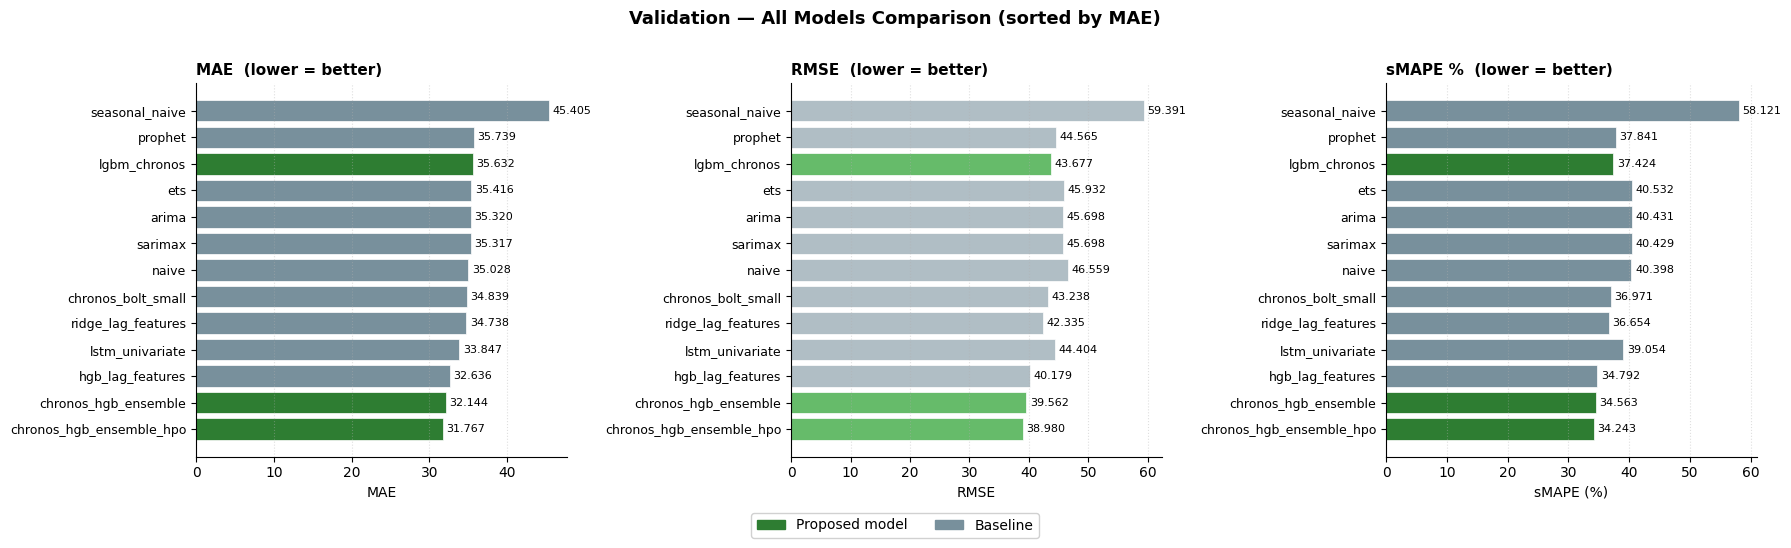

In [27]:
# ── Visual comparison: all models in val_table, sorted by val_MAE ─────────────
import matplotlib.patches as mpatches

_PROPOSED = {
    "chronos_hgb_ensemble", "lgbm_chronos",
    "chronos_hgb_ensemble_hpo",
}

_vt = val_table.copy().sort_values("val_MAE", ascending=True).reset_index(drop=True)

labels  = _vt["model"].tolist()
mae_v   = _vt["val_MAE"].tolist()
rmse_v  = _vt["val_RMSE"].tolist()
smape_v = _vt["val_sMAPE"].tolist()

colors_mae  = ["#2e7d32" if m in _PROPOSED else "#78909c" for m in labels]
colors_rmse = ["#66bb6a" if m in _PROPOSED else "#b0bec5" for m in labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Validation — All Models Comparison (sorted by MAE)", fontsize=13,
             fontweight="bold", y=1.01)

y_pos = np.arange(len(labels))

for ax, vals, cols, title, xlabel in [
    (axes[0], mae_v,   colors_mae,  "MAE  (lower = better)",   "MAE"),
    (axes[1], rmse_v,  colors_rmse, "RMSE  (lower = better)",  "RMSE"),
    (axes[2], smape_v, colors_mae,  "sMAPE %  (lower = better)","sMAPE (%)"),
]:
    bars = ax.barh(y_pos, vals, color=cols, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{v:.3f}", va="center", fontsize=8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_xlim(left=0)

legend_patches = [
    mpatches.Patch(color="#2e7d32", label="Proposed model"),
    mpatches.Patch(color="#78909c", label="Baseline"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()

## 19. Feature Importance — Proposed Model (chronos_hgb_ensemble_hpo)

Phân tích feature importance của thành phần **HGB** trong proposed ensemble:
- Lag feature nào được model học nhiều nhất
- Rolling statistics vs. calendar features: cái nào quan trọng hơn
- Kết quả dùng **native HGB gain-based importance** (nhất quán với Protocol C training)


Computing permutation importance on val set (n_repeats=10) ...
Feature Importance — HGB component of chronos_hgb_ensemble_hpo
  Best strategy : TPE  |  alpha* (Chronos weight): 0.285


,feature,importance,std
0,Inventory Level,0.255915,0.008127
1,Promotion,0.107340,0.004025
2,Epidemic,0.089628,0.003519
3,Price,0.033449,0.001508
4,Competitor Pricing,0.009045,0.001120
5,dayofyear,0.008930,0.000812
6,roll_mean_28,0.004030,0.000955
7,roll_mean_14,0.003314,0.001020
8,roll_mean_7,0.003249,0.000826
9,lag_3,0.001938,0.000549


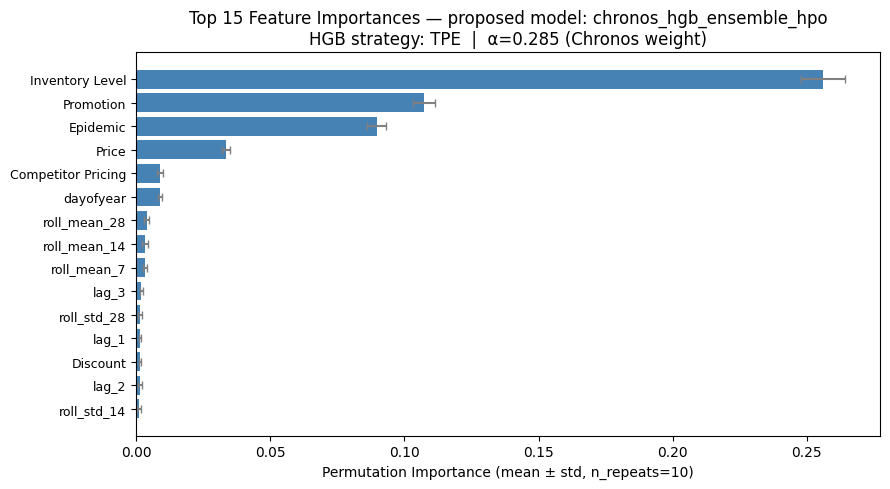

In [28]:
# === Feature Importance: HGB component of chronos_hgb_ensemble_hpo ===
# Note: HistGradientBoostingRegressor does NOT expose .feature_importances_
# → use permutation importance on val set instead (model-agnostic, reliable)

from sklearn.inspection import permutation_importance as _perm_imp

_strategy_metrics = {
    'tpe':   ensemble_tpe_val_metrics,
    'rand':  ensemble_rand_val_metrics,
}

if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params:
    # Select best strategy by val MAE
    _best_key = min(
        _best_hgb_params.keys(),
        key=lambda k: _strategy_metrics.get(k, {}).get('val_MAE', float('inf'))
    )
    _best_params, _best_hgb, _best_alpha = _best_hgb_params[_best_key]

    print(f"Computing permutation importance on val set (n_repeats=10) ...")
    _perm = _perm_imp(_best_hgb, X_val, y_val, n_repeats=10,
                      random_state=RANDOM_SEED, n_jobs=-1)
    imp_df_hpo = pd.DataFrame({
        'feature':    feature_cols,
        'importance': _perm.importances_mean,
        'std':        _perm.importances_std,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"Feature Importance — HGB component of chronos_hgb_ensemble_hpo")
    print(f"  Best strategy : {_best_key.upper()}  |  alpha* (Chronos weight): {_best_alpha:.3f}")
    display(imp_df_hpo.head(15))

    _top_fi = imp_df_hpo.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(_top_fi['feature'], _top_fi['importance'],
            xerr=_top_fi['std'], color='steelblue', ecolor='gray', capsize=3)
    ax.set_xlabel('Permutation Importance (mean ± std, n_repeats=10)')
    ax.set_title(
        f'Top 15 Feature Importances — proposed model: chronos_hgb_ensemble_hpo\n'
        f'HGB strategy: {_best_key.upper()}  |  \u03b1={_best_alpha:.3f} (Chronos weight)'
    )
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

else:
    imp_df_hpo = pd.DataFrame(columns=['feature', 'importance'])
    print("HPO ensemble not available — feature importance skipped.")


## 14. Error Analysis — Proposed Model (chronos_hgb_ensemble_hpo)

Phân tích lỗi **proposed model** theo 5 chiều, so sánh với Naive và Seasonal Naive:

| Panel | Chiều phân tích | Câu hỏi |
|---|---|---|
| 1 | **Theo thời gian** | Lỗi có tăng dần về cuối val? Có drift? |
| 2 | **Day-of-week** | Sai nhiều hơn vào cuối tuần không? |
| 3 | **Peak vs Trough** | Sai nhiều hơn ở demand cao hay thấp? |
| 4 | **Promotion vs Normal** | Promotion spike có được nắm bắt không? |
| 5 | **Per-series distribution** | Series nào có MAE cao nhất? |



Top-3 worst series (highest val MAE):
  Store=S002  Product=P0004  MAE=42.1374
  Store=S003  Product=P0015  MAE=39.4519
  Store=S005  Product=P0009  MAE=38.7322


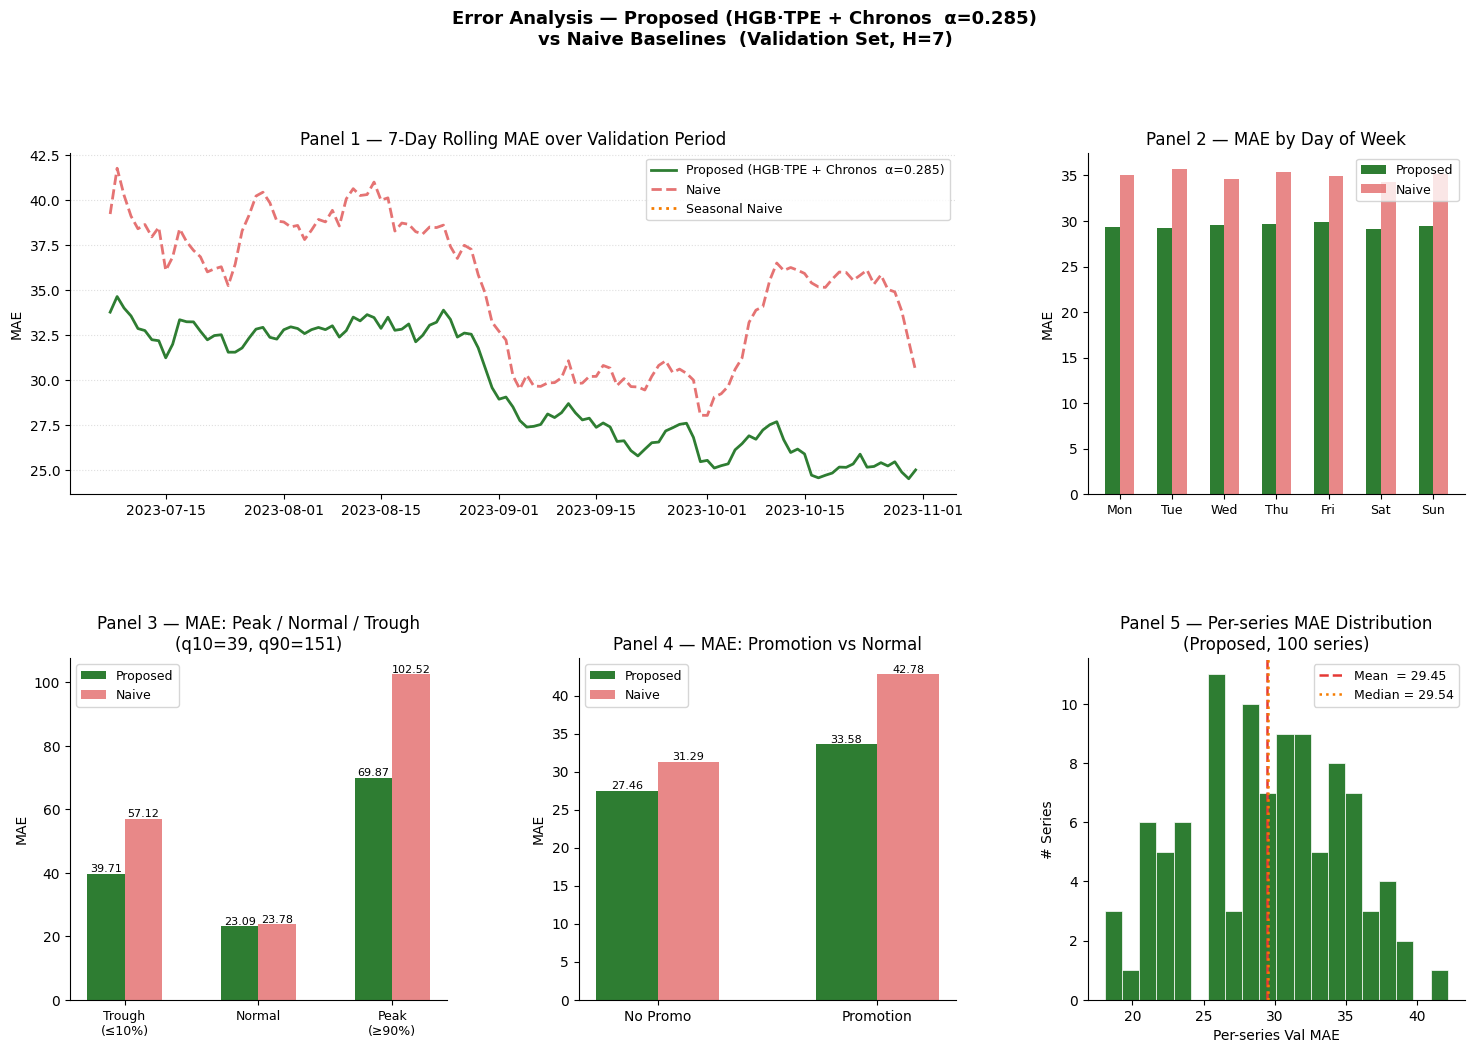


=== Error Analysis Summary — Proposed (HGB·TPE + Chronos  α=0.285) ===
Overall val MAE:           29.4516
Naive val MAE:             35.0277
Peak demand MAE   (≥90%):  69.8689
Normal demand MAE:         23.0874
Trough demand MAE (≤10%):  39.7149
Promotion=1 MAE:           33.5826
Promotion=0 MAE:           27.4608


In [29]:
# === Error Analysis — Proposed Model (chronos_hgb_ensemble_hpo) ===
from matplotlib.gridspec import GridSpec

# ── Pick best HPO HGB component for per-timestep analysis ─────────────────────
_ea_strat = {'tpe': ensemble_tpe_val_metrics, 'rand': ensemble_rand_val_metrics}
if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params:
    _ea_key = min(_best_hgb_params, key=lambda k: _ea_strat.get(k, {}).get('val_RMSE', float('inf')))
    _, _ea_hgb, _ea_alpha = _best_hgb_params[_ea_key]
    val_pred_proposed = np.clip(_ea_hgb.predict(X_val), 0, None)
    _model_label = f"Proposed (HGB·{_ea_key.upper()} + Chronos  α={_ea_alpha:.3f})"
else:
    val_pred_proposed = val_pred_hgb
    _model_label = "HGB (fallback — HPO not available)"

# ── Build error dataframe (aligned to val_feat / X_val) ──────────────────────
# Compute abserr_snaive BEFORE reset_index so val_df label alignment is preserved
_vf = val_feat.copy()
_vf["Date"]            = pd.to_datetime(_vf["Date"])
_vf["y_true"]          = y_val.values
_vf["abserr_proposed"] = np.abs(val_pred_proposed - _vf["y_true"])
_vf["abserr_naive"]    = np.abs(last_train_value  - _vf["y_true"])

# val_pred_snaive is positionally aligned to val_df; reindex via original index labels
_snaive_s = pd.Series(val_pred_snaive, index=val_df.index)
_vf["abserr_snaive"] = np.abs(_snaive_s.reindex(_vf.index).values - _vf["y_true"].values)

_vf = _vf.reset_index(drop=True)

# ── Demand segments ───────────────────────────────────────────────────────────
q10, q90 = _vf["y_true"].quantile(0.10), _vf["y_true"].quantile(0.90)
_vf["segment"] = "Normal"
_vf.loc[_vf["y_true"] >= q90, "segment"] = "Peak\n(≥90%)"
_vf.loc[_vf["y_true"] <= q10, "segment"] = "Trough\n(≤10%)"
_seg_order = ["Trough\n(≤10%)", "Normal", "Peak\n(≥90%)"]

# ── Figure layout: 2 rows × 3 cols ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle(f"Error Analysis — {_model_label}\nvs Naive Baselines  (Validation Set, H=7)",
             fontsize=13, fontweight="bold", y=1.01)
gs = GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])   # wide: error over time
ax2 = fig.add_subplot(gs[0, 2])    # day-of-week
ax3 = fig.add_subplot(gs[1, 0])    # peak vs trough
ax4 = fig.add_subplot(gs[1, 1])    # promotion
ax5 = fig.add_subplot(gs[1, 2])    # per-series distribution

_C_PROP  = "#2e7d32"
_C_NAIVE = "#e57373"
_C_SN    = "#f57c00"
_W = 0.28

# ── Panel 1: Rolling error over time ─────────────────────────────────────────
_daily = _vf.groupby("Date")[["abserr_proposed", "abserr_naive", "abserr_snaive"]].mean()
for col, label, color, ls in [
    ("abserr_proposed", _model_label,    _C_PROP,  "-"),
    ("abserr_naive",    "Naive",         _C_NAIVE, "--"),
    ("abserr_snaive",   "Seasonal Naive",_C_SN,    ":"),
]:
    ax1.plot(_daily.index, _daily[col].rolling(7).mean(),
             label=label, color=color, linestyle=ls, linewidth=2)
ax1.set_title("Panel 1 — 7-Day Rolling MAE over Validation Period")
ax1.set_ylabel("MAE")
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.4)

# ── Panel 2: MAE by Day of Week ──────────────────────────────────────────────
_dow = _vf.groupby("dayofweek")[["abserr_proposed", "abserr_naive"]].mean()
_dow.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
x = np.arange(len(_dow))
ax2.bar(x - _W/2, _dow["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
ax2.bar(x + _W/2, _dow["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(_dow.index, fontsize=9)
ax2.set_title("Panel 2 — MAE by Day of Week")
ax2.set_ylabel("MAE")
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# ── Panel 3: Peak vs Trough ──────────────────────────────────────────────────
_seg = _vf.groupby("segment")[["abserr_proposed", "abserr_naive"]].mean().reindex(_seg_order)
x3 = np.arange(len(_seg_order))
ax3.bar(x3 - _W/2, _seg["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
ax3.bar(x3 + _W/2, _seg["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(_seg_order, fontsize=9)
ax3.set_title(f"Panel 3 — MAE: Peak / Normal / Trough\n(q10={q10:.0f}, q90={q90:.0f})")
ax3.set_ylabel("MAE")
ax3.legend(fontsize=9)
for p in ax3.patches:
    ax3.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=8)
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

# ── Panel 4: Promotion vs Non-promotion ──────────────────────────────────────
if "Promotion" in _vf.columns:
    _promo = _vf.groupby("Promotion")[["abserr_proposed", "abserr_naive"]].mean()
    _promo.index = ["No Promo", "Promotion"]
    x4 = np.arange(2)
    ax4.bar(x4 - _W/2, _promo["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
    ax4.bar(x4 + _W/2, _promo["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
    ax4.set_xticks(x4); ax4.set_xticklabels(_promo.index, fontsize=10)
    for p in ax4.patches:
        ax4.annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=8)
    ax4.legend(fontsize=9)
else:
    ax4.text(0.5, 0.5, "Promotion column\nnot in features",
             ha="center", va="center", transform=ax4.transAxes, fontsize=10, color="#9e9e9e")
ax4.set_title("Panel 4 — MAE: Promotion vs Normal")
ax4.set_ylabel("MAE")
ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)

# ── Panel 5: Per-series MAE distribution ─────────────────────────────────────
if "Store ID" in _vf.columns and "Product ID" in _vf.columns:
    _series_mae = _vf.groupby(["Store ID", "Product ID"])["abserr_proposed"].mean()
    ax5.hist(_series_mae, bins=20, color=_C_PROP, edgecolor="white", linewidth=0.5)
    ax5.axvline(_series_mae.mean(),   color="#e53935", linestyle="--", linewidth=1.8,
                label=f"Mean  = {_series_mae.mean():.2f}")
    ax5.axvline(_series_mae.median(), color=_C_SN,    linestyle=":",  linewidth=1.8,
                label=f"Median = {_series_mae.median():.2f}")
    ax5.set_xlabel("Per-series Val MAE")
    ax5.set_ylabel("# Series")
    ax5.legend(fontsize=9)
    # Annotate worst series
    _worst = _series_mae.nlargest(3)
    print(f"Top-3 worst series (highest val MAE):")
    for (st, pr), v in _worst.items():
        print(f"  Store={st}  Product={pr}  MAE={v:.4f}")
else:
    ax5.text(0.5, 0.5, "Series info not available", ha="center", va="center",
             transform=ax5.transAxes, fontsize=10, color="#9e9e9e")
ax5.set_title("Panel 5 — Per-series MAE Distribution\n(Proposed, 100 series)")
ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n=== Error Analysis Summary — {_model_label} ===")
print(f"Overall val MAE:           {_vf['abserr_proposed'].mean():.4f}")
print(f"Naive val MAE:             {_vf['abserr_naive'].mean():.4f}")
_peak_mae   = _vf[_vf["segment"] == "Peak\n(≥90%)"]["abserr_proposed"].mean()
_trough_mae = _vf[_vf["segment"] == "Trough\n(≤10%)"]["abserr_proposed"].mean()
_normal_mae = _vf[_vf["segment"] == "Normal"]["abserr_proposed"].mean()
print(f"Peak demand MAE   (≥90%):  {_peak_mae:.4f}")
print(f"Normal demand MAE:         {_normal_mae:.4f}")
print(f"Trough demand MAE (≤10%):  {_trough_mae:.4f}")
if "Promotion" in _vf.columns:
    print(f"Promotion=1 MAE:           {_vf[_vf['Promotion']==1]['abserr_proposed'].mean():.4f}")
    print(f"Promotion=0 MAE:           {_vf[_vf['Promotion']==0]['abserr_proposed'].mean():.4f}")

## 15. Ablation Study — Proposed Model (chronos_hgb_ensemble_hpo)

Kiểm tra đóng góp của từng thành phần trong proposed model bằng cách **loại bỏ hoặc thay thế từng phần**.  
Tất cả đánh giá trên **validation set** (train_end → val_end), dùng Protocol C (H=7, no oracle lags).

| Ablation | Thay đổi | Câu hỏi trả lời |
|---|---|---|
| **B1** Chronos Only | α = 1.0 (HGB weight = 0) | HGB có thực sự cần thiết? |
| **B2** HGB Only | α = 0.0 (Chronos weight = 0) | Chronos có thực sự cần thiết? |
| **B3** No HPO | Default HGB params, α* từ sweep | Tối ưu hyperparams mang lại bao nhiêu? |
| **B4** No Lag Features | Bỏ lag_1/2/3/7/14/28 | Memory ngắn hạn đóng góp bao nhiêu? |
| **B5** No Calendar Features | Bỏ dayofweek/month/dayofyear | Seasonality encoding có cần? |
| **B6** No Exogenous Features | Bỏ Price/Discount/Promotion/Epidemic/... | Business signals có giúp HGB? |

Feature groups:
  Lag features    (6):      ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28']
  Rolling stats   (6):     ['roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28']
  Calendar        (3): ['dayofweek', 'month', 'dayofyear']
  Exogenous       (6):     ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic']

Reference: Full Proposed (HPO·TPE)
  val MAE=31.7674  RMSE=38.9804  sMAPE=34.2427

[B1] Chronos Only (α=1.0) ...
  val MAE=34.839  RMSE=43.2383  sMAPE=36.9713
[B2] HGB Only (α=0.0) ...
  val MAE=32.1843  RMSE=39.59  sMAPE=33.778
[B3] No HPO (default params, α* from sweep) ...
  val MAE=32.1437  RMSE=39.5624  sMAPE=34.5627
[B4] No Lag Features ...
  val MAE=32.2491  RMSE=39.5315  sMAPE=34.6782
[B5] No Calendar Features ...
  val MAE=31.9033  RMSE=39.2693  sMAPE=34.384
[B6] No Exogenous Features ...
  val MAE=35.0447  RMSE=43.7297  sMAPE=36.8618

ABLATION SUMMARY (val set, H=7, Protocol C)
ablation  

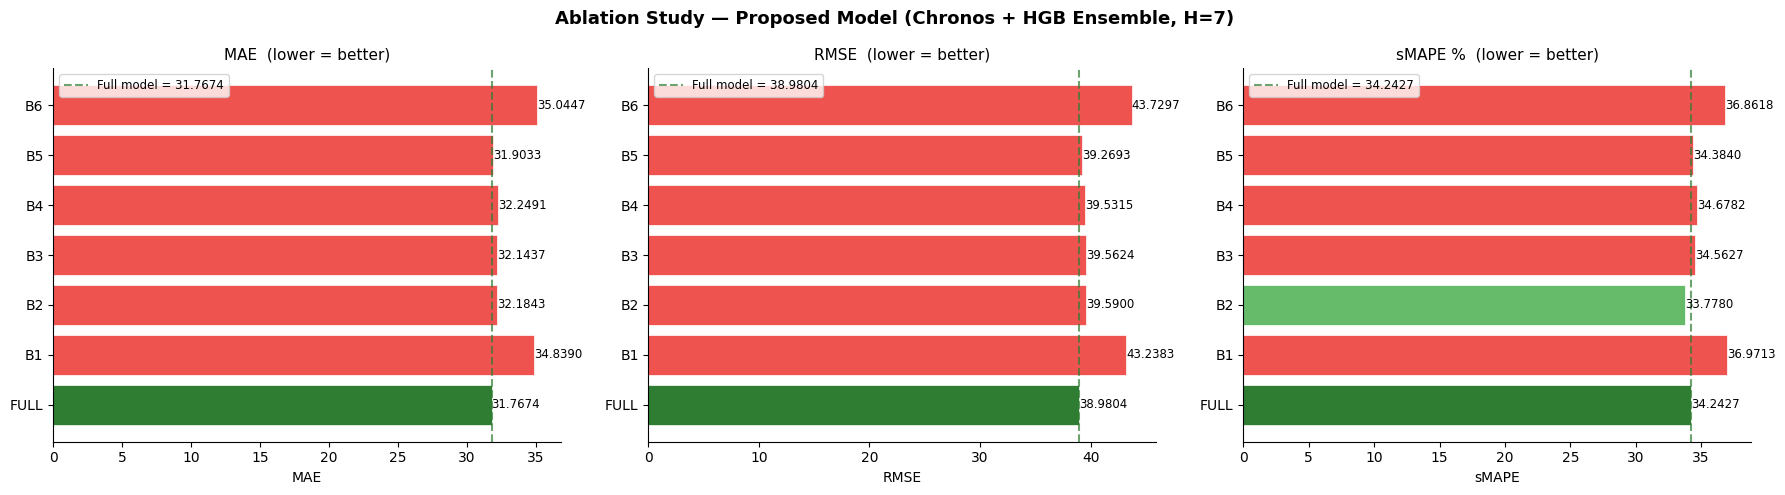

✅ Saved → outputs/ablation_proposed_model.png
✅ Saved ablation CSV → outputs/ablation_proposed_b1b6_summary.csv  (7 rows)


In [30]:
# === Ablation Study — Proposed Model ===
# Requires: CHRONOS_AVAILABLE, ENSEMBLE_AVAILABLE, _best_hgb_params
# All evaluations on validation set via Protocol C (H=7, no oracle lags)

from sklearn.ensemble import HistGradientBoostingRegressor as _HGB

# ── Feature groups (for feature ablations B4–B6) ─────────────────────────────
_LAG_COLS      = [c for c in feature_cols if c.startswith("lag_")]
_ROLL_COLS     = [c for c in feature_cols if c.startswith("roll_")]
_CALENDAR_COLS = [c for c in feature_cols if c in ("dayofweek", "month", "dayofyear")]
_EXOG_COLS     = [c for c in feature_cols if c not in _LAG_COLS + _ROLL_COLS + _CALENDAR_COLS]

print(f"Feature groups:")
print(f"  Lag features    ({len(_LAG_COLS)}):      {_LAG_COLS}")
print(f"  Rolling stats   ({len(_ROLL_COLS)}):     {_ROLL_COLS}")
print(f"  Calendar        ({len(_CALENDAR_COLS)}): {_CALENDAR_COLS}")
print(f"  Exogenous       ({len(_EXOG_COLS)}):     {_EXOG_COLS}")

# ── Shared: Chronos val predictions (reuse from ensemble cell) ────────────────
# c_val already computed in the ensemble cell; reuse if available
if not (CHRONOS_AVAILABLE and ENSEMBLE_AVAILABLE):
    print("⚠️  Chronos/Ensemble not available — ablation skipped.")
    _ablation_records = []
else:
    try:
        _c_val_abl = _chronos_raw(context_end=TRAIN_END, prefix='val')
    except Exception as _e:
        print(f"⚠️  Could not get Chronos val predictions: {_e}")
        _ablation_records = []
        raise

    # ── Helper: fit HGB on subset of features, eval via Protocol C ──────────────
    def _abl_eval(ablation_id, label, feat_subset, alpha_val, hgb_params=None):
        """Fit HGB on feat_subset, blend with Chronos at alpha_val, eval on val."""
        _params = hgb_params or {"max_depth": 5, "learning_rate": 0.05, "random_state": RANDOM_SEED}
        _m = _HGB(**_params)
        _X_tr = train_feat[feat_subset]
        _y_tr = train_feat["Units Sold"]
        _m.fit(_X_tr, _y_tr)
        _h_val = _protocol_c_hgb_raw(_m, TRAIN_END, df, feat_subset)
        _metrics, _ = _blend_eval(_c_val_abl, _h_val, alpha_val, 'val')
        return {
            "ablation": ablation_id,
            "label": label,
            "alpha": round(alpha_val, 3),
            "n_features": len(feat_subset),
            "val_MAE":   round(_metrics["val_MAE"],   4),
            "val_RMSE":  round(_metrics["val_RMSE"],  4),
            "val_sMAPE": round(_metrics["val_sMAPE"], 4),
        }

    # ── Best proposed model reference ────────────────────────────────────────────
    _best_key = min(
        _best_hgb_params,
        key=lambda k: {"tpe": ensemble_tpe_val_metrics, "rand": ensemble_rand_val_metrics}
                       .get(k, {}).get("val_RMSE", float("inf"))
    ) if _best_hgb_params else None
    _best_bp, _best_hgb_model, _best_alpha = _best_hgb_params[_best_key] if _best_key else ({}, None, ENSEMBLE_ALPHA)
    _best_hgb_params_clean = {k: v for k, v in _best_bp.items() if k != "alpha"}
    _best_hgb_params_clean["random_state"] = RANDOM_SEED

    _ref = {
        "ablation": "FULL",
        "label": f"Full Proposed (HPO·{_best_key.upper() if _best_key else '–'})",
        "alpha": round(_best_alpha, 3),
        "n_features": len(feature_cols),
        "val_MAE":   round({"tpe": ensemble_tpe_val_metrics, "rand": ensemble_rand_val_metrics}.get(_best_key, ensemble_val_metrics)["val_MAE"],   4),
        "val_RMSE":  round({"tpe": ensemble_tpe_val_metrics, "rand": ensemble_rand_val_metrics}.get(_best_key, ensemble_val_metrics)["val_RMSE"],  4),
        "val_sMAPE": round({"tpe": ensemble_tpe_val_metrics, "rand": ensemble_rand_val_metrics}.get(_best_key, ensemble_val_metrics)["val_sMAPE"], 4),
    }

    print(f"\nReference: {_ref['label']}")
    print(f"  val MAE={_ref['val_MAE']}  RMSE={_ref['val_RMSE']}  sMAPE={_ref['val_sMAPE']}")

    # ── B1: Chronos Only (α=1, no HGB) ───────────────────────────────────────────
    # _blend_eval requires h_raw to have the same keys as c_raw (it skips missing keys).
    # With α=1, h_raw values are multiplied by (1-α)=0 so zeros are safe as dummy.
    print("\n[B1] Chronos Only (α=1.0) ...")
    _h_zeros = {k: np.zeros(HORIZON_DAYS) for k in _c_val_abl}
    _b1_metrics, _ = _blend_eval(_c_val_abl, _h_zeros, 1.0, 'val')
    _b1 = {"ablation": "B1", "label": "Chronos Only (α=1)", "alpha": 1.0, "n_features": 0,
           "val_MAE": round(_b1_metrics["val_MAE"], 4), "val_RMSE": round(_b1_metrics["val_RMSE"], 4),
           "val_sMAPE": round(_b1_metrics["val_sMAPE"], 4)}
    print(f"  val MAE={_b1['val_MAE']}  RMSE={_b1['val_RMSE']}  sMAPE={_b1['val_sMAPE']}")

    # ── B2: HGB Only (α=0, no Chronos) ───────────────────────────────────────────
    print("[B2] HGB Only (α=0.0) ...")
    _b2 = _abl_eval("B2", "HGB Only (α=0)", feature_cols, 0.0, _best_hgb_params_clean)
    print(f"  val MAE={_b2['val_MAE']}  RMSE={_b2['val_RMSE']}  sMAPE={_b2['val_sMAPE']}")

    # ── B3: No HPO (default HGB params, α* from sweep) ───────────────────────────
    print("[B3] No HPO (default params, α* from sweep) ...")
    _b3 = _abl_eval("B3", "No HPO (default params)", feature_cols, ENSEMBLE_ALPHA,
                    {"max_depth": 5, "learning_rate": 0.05, "random_state": RANDOM_SEED})
    print(f"  val MAE={_b3['val_MAE']}  RMSE={_b3['val_RMSE']}  sMAPE={_b3['val_sMAPE']}")

    # ── B4: No Lag Features ───────────────────────────────────────────────────────
    print("[B4] No Lag Features ...")
    _feat_no_lag = [c for c in feature_cols if c not in _LAG_COLS]
    _b4 = _abl_eval("B4", f"No Lag Features (–{len(_LAG_COLS)})", _feat_no_lag, _best_alpha, _best_hgb_params_clean)
    print(f"  val MAE={_b4['val_MAE']}  RMSE={_b4['val_RMSE']}  sMAPE={_b4['val_sMAPE']}")

    # ── B5: No Calendar Features ──────────────────────────────────────────────────
    print("[B5] No Calendar Features ...")
    _feat_no_cal = [c for c in feature_cols if c not in _CALENDAR_COLS]
    _b5 = _abl_eval("B5", f"No Calendar (–{len(_CALENDAR_COLS)})", _feat_no_cal, _best_alpha, _best_hgb_params_clean)
    print(f"  val MAE={_b5['val_MAE']}  RMSE={_b5['val_RMSE']}  sMAPE={_b5['val_sMAPE']}")

    # ── B6: No Exogenous Features ─────────────────────────────────────────────────
    print("[B6] No Exogenous Features ...")
    _feat_no_exog = [c for c in feature_cols if c not in _EXOG_COLS]
    _b6 = _abl_eval("B6", f"No Exogenous (–{len(_EXOG_COLS)})", _feat_no_exog, _best_alpha, _best_hgb_params_clean)
    print(f"  val MAE={_b6['val_MAE']}  RMSE={_b6['val_RMSE']}  sMAPE={_b6['val_sMAPE']}")

    # ── Summary table ──────────────────────────────────────────────────────────────
    _ablation_records = [_ref, _b1, _b2, _b3, _b4, _b5, _b6]
    abl_df = pd.DataFrame(_ablation_records)
    abl_df["ΔMAE vs Full"]   = (abl_df["val_MAE"]  - _ref["val_MAE"]).round(4)
    abl_df["ΔRMSE vs Full"]  = (abl_df["val_RMSE"] - _ref["val_RMSE"]).round(4)
    abl_df["Δ%MAE vs Full"]  = ((abl_df["val_MAE"] / _ref["val_MAE"] - 1) * 100).round(2)

    print("\n" + "="*70)
    print("ABLATION SUMMARY (val set, H=7, Protocol C)")
    print("="*70)
    print(abl_df[["ablation","label","alpha","n_features","val_MAE","val_RMSE","val_sMAPE",
                  "ΔMAE vs Full","Δ%MAE vs Full"]].to_string(index=False))

    # ── Visual: bar chart ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Ablation Study — Proposed Model (Chronos + HGB Ensemble, H=7)",
                 fontsize=13, fontweight="bold")

    for ax, col, title in [
        (axes[0], "val_MAE",   "MAE  (lower = better)"),
        (axes[1], "val_RMSE",  "RMSE  (lower = better)"),
        (axes[2], "val_sMAPE", "sMAPE %  (lower = better)"),
    ]:
        _vals   = abl_df[col].values
        _labels = abl_df["ablation"].values
        _colors = ["#2e7d32" if l == "FULL" else "#ef5350" if v > _ref[col] else "#66bb6a"
                   for l, v in zip(_labels, _vals)]
        bars = ax.barh(_labels, _vals, color=_colors, edgecolor="white", linewidth=0.5)
        ax.axvline(_ref[col], color="#2e7d32", linestyle="--", linewidth=1.5, alpha=0.7,
                   label=f"Full model = {_ref[col]:.4f}")
        for bar, v in zip(bars, _vals):
            ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                    f"{v:.4f}", va="center", ha="left", fontsize=8.5)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(col.replace("val_", ""))
        ax.legend(fontsize=8.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ablation_proposed_model.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Saved → outputs/ablation_proposed_model.png")

    # ── Export ablation CSV to outputs/ and result/ ───────────────────────────
    _abl_export = abl_df.copy()
    _abl_export["model"]   = "chronos_hgb_ensemble_hpo"
    _abl_export["horizon"] = HORIZON_DAYS

    _abl_csv_local = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
    _abl_export.to_csv(_abl_csv_local, index=False)
    print(f"✅ Saved ablation CSV → {_abl_csv_local}  ({len(_abl_export)} rows)")

## 15. Final test evaluation

Cần chọn best model trên validation rồi mới đánh giá test.  
Không dùng kết quả đánh giá test để lựa chọn best model.


In [31]:
best_model_name = val_table.iloc[0]["model"]
print("Best validation model:", best_model_name)


Best validation model: chronos_hgb_ensemble_hpo


Có thể retrain với toàn bộ dữ liệu train + validation để có model cuối cùng trước khi test.

In [32]:
# Prepare test predictions consistently
last_train_val = df[df["Date"] < "2023-11-01"]["Units Sold"].iloc[-1]
test_pred_naive = np.repeat(last_train_val, len(test_df))

history_until_test = df[df["Date"] < "2023-11-01"]["Units Sold"].values
test_pred_snaive = seasonal_naive_predict(history_until_test, len(test_df), season_length=7)

# Refit ARIMA on train + val
trainval_df = df[df["Date"] < "2023-11-01"].copy()
arima_tv = ARIMA(
    trainval_df["Units Sold"],
    order=(2,1,2)
)
arima_tv_fit = arima_tv.fit()
test_pred_arima = arima_tv_fit.forecast(steps=len(test_df))

# Refit SARIMAX on train + val
sarimax_tv = SARIMAX(
    trainval_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_tv_fit = sarimax_tv.fit(disp=False)
test_pred_sarimax = sarimax_tv_fit.forecast(steps=len(test_df))

# Refit ETS on train + val
ets_tv = ExponentialSmoothing(
    trainval_df["Units Sold"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)
test_pred_ets = ets_tv.forecast(len(test_df))

# Prophet per-series evaluation on test split
prophet_test_records = []
prophet_test_scores = {'test_MAE': [], 'test_RMSE': [], 'test_sMAPE': []}

for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    s_ts = grp.set_index('Date')['Units Sold'].sort_index()
    s_ts.index = pd.to_datetime(s_ts.index)

    trainval_s = s_ts[s_ts.index <= VAL_END]
    test_s = s_ts[s_ts.index > VAL_END]

    if len(trainval_s) < 14 or len(test_s) < HORIZON_DAYS:
        continue

    try:
        y_pred = prophet_fn(trainval_s.index, trainval_s.values, len(test_s))
        y_true = test_s.values.astype(float)
        m = eval_forecast(y_true, y_pred, prefix='test', y_train=trainval_s.values)
    except Exception:
        continue

    for k in prophet_test_scores:
        prophet_test_scores[k].append(m[k])

    prophet_test_records.append({
        'store': store, 'product': product,
        **{k: round(float(m[k]), 4) for k in m}
    })

prophet_test_metrics = {k: float(np.nanmean(v)) for k, v in prophet_test_scores.items()}
print(f'Prophet test: {len(prophet_test_records)} series | metrics: {prophet_test_metrics}')

# Refit LSTM-univariate on train + val
try:
    import torch
    import torch.nn as nn
    torch.manual_seed(RANDOM_SEED)

    class LSTMUni(nn.Module):
        def __init__(self, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)

    trainval_series = trainval_df["Units Sold"].values.astype(float)
    test_series = test_df["Units Sold"].values.astype(float)
    trainval_dates = pd.to_datetime(trainval_df["Date"]).values
    test_dates = pd.to_datetime(test_df["Date"]).values

    # PRACTICE: fit scaler on train+val only (no test leakage)
    mu_tv = trainval_series.mean()
    sd_tv = trainval_series.std() + 1e-8
    trainval_norm = (trainval_series - mu_tv) / sd_tv

    X_tv, y_tv = [], []
    for i in range(len(trainval_norm) - LOOKBACK_LSTM):
        X_tv.append(trainval_norm[i:i+LOOKBACK_LSTM])
        y_tv.append(trainval_norm[i+LOOKBACK_LSTM])

    X_tv = torch.tensor(np.array(X_tv), dtype=torch.float32).unsqueeze(-1)
    y_tv = torch.tensor(np.array(y_tv), dtype=torch.float32)

    lstm_uni_tv = LSTMUni(hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_uni_tv.parameters(), lr=1e-3)

    lstm_uni_tv.train()
    for _ in range(EPOCHS_LSTM):
        optimizer.zero_grad()
        pred = lstm_uni_tv(X_tv)
        loss = criterion(pred, y_tv)
        loss.backward()
        optimizer.step()

    # PRACTICE: rolling test evaluation uses REAL observed test history at each t
    lstm_uni_tv.eval()
    test_pred_lstm_uni = []
    for t in range(len(test_series)):
        history = np.concatenate([trainval_series, test_series[:t]])
        history_dates = np.concatenate([trainval_dates, test_dates[:t]])
        history_norm = (history - mu_tv) / sd_tv

        if len(history_norm) < LOOKBACK_LSTM:
            pad = np.repeat(history_norm[0] if len(history_norm) else 0.0, LOOKBACK_LSTM - len(history_norm))
            context = np.concatenate([pad, history_norm])
        else:
            context = history_norm[-LOOKBACK_LSTM:]

        if VERBOSE_WINDOWS and (t < MAX_VERBOSE_STEPS or t == len(test_series)-1):
            start_idx = max(0, len(history_dates) - LOOKBACK_LSTM)
            win_start = pd.Timestamp(history_dates[start_idx]).date()
            win_end = pd.Timestamp(history_dates[-1]).date()
            target_day = pd.Timestamp(test_dates[t]).date()
            log_window(tag="TEST", step=t, total_steps=len(test_series), history_dates=history_dates, target_date=test_dates[t], lookback=LOOKBACK_LSTM, enabled=VERBOSE_WINDOWS, max_steps=MAX_VERBOSE_STEPS)

        x = torch.tensor(context.reshape(1, LOOKBACK_LSTM, 1), dtype=torch.float32)
        with torch.no_grad():
            yhat_norm = float(lstm_uni_tv(x).item())
        test_pred_lstm_uni.append(yhat_norm * sd_tv + mu_tv)

    test_pred_lstm_uni = np.array(test_pred_lstm_uni)
except Exception as e:
    print("LSTM test fallback to naive. Reason:", e)
    test_pred_lstm_uni = np.repeat(trainval_df["Units Sold"].iloc[-1], len(test_df))

# Refit ML models on train+val features
trainval_feat = df_feat[df_feat["Date"] < "2023-11-01"].copy().dropna().reset_index(drop=True)
X_trainval = trainval_feat[feature_cols]
y_trainval = trainval_feat["Units Sold"]

ridge_ts_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_ts_final.fit(X_trainval, y_trainval)
test_pred_ridge = ridge_ts_final.predict(X_test)

hgb_ts_final = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)
hgb_ts_final.fit(X_trainval, y_trainval)
test_pred_hgb = hgb_ts_final.predict(X_test)

# Protocol C test evaluation for Ridge and HGB (no oracle lags)
print("Ridge (Protocol C) — test:")
ridge_test_c_metrics, _ = _ml_protocol_c(ridge_ts_final, VAL_END, df, feature_cols, prefix="test")
print(f"  MAE={ridge_test_c_metrics['test_MAE']:.4f}  "
      f"RMSE={ridge_test_c_metrics['test_RMSE']:.4f}  "
      f"sMAPE={ridge_test_c_metrics['test_sMAPE']:.4f}\n")

print("HGB (Protocol C) — test:")
hgb_test_c_metrics, _ = _ml_protocol_c(hgb_ts_final, VAL_END, df, feature_cols, prefix="test")
print(f"  MAE={hgb_test_c_metrics['test_MAE']:.4f}  "
      f"RMSE={hgb_test_c_metrics['test_RMSE']:.4f}  "
      f"sMAPE={hgb_test_c_metrics['test_sMAPE']:.4f}")




# Chronos zero-shot test evaluation
if CHRONOS_AVAILABLE:
    chronos_test_metrics, chronos_test_records = run_chronos_per_series(
        context_end=VAL_END, prefix='test'
    )
    pd.DataFrame(chronos_test_records).to_csv(
        os.path.join(OUTPUT_DIR, 'chronos_test_details.csv'), index=False
    )
    print(f'Chronos test: {len(chronos_test_records)} series | metrics: {chronos_test_metrics}')
else:
    chronos_test_metrics = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}

test_feat = df_feat[df_feat["Date"] > VAL_END].copy()

# Chronos-HGB ensemble — test evaluation
if ENSEMBLE_AVAILABLE:
    print('Running Chronos-HGB ensemble (test)...')
    c_test = _chronos_raw(context_end=VAL_END, prefix='test')
    # Protocol C: recursive H=7 per series — no oracle lags in HGB component
    h_test = _protocol_c_hgb_raw(hgb_ts_final, VAL_END, df, feature_cols)
    ensemble_test_metrics, ens_test_records = _blend_eval(c_test, h_test, ENSEMBLE_ALPHA, 'test')
    pd.DataFrame(ens_test_records).to_csv(
        os.path.join(OUTPUT_DIR, 'ensemble_test_details.csv'), index=False)
    print(f'Ensemble (α={ENSEMBLE_ALPHA}) test | {len(ens_test_records)} series')

    print(f"  MAE={ensemble_test_metrics['test_MAE']:.4f}  "
          f"RMSE={ensemble_test_metrics['test_RMSE']:.4f}  "
          f"sMAPE={ensemble_test_metrics['test_sMAPE']:.4f}")



# LightGBM+Chronos - test evaluation (Protocol C: per-series H=7, no oracle lags)
if LGBM_CHRONOS_AVAILABLE and lgbm_chron_model is not None and df_feat_lgbm is not None:
    print('LightGBM+Chronos (Protocol C) — test evaluation ...')
    # Refit on train+val
    trainval_feat_l = df_feat_lgbm[df_feat_lgbm['Date'] <= VAL_END].dropna(
        subset=[c for c in lgbm_chron_cols if 'lag' in c or 'roll' in c]
    )
    X_trainval_l = trainval_feat_l[lgbm_chron_cols]
    y_trainval_l = trainval_feat_l['Units Sold']
    lgbm_final = lgb.LGBMRegressor(**{**lgbm_chron_model.get_params(), 'verbose': -1})
    lgbm_final.fit(X_trainval_l, y_trainval_l)

    # Compute Chronos H=7 predictions from VAL_END context for Protocol C
    import torch as _torch_lgbm
    _chron_test_map = {}
    for (store, prod), grp in df.groupby(['Store ID', 'Product ID']):
        _hist = grp[grp['Date'] <= VAL_END].sort_values('Date')
        if len(_hist) < 14:
            continue
        _ctx = _torch_lgbm.tensor(_hist['Units Sold'].values.astype(np.float32))
        with _torch_lgbm.no_grad():
            _fc = chron_pipeline.predict([_ctx], HORIZON_DAYS)
        _chron_test_map[(store, prod)] = np.clip(
            _fc.median(dim=1).values.numpy()[0], 0, None
        )

    lgbm_chronos_test_metrics, _ = _lgbm_chron_protocol_c(
        lgbm_final, VAL_END, df, lgbm_chron_cols, 'test', _chron_test_map
    )
    print(f"  MAE={lgbm_chronos_test_metrics['test_MAE']:.4f}  "
          f"RMSE={lgbm_chronos_test_metrics['test_RMSE']:.4f}")
else:
    lgbm_chronos_test_metrics = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}



# HPO Ensemble strategies - test evaluation
# _best_hgb_params stores {key: (best_params_dict, hgb_model_train_only, alpha)}
# For test we must refit on train+val, so we use best_params to rebuild.
if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params:
    from sklearn.ensemble import HistGradientBoostingRegressor
    _c_test_hpo = _chronos_raw(context_end=VAL_END, prefix='test')
    # Build train+val feature matrix for refitting
    _tv_feat = df_feat[df_feat['Date'] <= VAL_END].copy().dropna().reset_index(drop=True)
    _X_tv    = _tv_feat[feature_cols]
    _y_tv    = _tv_feat['Units Sold']

    def _hpo_test_eval(key, label):
        # Each entry is (best_params_dict, hgb_trained_on_train, alpha)
        bp, _, alpha_val = _best_hgb_params[key]
        hparams = {k: v for k, v in bp.items() if k != 'alpha'}
        hparams['random_state'] = RANDOM_SEED
        m = HistGradientBoostingRegressor(**hparams)
        m.fit(_X_tv, _y_tv)          # refit on train+val for proper test eval
        # Protocol C: recursive H=7 — consistent with HPO objective
        h_t  = _protocol_c_hgb_raw(m, VAL_END, df, feature_cols)
        met, _ = _blend_eval(_c_test_hpo, h_t, alpha_val, 'test')
        print(f'  {label}: MAE={met["test_MAE"]:.4f}  RMSE={met["test_RMSE"]:.4f}')
        return met

    print('HPO Ensemble - test evaluation ...')
    ensemble_tpe_test_metrics   = _hpo_test_eval('tpe',   'TPE')   if 'tpe'   in _best_hgb_params else {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
    ensemble_rand_test_metrics  = _hpo_test_eval('rand',  'Random') if 'rand'  in _best_hgb_params else {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
else:
    ensemble_tpe_test_metrics   = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
    ensemble_rand_test_metrics  = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}


test_table = pd.DataFrame([
    {"model": "naive", **eval_forecast(test_df["Units Sold"], test_pred_naive, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "seasonal_naive", **eval_forecast(test_df["Units Sold"], test_pred_snaive, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "arima", **eval_forecast(test_df["Units Sold"], test_pred_arima, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "sarimax", **eval_forecast(test_df["Units Sold"], test_pred_sarimax, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "ets", **eval_forecast(test_df["Units Sold"], test_pred_ets, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "prophet", **prophet_test_metrics},
    {"model": "ridge_lag_features", **ridge_test_c_metrics},  # Protocol C: per-series H=7, no oracle lags
    # HGB computed via Protocol C but excluded from display (see proposed model section)
    # {"model": "hgb_lag_features", **hgb_test_c_metrics},
    {"model": "lstm_univariate", **eval_forecast(test_df["Units Sold"], test_pred_lstm_uni, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "chronos_bolt_small",         **chronos_test_metrics},
    {"model": "chronos_hgb_ensemble",       **ensemble_test_metrics},
    {"model": "lgbm_chronos",               **lgbm_chronos_test_metrics},
    {"model": "ensemble_tpe",               **ensemble_tpe_test_metrics},
    {"model": "ensemble_rand",              **ensemble_rand_test_metrics},
]).sort_values(by="test_MAE")

test_table


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeh73uzls/fq2gri6u.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeh73uzls/nrz6jy1i.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=43112', 'data', 'file=/tmp/tmpeh73uzls/fq2gri6u.json', 'init=/tmp/tmpeh73uzls/nrz6jy1i.json', 'output', 'file=/tmp/tmpeh73uzls/prophet_model1j1hpcna/prophet_model-20260417113832.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
INFO:cmdstanpy:Chain [1] start processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeh73uzls/lgd1prte.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpeh73uzls/4kcumcxu.json
DEBUG:c

Prophet test: 100 series | metrics: {'test_MAE': 31.450385009812717, 'test_RMSE': 39.7668792133161, 'test_sMAPE': 37.87489370774011}
[TEST step=000] train_window: 2023-10-31 -> 2023-10-31 | target: 2023-11-01
[TEST step=001] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=002] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=003] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=004] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=005] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=006] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=007] train_window: 2023-10-31 -> 2023-11-01 | target: 2023-11-01
[TEST step=9099] train_window: 2024-01-30 -> 2024-01-30 | target: 2024-01-30
Ridge (Protocol C) — test:
  [test] 100 series evaluated, 0 skipped
  MAE=27.2425  RMSE=33.2602  sMAPE=30.6066

HGB (Protocol C) — test:
  [test] 100 series evaluated, 0 skipped
  MA

,model,test_MAE,test_RMSE,test_sMAPE
9,chronos_hgb_ensemble,25.989739,32.345276,29.363958
12,ensemble_rand,26.042699,32.343579,29.458137
11,ensemble_tpe,26.085905,32.373474,29.488716
6,ridge_lag_features,27.242456,33.260220,30.606643
10,lgbm_chronos,27.706940,34.263804,31.211210
8,chronos_bolt_small,29.866587,36.954020,34.335946
5,prophet,31.450385,39.766879,37.874894
7,lstm_univariate,31.876329,40.790532,38.514307
3,sarimax,32.702362,42.577506,39.578576
2,arima,32.703162,42.579793,39.579854


## 15b. Proposed Model: Chronos + HGB Ensemble — Detailed Logging & Visualization

Phân tích chuyên sâu các model đề xuất:
- **Base Ensemble**: Chronos-Bolt-Small ZS + HGB, blend weight α tối ưu qua alpha sweep
- **HPO Ensemble (TPE)**: Joint optimize 6 HGB hyperparams + α bằng Bayesian (Optuna TPE)  
- **HPO Ensemble (Random)**: Random Search baseline cho so sánh HPO strategies

In [33]:
import math

SEP  = "=" * 72
SEP2 = "-" * 52

# ── Helper: pull one metric value from val/test tables ────────────────────────
def _tbl(table, model_key, metric):
    row = table[table["model"] == model_key]
    return float(row[metric].iloc[0]) if not row.empty else float("nan")

# ── 0. Retrieve component metrics ─────────────────────────────────────────────
hgb_vm     = _tbl(val_table,  "hgb_lag_features",    "val_MAE")
hgb_tm     = _tbl(test_table, "hgb_lag_features",    "test_MAE")
chron_vm   = _tbl(val_table,  "chronos_bolt_small",  "val_MAE")
chron_tm   = _tbl(test_table, "chronos_bolt_small",  "test_MAE")
ens_vm     = ensemble_val_metrics.get("val_MAE",  float("nan"))
ens_tm     = ensemble_test_metrics.get("test_MAE", float("nan"))
tpe_vm     = ensemble_tpe_val_metrics.get("val_MAE",  float("nan"))
tpe_tm     = ensemble_tpe_test_metrics.get("test_MAE", float("nan"))
rand_vm    = ensemble_rand_val_metrics.get("val_MAE",  float("nan"))
rand_tm    = ensemble_rand_test_metrics.get("test_MAE", float("nan"))

def _pct(base, new):
    if math.isnan(base) or math.isnan(new) or base == 0:
        return float("nan")
    return 100 * (base - new) / base   # positive = improvement

print(SEP)
print("  PROPOSED MODEL — Chronos-Bolt-Small + HGB Ensemble")
print(SEP)

# ── 1. Component summary ───────────────────────────────────────────────────────
print("\n── Component Baselines ───────────────────────────────────────────────────")
print(f"  {'Model':<32} {'Val MAE':>10}  {'Test MAE':>10}")
print(f"  {SEP2}")
print(f"  {'HGB (lag features)':<32} {hgb_vm:>10.4f}  {hgb_tm:>10.4f}")
print(f"  {'Chronos-Bolt-Small ZS':<32} {chron_vm:>10.4f}  {chron_tm:>10.4f}")

# ── 2. Alpha sweep ─────────────────────────────────────────────────────────────
print(f"\n── Alpha Sweep on Validation  (α = Chronos weight, 1-α = HGB weight) ─────")
print(f"  {'α':>5}   {'Val MAE':>10}   {'Δ vs HGB':>10}   note")
for a_val, mae_val in sorted(sweep.items()):
    delta = mae_val - hgb_vm
    marker = "  ◀ best α" if a_val == ENSEMBLE_ALPHA else ""
    note   = "HGB only" if a_val == 0.0 else ("Chronos only" if a_val == 1.0 else "")
    print(f"  {a_val:5.2f}   {mae_val:>10.4f}   {delta:>+10.4f}   {note}{marker}")

# ── 3. Ensemble base result ────────────────────────────────────────────────────
pct_ens = _pct(hgb_vm, ens_vm)
print(f"\n── Base Ensemble  (α* = {ENSEMBLE_ALPHA}) ──────────────────────────────────────")
print(f"  Val  MAE = {ens_vm:.4f}  ({pct_ens:+.1f}% vs HGB alone)")
print(f"  Test MAE = {ens_tm:.4f}  ({_pct(hgb_tm, ens_tm):+.1f}% vs HGB alone)")

# ── 4. HPO strategy comparison ────────────────────────────────────────────────
print(f"\n── HPO Strategy Comparison  (joint search: 6 HGB params + α ∈ [0, 0.4]) ───")
print(f"  {'Strategy':<14} {'Trials':>6}  {'Val MAE':>10}  {'Δ vs Base':>10}  {'Test MAE':>10}  {'Best α':>8}")
print(f"  {SEP2}")

hpo_rows = [
    ("Base (α sweep)", 0,   ens_vm,   ens_tm,   ENSEMBLE_ALPHA),
    ("TPE",           50,   tpe_vm,   tpe_tm,   _best_hgb_params.get('tpe',   (None,None,float("nan")))[2]),
    ("Random",       100,   rand_vm,  rand_tm,  _best_hgb_params.get('rand',  (None,None,float("nan")))[2]),
]
best_hpo_val = min((r[2] for r in hpo_rows if not math.isnan(r[2])), default=float("nan"))

for name, n_trials, vm, tm, alp in hpo_rows:
    d = _pct(ens_vm, vm)                          # improvement over base ensemble
    alp_s = f"{float(alp):.3f}" if not math.isnan(float(alp if alp is not None else float("nan"))) else "  —"
    tag = "  ★" if (not math.isnan(vm) and abs(vm - best_hpo_val) < 1e-6) else ""
    print(f"  {name:<14} {n_trials:>6}  {vm:>10.4f}  {d:>+10.1f}%  {tm:>10.4f}  {alp_s:>8}{tag}")

# ── 5. Best hyperparameters per HPO strategy ──────────────────────────────────
print(f"\n── Best Hyperparameters per Strategy ─────────────────────────────────────")
for key, label in [("tpe", "TPE"), ("rand", "Random")]:
    if key in _best_hgb_params:
        bp, _, alp = _best_hgb_params[key]
        print(f"\n  [{label}]  blend α* = {float(alp):.4f}")
        hp_display = {k: v for k, v in bp.items() if k != "alpha"}
        for k, v in hp_display.items():
            print(f"    {k:<26}= {v:.4f}" if isinstance(v, float) else f"    {k:<26}= {v}")
    else:
        print(f"\n  [{label}]  — strategy did not run or failed")

# ── 6. Other metrics (MAE, RMSE, sMAPE) for proposed models ──────────────────
print(f"\n── Full Metrics — Proposed Models (Val) ──────────────────────────────────")
print(f"  {'Model':<18} {'MAE':>9} {'RMSE':>9} {'sMAPE':>9}")
print(f"  {SEP2}")
for label, met in [
    ("Ensemble base",    ensemble_val_metrics),
    ("Ensemble TPE",     ensemble_tpe_val_metrics),
    ("Ensemble Random",  ensemble_rand_val_metrics),
]:
    mae   = met.get("val_MAE",   float("nan"))
    rmse  = met.get("val_RMSE",  float("nan"))
    smape = met.get("val_sMAPE", float("nan"))
    print(f"  {label:<18} {mae:>9.4f} {rmse:>9.4f} {smape:>9.2f}%")

print(f"\n── Full Metrics — Proposed Models (Test) ─────────────────────────────────")
print(f"  {'Model':<18} {'MAE':>9} {'RMSE':>9} {'sMAPE':>9}")
print(f"  {SEP2}")
for label, met in [
    ("Ensemble base",    ensemble_test_metrics),
    ("Ensemble TPE",     ensemble_tpe_test_metrics),
    ("Ensemble Random",  ensemble_rand_test_metrics),
]:
    mae   = met.get("test_MAE",   float("nan"))
    rmse  = met.get("test_RMSE",  float("nan"))
    smape = met.get("test_sMAPE", float("nan"))
    print(f"  {label:<18} {mae:>9.4f} {rmse:>9.4f} {smape:>9.2f}%")

print(f"\n{SEP}")
print("  Logging complete. See visualization cell below.")
print(SEP)

  PROPOSED MODEL — Chronos-Bolt-Small + HGB Ensemble

── Component Baselines ───────────────────────────────────────────────────
  Model                               Val MAE    Test MAE
  ----------------------------------------------------
  HGB (lag features)                  32.6365         nan
  Chronos-Bolt-Small ZS               34.8390     29.8666

── Alpha Sweep on Validation  (α = Chronos weight, 1-α = HGB weight) ─────
      α      Val MAE     Δ vs HGB   note
   0.00      32.6365      +0.0000   HGB only
   0.20      32.1872      -0.4493   
   0.30      32.1437      -0.4927     ◀ best α
   0.50      32.4563      -0.1802   
   0.70      33.1619      +0.5254   
   0.80      33.6369      +1.0004   
   1.00      34.8390      +2.2025   Chronos only

── Base Ensemble  (α* = 0.3) ──────────────────────────────────────
  Val  MAE = 32.1437  (+1.5% vs HGB alone)
  Test MAE = 25.9897  (+nan% vs HGB alone)

── HPO Strategy Comparison  (joint search: 6 HGB params + α ∈ [0, 0.4]) ───
  St

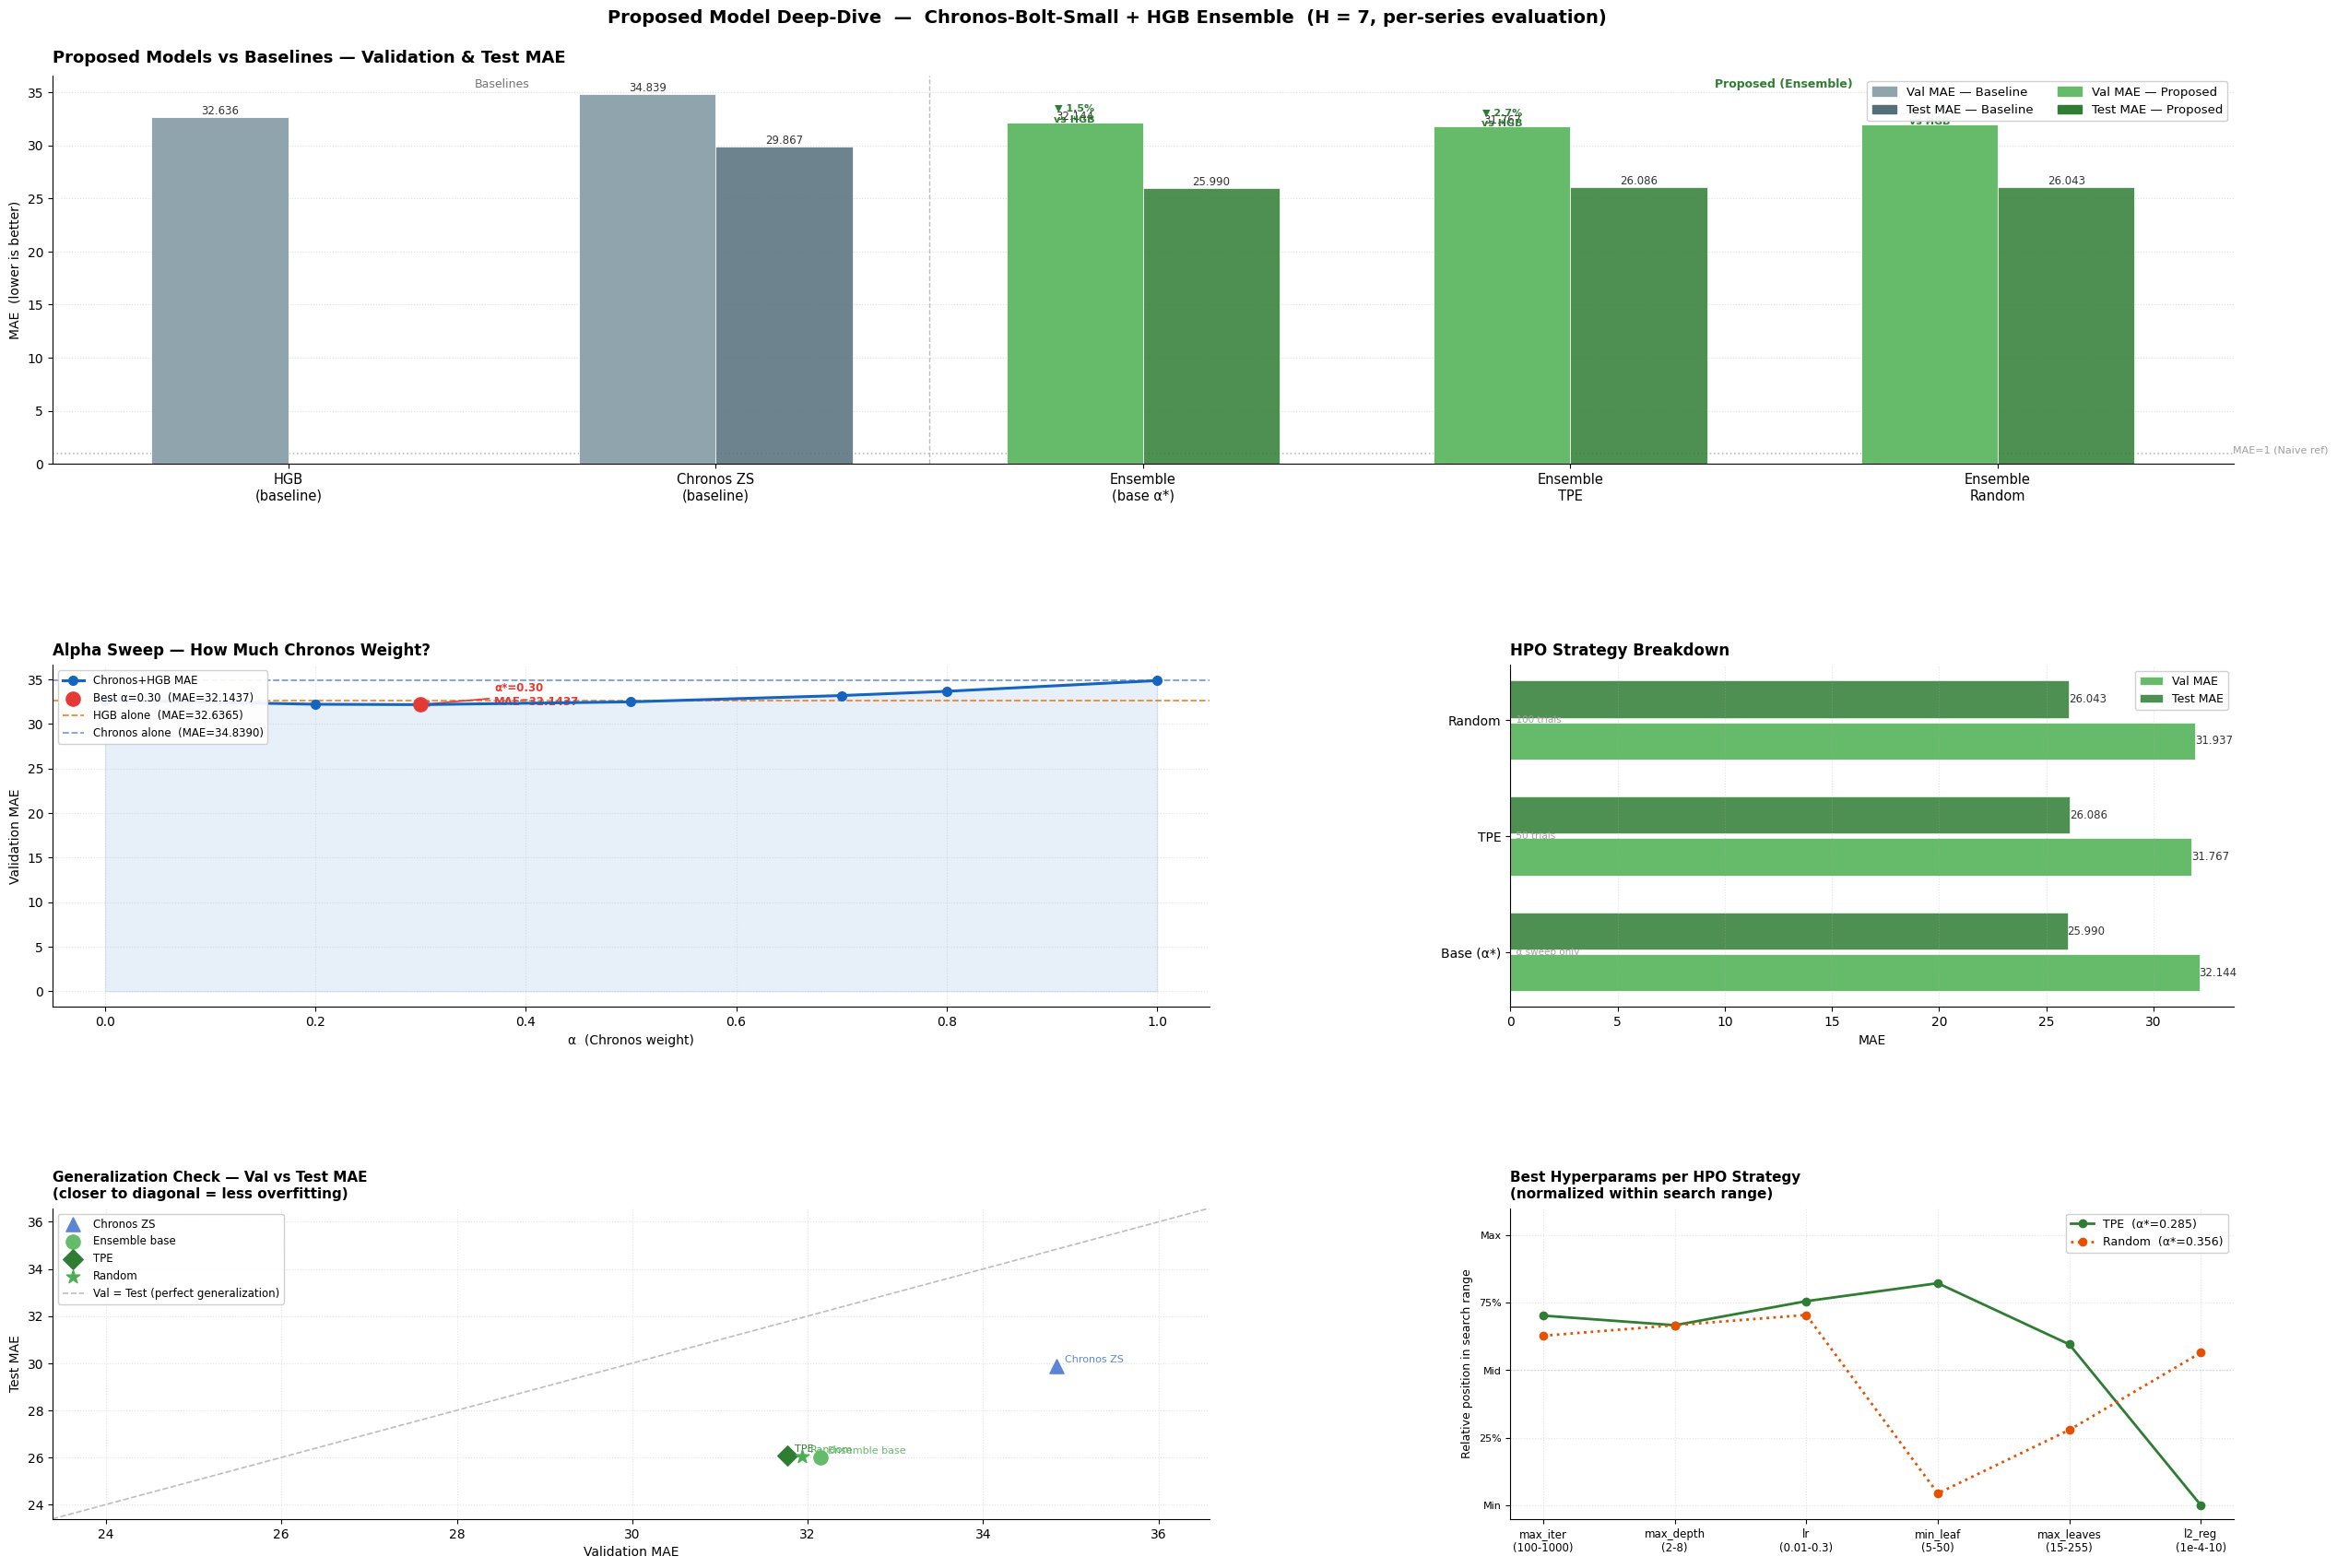

✅ Saved → outputs/proposed_model_analysis.png


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np, math

# ── Data for plots ─────────────────────────────────────────────────────────────
MODELS = [
    # (display_label,      val_MAE,  test_MAE, category)
    ("HGB\n(baseline)",    hgb_vm,    hgb_tm,    "baseline"),
    ("Chronos ZS\n(baseline)", chron_vm, chron_tm, "baseline"),
    ("Ensemble\n(base α*)", ens_vm,   ens_tm,    "proposed"),
    ("Ensemble\nTPE",      tpe_vm,    tpe_tm,    "proposed"),
    ("Ensemble\nRandom",   rand_vm,   rand_tm,   "proposed"),
]
labels    = [m[0] for m in MODELS]
val_MAEs = [m[1] for m in MODELS]
tst_maes = [m[2] for m in MODELS]
cats      = [m[3] for m in MODELS]

# Colors
C_VAL_BASE  = "#90a4ae"
C_TST_BASE  = "#546e7a"
C_VAL_PROP  = "#66bb6a"
C_TST_PROP  = "#2e7d32"
C_CHRON     = "#5c85d6"

def _bar_colors(val_or_test, cat_list):
    out = []
    for c in cat_list:
        if val_or_test == "val":
            out.append(C_VAL_PROP if c == "proposed" else C_VAL_BASE)
        else:
            out.append(C_TST_PROP if c == "proposed" else C_TST_BASE)
    return out

# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(26, 18))
gs = fig.add_gridspec(
    3, 2,
    height_ratios=[2.5, 2.2, 2.0],
    width_ratios=[1.6, 1.0],
    hspace=0.58, wspace=0.32,
    top=0.93, bottom=0.06, left=0.06, right=0.97,
)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 1 (row 0, spans both cols): Grouped bar — Val vs Test MAE per model
# ═══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :])

x      = np.arange(len(labels))
width  = 0.32
bars_v = ax1.bar(x - width/2, val_MAEs, width,
                 color=_bar_colors("val", cats),
                 label="Val MAE", edgecolor="white", linewidth=0.6, zorder=3)
bars_t = ax1.bar(x + width/2, tst_maes, width,
                 color=_bar_colors("tst", cats),
                 label="Test MAE", edgecolor="white", linewidth=0.6, zorder=3,
                 alpha=0.85)

# Annotate bar values
for bar in list(bars_v) + list(bars_t):
    v = bar.get_height()
    if not math.isnan(v):
        ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, color="#333")

# Improvement arrows for proposed models (vs HGB baseline)
for i, (_, vm, tm, cat) in enumerate(MODELS):
    if cat != "proposed" or math.isnan(vm):
        continue
    imp = _pct(hgb_vm, vm)
    color = "#2e7d32" if imp > 0 else "#c62828"
    symbol = "▼" if imp > 0 else "▲"
    ax1.annotate(f"{symbol} {abs(imp):.1f}%\nvs HGB",
                 xy=(i - width/2, vm), xytext=(i - width/2, vm + 0.05),
                 ha="center", fontsize=8, color=color, fontweight="bold",
                 arrowprops=dict(arrowstyle="-", color=color, lw=0.8))

ax1.axhline(1.0, color="#9e9e9e", linestyle=":", linewidth=1.2, alpha=0.7, zorder=2)
ax1.text(len(labels) - 0.45, 1.01, "MAE=1 (Naive ref)", fontsize=8, color="#9e9e9e")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10.5)
ax1.set_ylabel("MAE  (lower is better)", fontsize=10)
ax1.set_title("Proposed Models vs Baselines — Validation & Test MAE",
              fontsize=13, fontweight="bold", loc="left", pad=10)
ax1.set_ylim(bottom=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.4, zorder=0)

legend_patches = [
    mpatches.Patch(color=C_VAL_BASE, label="Val MAE — Baseline"),
    mpatches.Patch(color=C_TST_BASE, label="Test MAE — Baseline"),
    mpatches.Patch(color=C_VAL_PROP, label="Val MAE — Proposed"),
    mpatches.Patch(color=C_TST_PROP, label="Test MAE — Proposed"),
]
ax1.legend(handles=legend_patches, loc="upper right", fontsize=9.5,
           framealpha=0.92, ncol=2)

# Add category divider
ax1.axvline(1.5, color="#bdbdbd", linestyle="--", linewidth=1, zorder=2)
ax1.text(0.5,  ax1.get_ylim()[1] * 0.97, "Baselines",         ha="center", fontsize=9,  color="#757575")
ax1.text(3.5,  ax1.get_ylim()[1] * 0.97, "Proposed (Ensemble)", ha="center", fontsize=9, color="#2e7d32", fontweight="bold")

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 2 (row 1, col 0): Alpha sweep curve
# ═══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1, 0])

alphas_sorted = sorted(sweep.keys())
maes_sorted  = [sweep[a] for a in alphas_sorted]

ax2.plot(alphas_sorted, maes_sorted, color="#1565c0", linewidth=2.2,
         marker="o", markersize=7, zorder=5, label="Chronos+HGB MAE")
ax2.fill_between(alphas_sorted, maes_sorted,
                 alpha=0.1, color="#1565c0", zorder=1)

# Highlight best alpha
best_mae_sweep = sweep[ENSEMBLE_ALPHA]
ax2.scatter([ENSEMBLE_ALPHA], [best_mae_sweep],
            color="#e53935", s=120, zorder=10, label=f"Best α={ENSEMBLE_ALPHA:.2f}  (MAE={best_mae_sweep:.4f})")
ax2.annotate(f"α*={ENSEMBLE_ALPHA:.2f}\nMAE={best_mae_sweep:.4f}",
             xy=(ENSEMBLE_ALPHA, best_mae_sweep),
             xytext=(ENSEMBLE_ALPHA + 0.07, best_mae_sweep + 0.01),
             fontsize=8.5, color="#e53935", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#e53935", lw=1.2))

# Horizontal reference lines
ax2.axhline(hgb_vm,   color="#ef6c00", linestyle="--", linewidth=1.3, alpha=0.8,
            label=f"HGB alone  (MAE={hgb_vm:.4f})")
ax2.axhline(chron_vm, color="#5c85d6", linestyle="--", linewidth=1.3, alpha=0.8,
            label=f"Chronos alone  (MAE={chron_vm:.4f})")

ax2.set_xlabel("α  (Chronos weight)", fontsize=10)
ax2.set_ylabel("Validation MAE", fontsize=10)
ax2.set_title("Alpha Sweep — How Much Chronos Weight?",
              fontsize=12, fontweight="bold", loc="left", pad=8)
ax2.legend(fontsize=8.5, framealpha=0.92, loc="upper left")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(linestyle=":", alpha=0.35)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 3 (row 1, col 1): HPO strategy comparison — val & test MAE dots
# ═══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 1])

hpo_labels = ["Base (α*)", "TPE", "Random"]
hpo_val    = [ens_vm,   tpe_vm,   rand_vm]
hpo_tst    = [ens_tm,   tpe_tm,   rand_tm]
hpo_trials = [0, 50, 100]

y_pos = np.arange(len(hpo_labels))
ax3.barh(y_pos - 0.18, hpo_val, 0.32, color="#66bb6a", label="Val MAE",
         edgecolor="white", linewidth=0.5)
ax3.barh(y_pos + 0.18, hpo_tst, 0.32, color="#2e7d32", label="Test MAE",
         edgecolor="white", linewidth=0.5, alpha=0.85)

for y, vv, vt in zip(y_pos, hpo_val, hpo_tst):
    if not math.isnan(vv):
        ax3.text(vv + 0.002, y - 0.18, f"{vv:.3f}", va="center", fontsize=8.5, color="#333")
    if not math.isnan(vt):
        ax3.text(vt + 0.002, y + 0.18, f"{vt:.3f}", va="center", fontsize=8.5, color="#333")

# Annotate n_trials
for y, n in zip(y_pos, hpo_trials):
    label = f"{n} trials" if n > 0 else "α sweep only"
    ax3.text(ax3.get_xlim()[0] if ax3.get_xlim()[0] > 0 else 0,
             y, f"  {label}", va="center", ha="left", fontsize=7.5, color="#9e9e9e")

ax3.set_yticks(y_pos)
ax3.set_yticklabels(hpo_labels, fontsize=10)
ax3.set_xlabel("MAE", fontsize=10)
ax3.set_title("HPO Strategy Breakdown",
              fontsize=12, fontweight="bold", loc="left", pad=8)
ax3.legend(fontsize=9, framealpha=0.92)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.grid(axis="x", linestyle=":", alpha=0.35)
ax3.set_xlim(left=0)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 4 (row 2, col 0): Val vs Test scatter — all models (generalization check)
# ═══════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[2, 0])

scatter_data = [
    # (label, val_MAE, test_MAE, color, marker)
    ("HGB",          hgb_vm,   hgb_tm,   "#ef6c00", "s"),
    ("Chronos ZS",   chron_vm, chron_tm, "#5c85d6", "^"),
    ("Ensemble base",ens_vm,   ens_tm,   "#66bb6a", "o"),
    ("TPE",          tpe_vm,   tpe_tm,   "#2e7d32", "D"),
    ("Random",       rand_vm,  rand_tm,  "#4cae52", "*"),
]
valid_sc = [(l, v, t, c, m) for l, v, t, c, m in scatter_data
            if not (math.isnan(v) or math.isnan(t))]

for label, vm, tm, color, marker in valid_sc:
    ax4.scatter(vm, tm, color=color, marker=marker, s=120, zorder=5, label=label)
    ax4.annotate(label, (vm, tm), textcoords="offset points",
                 xytext=(6, 3), fontsize=8, color=color)

# y=x reference line (perfect generalization)
if valid_sc:
    all_v = [r[1] for r in valid_sc] + [r[2] for r in valid_sc]
    lo, hi = min(all_v) * 0.9, max(all_v) * 1.05
    ax4.plot([lo, hi], [lo, hi], color="#bdbdbd", linestyle="--", linewidth=1.2,
             label="Val = Test (perfect generalization)")
    ax4.set_xlim(lo, hi)
    ax4.set_ylim(lo, hi)

ax4.set_xlabel("Validation MAE", fontsize=10)
ax4.set_ylabel("Test MAE", fontsize=10)
ax4.set_title("Generalization Check — Val vs Test MAE\n(closer to diagonal = less overfitting)",
              fontsize=11, fontweight="bold", loc="left", pad=8)
ax4.legend(fontsize=8.5, framealpha=0.92, loc="upper left")
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.grid(linestyle=":", alpha=0.35)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 5 (row 2, col 1): Best HPO hyperparams radar / bar
# ═══════════════════════════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[2, 1])

# Show relative hyperparameter values (normalized) for each HPO strategy
_hp_keys = ["max_iter", "max_depth", "learning_rate",
            "min_samples_leaf", "max_leaf_nodes", "l2_regularization"]
_hp_nice = ["max_iter\n(100-1000)", "max_depth\n(2-8)", "lr\n(0.01-0.3)",
            "min_leaf\n(5-50)",    "max_leaves\n(15-255)", "l2_reg\n(1e-4-10)"]
_hp_ranges = [(100, 1000), (2, 8), (0.01, 0.3), (5, 50), (15, 255), (1e-4, 10)]

strategy_styles = [
    ("tpe",   "TPE",    "#2e7d32", "-"),
    ("rand",  "Random", "#e65100", ":"),
]

# Normalize each param to [0, 1] within its range for visual comparison
has_any = False
for key, label, color, ls in strategy_styles:
    if key not in _best_hgb_params:
        continue
    bp, _, alp = _best_hgb_params[key]
    norm_vals = []
    for hk, (lo, hi) in zip(_hp_keys, _hp_ranges):
        v = bp.get(hk, float("nan"))
        norm_vals.append((float(v) - lo) / (hi - lo) if not math.isnan(float(v)) else 0.5)
    x_pos = np.arange(len(_hp_keys))
    ax5.plot(x_pos, norm_vals, color=color, linewidth=2, linestyle=ls,
             marker="o", markersize=6, label=f"{label}  (α*={float(alp):.3f})", zorder=5)
    has_any = True

if has_any:
    ax5.set_xticks(np.arange(len(_hp_keys)))
    ax5.set_xticklabels(_hp_nice, fontsize=8.5)
    ax5.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax5.set_yticklabels(["Min", "25%", "Mid", "75%", "Max"], fontsize=8)
    ax5.axhline(0.5, color="#bdbdbd", linestyle=":", linewidth=1, alpha=0.6)
    ax5.set_ylabel("Relative position in search range", fontsize=9)
    ax5.set_title("Best Hyperparams per HPO Strategy\n(normalized within search range)",
                  fontsize=11, fontweight="bold", loc="left", pad=8)
    ax5.legend(fontsize=9, framealpha=0.92)
    ax5.spines["top"].set_visible(False)
    ax5.spines["right"].set_visible(False)
    ax5.grid(linestyle=":", alpha=0.35)
    ax5.set_ylim(-0.05, 1.1)
else:
    ax5.text(0.5, 0.5, "HPO strategies did not run\n(CHRONOS_AVAILABLE = False?)",
             ha="center", va="center", transform=ax5.transAxes,
             fontsize=11, color="#9e9e9e")
    ax5.axis("off")

# ── Final touches ─────────────────────────────────────────────────────────────
fig.suptitle(
    "Proposed Model Deep-Dive  —  Chronos-Bolt-Small + HGB Ensemble  (H = 7, per-series evaluation)",
    fontsize=14, fontweight="bold", y=0.97,
)
plt.savefig(os.path.join(OUTPUT_DIR, "proposed_model_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/proposed_model_analysis.png")

## 16. Visualize Test Set: Actual vs Predicted

So sánh từng nhóm mô hình với giá trị thực trên tập test (Nov 2023 – Jan 2024).
- **Panel 1**: Statistical Baselines (Naive, SNaive, ARIMA, SARIMAX, ETS)
- **Panel 2**: ML Models (Ridge, HGB, LSTM)
- **Panel 3**: RMSE ranking — tất cả model kể cả per-series (Prophet, Chronos, Ensemble)

  Chronos rolling window 1/13 done
  Chronos rolling window 2/13 done
  Chronos rolling window 3/13 done
  Chronos rolling window 4/13 done
  Chronos rolling window 5/13 done
  Chronos rolling window 6/13 done
  Chronos rolling window 7/13 done
  Chronos rolling window 8/13 done
  Chronos rolling window 9/13 done
  Chronos rolling window 10/13 done
  Chronos rolling window 11/13 done
  Chronos rolling window 12/13 done
  Chronos rolling window 13/13 done


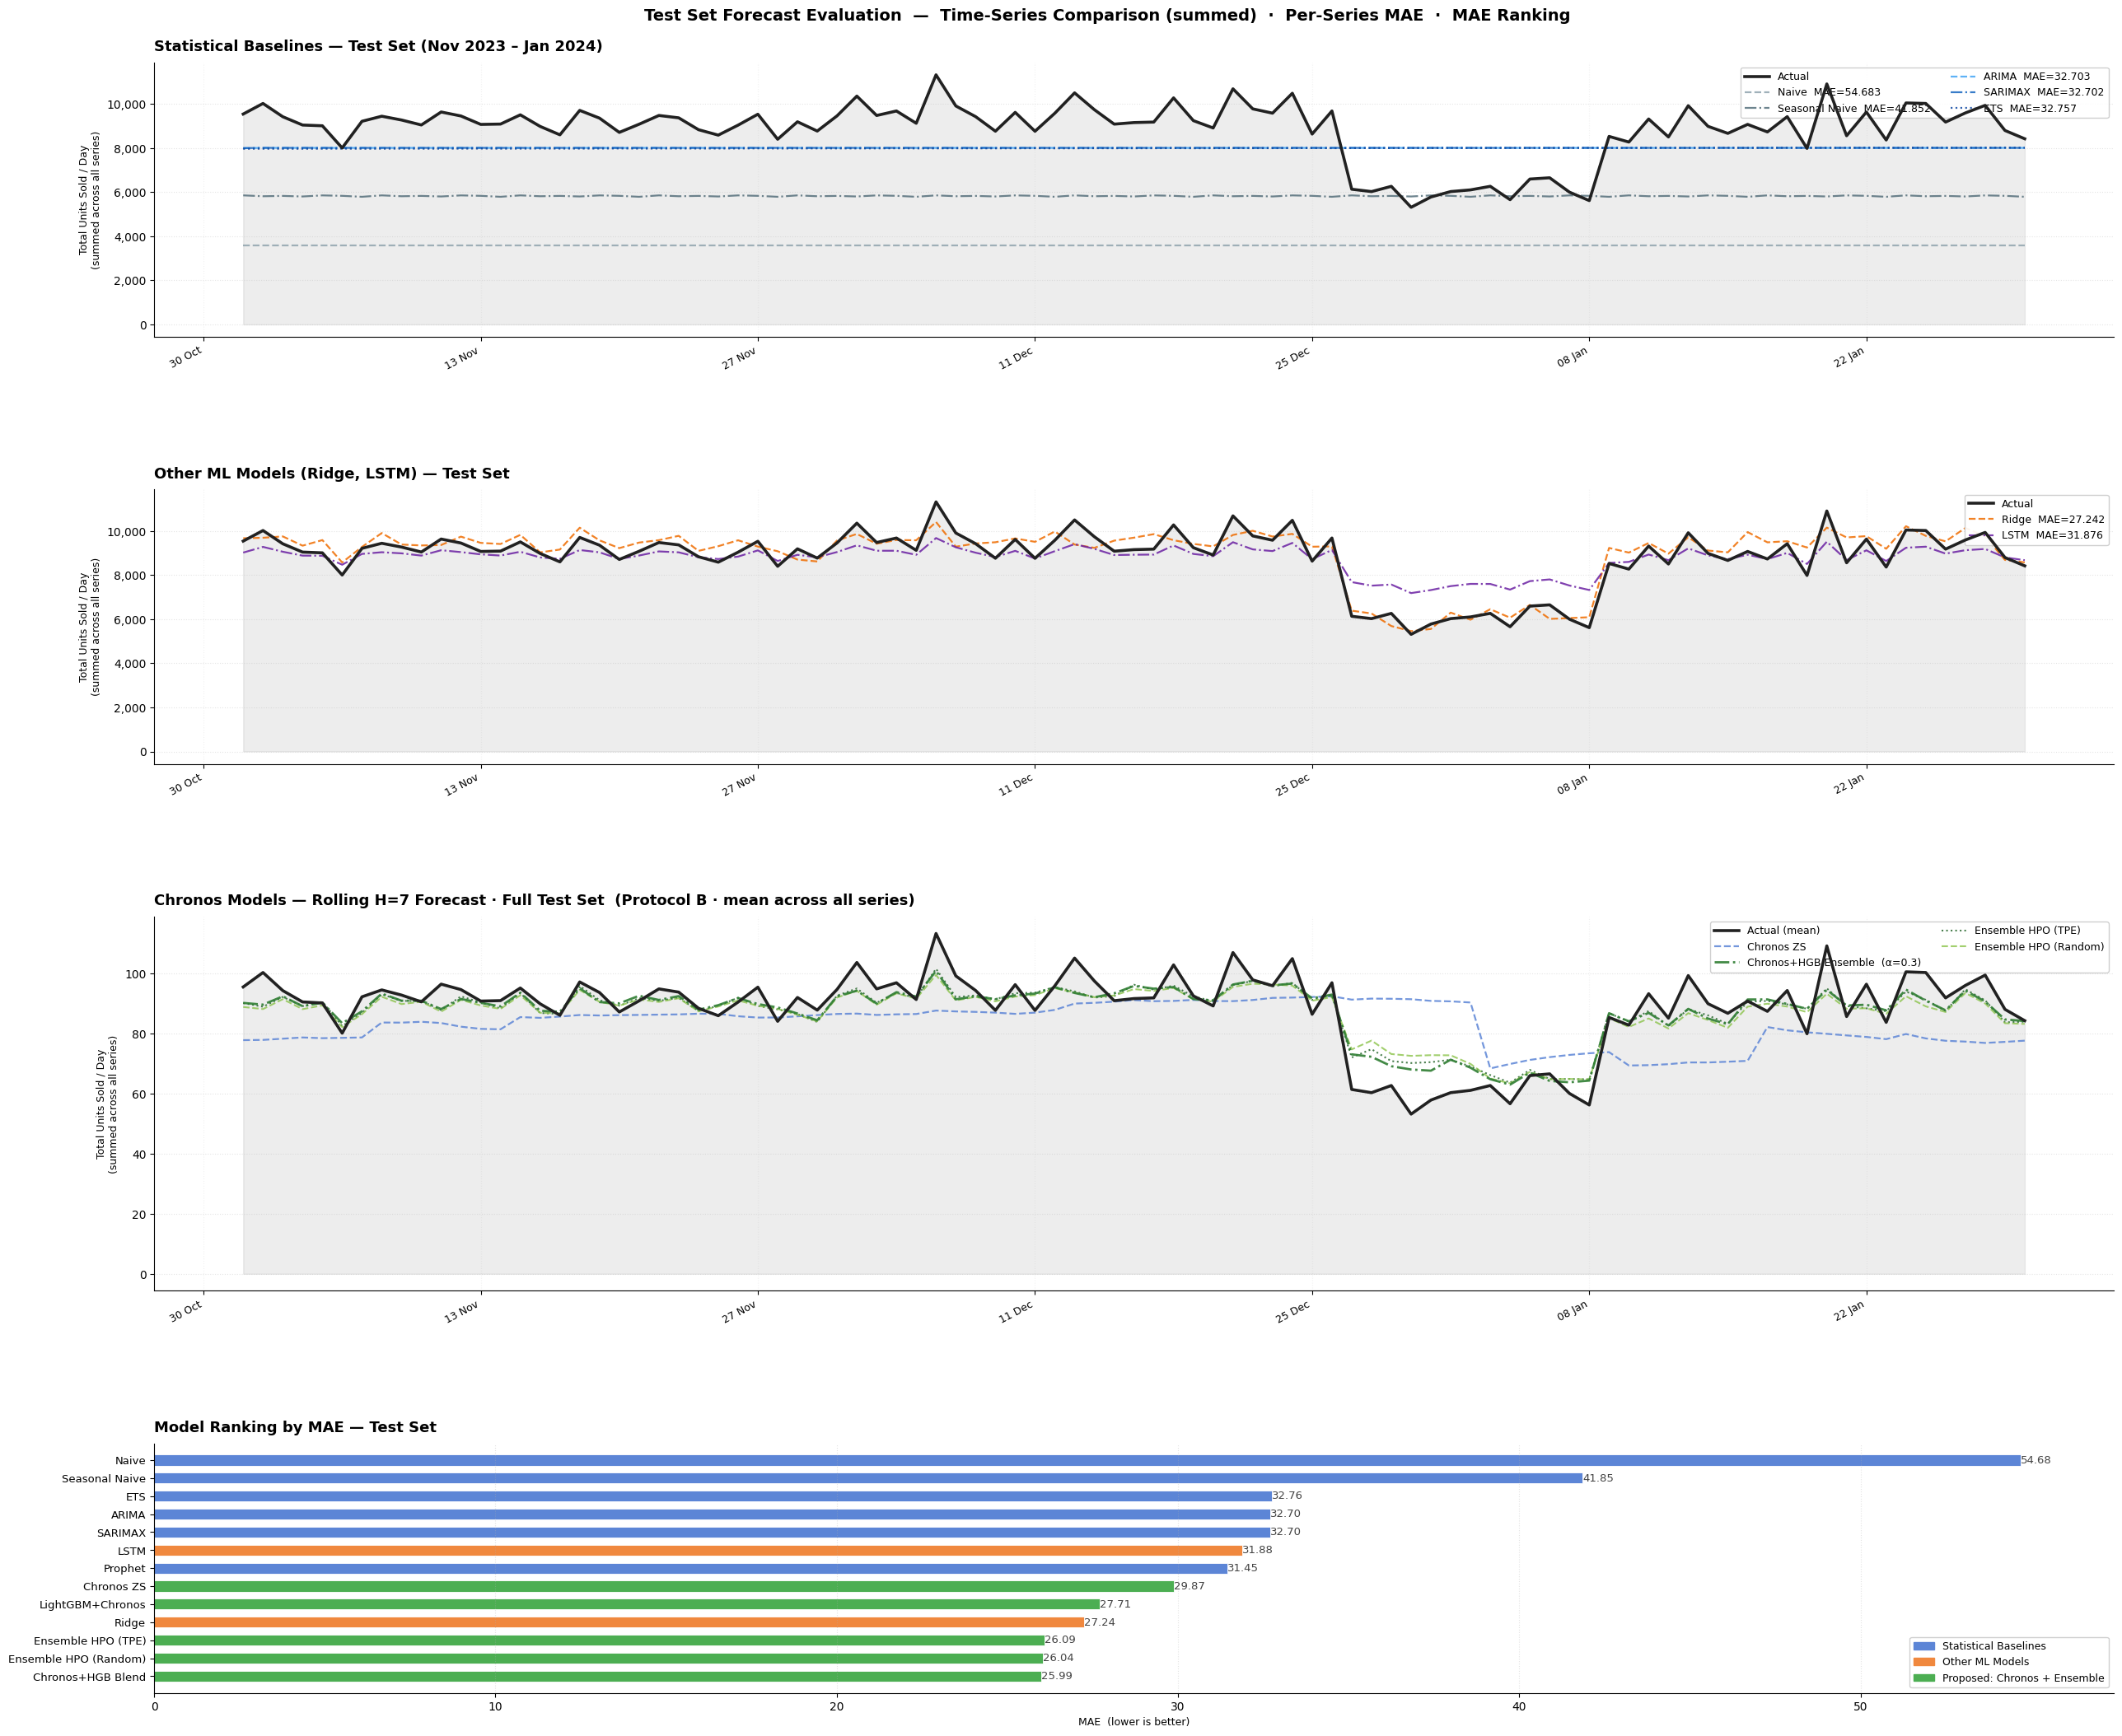

✅ Saved → outputs/test_visualization.png


In [35]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── Helpers ───────────────────────────────────────────────────────────────────
def _daily_sum(pred_arr, ref_df):
    """Sum per-row predictions by calendar date → pd.Series indexed by date."""
    tmp = ref_df[["Date"]].copy().reset_index(drop=True)
    tmp["Date"] = pd.to_datetime(tmp["Date"])
    tmp["_p"] = np.asarray(pred_arr, dtype=float)
    return tmp.groupby("Date")["_p"].sum().sort_index()

def _get_mae(model_key):
    row = test_table[test_table["model"] == model_key]
    if row.empty:
        return float("nan")
    return float(row["test_MAE"].iloc[0])

# ── References ────────────────────────────────────────────────────────────────
_ref_full = test_df.copy()
_ref_full["Date"] = pd.to_datetime(_ref_full["Date"])

# For Ridge / HGB: use the same dropna reference used to build X_test
# HGB is computed here for internal use only — not displayed in any panel
_ref_ml = df_feat[df_feat["Date"] > VAL_END].copy()
_ref_ml["Date"] = pd.to_datetime(_ref_ml["Date"])
_ref_ml = _ref_ml.dropna().reset_index(drop=True)
_ = _daily_sum(test_pred_hgb, _ref_ml)   # keep HGB code path active, result discarded

# Aggregate actual
agg_act = _ref_full.groupby("Date")["Units Sold"].sum().sort_index()

# ── Panel data: Statistical Baselines ─────────────────────────────────────────
# (label, series, color, linestyle, mae_key)
G1 = [
    ("Naive",          _daily_sum(test_pred_naive,   _ref_full), "#90a4ae", "--",  "naive"),
    ("Seasonal Naive", _daily_sum(test_pred_snaive,  _ref_full), "#546e7a", "-.",  "seasonal_naive"),
    ("ARIMA",          _daily_sum(test_pred_arima,   _ref_full), "#42a5f5", "--",  "arima"),
    ("SARIMAX",        _daily_sum(test_pred_sarimax, _ref_full), "#1565c0", "-.",  "sarimax"),
    ("ETS",            _daily_sum(test_pred_ets,     _ref_full), "#0d47a1", ":",   "ets"),
]

# ── Panel data: Other ML Models (Ridge, LSTM — HGB excluded from display) ─────
G2 = [
    ("Ridge",  _daily_sum(test_pred_ridge,    _ref_ml),   "#ef6c00", "--",  "ridge_lag_features"),
    ("LSTM",   _daily_sum(test_pred_lstm_uni, _ref_full), "#6a1fa2", "-.",  "lstm_univariate"),
]

# ── Name & category mapping for MAE bar chart (HGB excluded) ─────────────────
_nice = {
    "naive": "Naive",  "seasonal_naive": "Seasonal Naive",
    "arima": "ARIMA",  "sarimax": "SARIMAX",  "ets": "ETS",
    "prophet": "Prophet",
    "ridge_lag_features": "Ridge",  "lstm_univariate": "LSTM",
    "chronos_bolt_small": "Chronos ZS",
    "chronos_hgb_ensemble": "Chronos+HGB Blend",
    "lgbm_chronos": "LightGBM+Chronos",
    "ensemble_tpe": "Ensemble HPO (TPE)",
    "ensemble_rand": "Ensemble HPO (Random)",
}
_EXCLUDE   = {"hgb_lag_features"}    # not shown anywhere in this figure
_stat_keys = {"naive","seasonal_naive","arima","sarimax","ets","prophet"}
_ml_keys   = {"ridge_lag_features","lstm_univariate"}
_prop_keys = {"chronos_bolt_small","chronos_hgb_ensemble","lgbm_chronos",
              "ensemble_tpe","ensemble_rand"}

def _bar_color(m):
    if m in _stat_keys: return "#5c85d6"
    if m in _ml_keys:   return "#f0883e"
    if m in _prop_keys: return "#4cae52"
    return "#9e9e9e"

# ── Figure: 4 panels ──────────────────────────────────────────────────────────
ACTUAL_C = "#212121"

fig = plt.figure(figsize=(26, 22))
gs = fig.add_gridspec(
    4, 1,
    height_ratios=[2.2, 2.2, 3.0, 2.0],
    hspace=0.52,
    top=0.94, bottom=0.04, left=0.055, right=0.97,
)

# ── Shared helpers ────────────────────────────────────────────────────────────
def _style_ts_ax(ax, title, n_legend_cols=2):
    ax.set_title(title, fontsize=13, fontweight="bold", loc="left", pad=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.get_xticklabels(), rotation=28, ha="right", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.set_ylabel("Total Units Sold / Day\n(summed across all series)", fontsize=9)
    ax.grid(axis="y", linestyle=":", alpha=0.4, color="#bdbdbd", zorder=0)
    ax.grid(axis="x", linestyle=":", alpha=0.2, color="#bdbdbd", zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", fontsize=9, framealpha=0.93,
              ncol=n_legend_cols, handlelength=2.4, labelspacing=0.5)

def _plot_ts(ax, group):
    ax.fill_between(agg_act.index, agg_act.values, alpha=0.08, color=ACTUAL_C, zorder=1)
    ax.plot(agg_act.index, agg_act.values,
            color=ACTUAL_C, linewidth=2.6, label="Actual", zorder=10)
    for label, series, color, ls, mae_key in group:
        mae_val = _get_mae(mae_key)
        mae_str = f"  MAE={mae_val:.3f}" if not np.isnan(mae_val) else ""
        ax.plot(series.reindex(agg_act.index).index,
                series.reindex(agg_act.index).values,
                color=color, linewidth=1.6, linestyle=ls, alpha=0.85,
                label=f"{label}{mae_str}", zorder=5)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 1: Statistical Baselines
# ═══════════════════════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0])
_plot_ts(ax1, G1)
_style_ts_ax(ax1, "Statistical Baselines — Test Set (Nov 2023 – Jan 2024)", n_legend_cols=2)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 2: Other ML Models (Ridge, LSTM)
# ═══════════════════════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1])
_plot_ts(ax2, G2)
_style_ts_ax(ax2, "Other ML Models (Ridge, LSTM) — Test Set", n_legend_cols=1)

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 3: Chronos Models — Rolling H=7 Forecast (Protocol B)
# Full test set coverage via expanding-context rolling windows
# ═══════════════════════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[2])

if CHRONOS_AVAILABLE and ENSEMBLE_AVAILABLE:
    _all_test_dates = pd.to_datetime(sorted(test_df["Date"].unique()))
    _n_test = len(_all_test_dates)
    _n_windows = int(np.ceil(_n_test / HORIZON_DAYS))

    # ── Rolling Chronos predictions (expanding context) ───────────────────────
    _series_data = {}
    for (st, pr), grp in df.groupby(['Store ID', 'Product ID']):
        s = grp.set_index('Date')['Units Sold'].sort_index()
        s.index = pd.to_datetime(s.index)
        if len(s[s.index > VAL_END]) < HORIZON_DAYS:
            continue
        _series_data[(st, pr)] = s

    _c_rolling = {}
    for w in range(_n_windows):
        _ctx_end = VAL_END if w == 0 else _all_test_dates[w * HORIZON_DAYS - 1]
        _start_idx = w * HORIZON_DAYS
        _end_idx = min(_start_idx + HORIZON_DAYS, _n_test)
        _n_days_w = _end_idx - _start_idx

        ctxs, keys = [], []
        for key, s in _series_data.items():
            ctx = s[s.index <= _ctx_end]
            if len(ctx) < 14:
                continue
            ctxs.append(_torch.tensor(ctx.values.astype(np.float32)))
            keys.append(key)

        if not ctxs:
            continue
        _fc = chronos_pipeline.predict(ctxs, prediction_length=HORIZON_DAYS)
        _preds_w = _fc.median(dim=1).values.numpy()
        for i, k in enumerate(keys):
            if k not in _c_rolling:
                _c_rolling[k] = np.full(_n_test, np.nan)
            _c_rolling[k][_start_idx:_end_idx] = np.clip(
                _preds_w[i][:_n_days_w], 0, None)
        print(f"  Chronos rolling window {w+1}/{_n_windows} done")

    # ── Full HGB predictions per series (aligned to _all_test_dates) ──────────
    _h_full = {}
    _tmp_hgb = _ref_ml.copy().reset_index(drop=True)
    _tmp_hgb['_hgb'] = test_pred_hgb
    for (st, pr), grp in _tmp_hgb.groupby(['Store ID', 'Product ID']):
        rows = grp.sort_values('Date').set_index('Date')
        _h_full[(st, pr)] = (rows['_hgb']
                             .reindex(_all_test_dates, fill_value=0.0)
                             .values.astype(float))

    # ── Mean actual per date (for Panel 3 only) ─────────────────────────────────
    _act_mean = _ref_full.groupby("Date")["Units Sold"].mean().sort_index()

    # ── Aggregate (mean): Chronos ZS ─────────────────────────────────────────
    _agg_chron = np.zeros(_n_test)
    _n_chron = 0
    for preds in _c_rolling.values():
        _agg_chron += np.nan_to_num(preds)
        _n_chron += 1
    if _n_chron > 0:
        _agg_chron /= _n_chron
    _chron_series = pd.Series(_agg_chron, index=_all_test_dates)

    # ── Aggregate (mean): Ensemble base (per-series blend, then mean) ─────────
    _agg_ens = np.zeros(_n_test)
    _n_ens = 0
    for key in _c_rolling:
        if key not in _h_full:
            continue
        _c = np.nan_to_num(_c_rolling[key])
        _h = _h_full[key]
        _agg_ens += np.clip(ENSEMBLE_ALPHA * _c + (1 - ENSEMBLE_ALPHA) * _h, 0, None)
        _n_ens += 1
    if _n_ens > 0:
        _agg_ens /= _n_ens
    _ens_series = pd.Series(_agg_ens, index=_all_test_dates)

    # ── HPO ensemble variants (mean) ──────────────────────────────────────────
    _hpo_series = {}
    for hpo_key, hpo_label, hpo_color, hpo_ls in [
        ("tpe",   "Ensemble HPO (TPE)",    "#1b5e20", ":"),
        ("rand",  "Ensemble HPO (Random)", "#8bc34a", "--"),
    ]:
        if hpo_key in _best_hgb_params:
            _bp, _hgb_hpo, _alp_hpo = _best_hgb_params[hpo_key]
            _hpo_arr = _hgb_hpo.predict(
                _ref_ml[[c for c in _ref_ml.columns if c in feature_cols]])
            _tmp_hpo = _ref_ml.copy().reset_index(drop=True)
            _tmp_hpo['_hgb'] = _hpo_arr
            _h_hpo_full = {}
            for (st, pr), grp in _tmp_hpo.groupby(['Store ID', 'Product ID']):
                rows = grp.sort_values('Date').set_index('Date')
                _h_hpo_full[(st, pr)] = (rows['_hgb']
                                         .reindex(_all_test_dates, fill_value=0.0)
                                         .values.astype(float))
            _agg_hpo = np.zeros(_n_test)
            _n_hpo = 0
            for key in _c_rolling:
                if key not in _h_hpo_full:
                    continue
                _c = np.nan_to_num(_c_rolling[key])
                _h = _h_hpo_full[key]
                _agg_hpo += np.clip(_alp_hpo * _c + (1 - _alp_hpo) * _h, 0, None)
                _n_hpo += 1
            if _n_hpo > 0:
                _agg_hpo /= _n_hpo
            _hpo_series[hpo_label] = (pd.Series(_agg_hpo, index=_all_test_dates),
                                      hpo_color, hpo_ls)

    # ── Plot (mean per series) ────────────────────────────────────────────────
    ax3.fill_between(_act_mean.index, _act_mean.values,
                     alpha=0.08, color=ACTUAL_C, zorder=1)
    ax3.plot(_act_mean.index, _act_mean.values,
             color=ACTUAL_C, linewidth=2.6, label="Actual (mean)", zorder=10)
    ax3.plot(_chron_series.reindex(_act_mean.index).index,
             _chron_series.reindex(_act_mean.index).values,
             color="#5c85d6", linewidth=1.6, linestyle="--", alpha=0.85, zorder=5,
             label="Chronos ZS")
    ax3.plot(_ens_series.reindex(_act_mean.index).index,
             _ens_series.reindex(_act_mean.index).values,
             color="#2e7d32", linewidth=2.0, linestyle="-.", alpha=0.9, zorder=6,
             label=f"Chronos+HGB Ensemble  (α={ENSEMBLE_ALPHA})")
    for lbl, (s_hpo, col, ls) in _hpo_series.items():
        ax3.plot(s_hpo.reindex(_act_mean.index).index,
                 s_hpo.reindex(_act_mean.index).values,
                 color=col, linewidth=1.5, linestyle=ls, alpha=0.8, zorder=5,
                 label=lbl)

    ax3.set_ylabel("Mean Units Sold / Day\n(averaged across all series)", fontsize=9)
    _style_ts_ax(ax3,
                 "Chronos Models — Rolling H=7 Forecast · Full Test Set  "
                 "(Protocol B · mean across all series)",
                 n_legend_cols=2)

else:
    ax3.text(0.5, 0.5,
             "Chronos / Ensemble not available\n(CHRONOS_AVAILABLE = False)",
             ha="center", va="center", transform=ax3.transAxes,
             fontsize=12, color="#9e9e9e")
    _style_ts_ax(ax3, "Chronos Models — Rolling H=7 Test Set")

# ═══════════════════════════════════════════════════════════════════════════════
# Panel 4: MAE ranking bar — all models except HGB
# ═══════════════════════════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[3])

_bar_df = (
    test_table[["model","test_MAE"]]
    .dropna(subset=["test_MAE"])
    .query("model not in @_EXCLUDE")
    .copy()
    .assign(label=lambda d: d["model"].map(lambda x: _nice.get(x, x)))
    .sort_values("test_MAE", ascending=True)
    .reset_index(drop=True)
)

bar_colors = [_bar_color(m) for m in _bar_df["model"]]
bars = ax4.barh(_bar_df["label"], _bar_df["test_MAE"],
                color=bar_colors, height=0.60,
                edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, _bar_df["test_MAE"]):
    ax4.text(bar.get_width() + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", ha="left", fontsize=9.5, color="#424242")

ax4.set_xlabel("MAE  (lower is better)", fontsize=9)
ax4.set_title("Model Ranking by MAE — Test Set",
              fontsize=13, fontweight="bold", loc="left", pad=10)
ax4.set_xlim(left=0)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.grid(axis="x", linestyle=":", alpha=0.35, zorder=0)
ax4.tick_params(axis="y", labelsize=9.5)

legend_patches = [
    mpatches.Patch(color="#5c85d6", label="Statistical Baselines"),
    mpatches.Patch(color="#f0883e", label="Other ML Models"),
    mpatches.Patch(color="#4cae52", label="Proposed: Chronos + Ensemble"),
]
ax4.legend(handles=legend_patches, loc="lower right", fontsize=9, framealpha=0.92)

fig.suptitle(
    "Test Set Forecast Evaluation  —  Time-Series Comparison (summed)  ·  Per-Series MAE  ·  MAE Ranking",
    fontsize=14, fontweight="bold", y=0.97,
)
plt.savefig(os.path.join(OUTPUT_DIR, "test_visualization.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → outputs/test_visualization.png")

## 16. Save results (reproducibility)

In [36]:
import shutil
from datetime import datetime

# ── Save results to outputs/ ──────────────────────────────────────────────────
results = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "seed": RANDOM_SEED,
    "val_table":        val_table.to_dict(orient="records"),
    "test_table":       test_table.to_dict(orient="records"),
    "top_features_hpo": imp_df_hpo.head(20).to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "results_h7_timeseries.json"), "w", encoding="utf-8") as _f:
    json.dump(results, _f, ensure_ascii=False, indent=2)
test_table.to_csv(os.path.join(OUTPUT_DIR, "test_table_h7_timeseries.csv"), index=False)
imp_df_hpo.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_h7_timeseries.csv"), index=False)
print(f"✅ {OUTPUT_DIR}/results_h7_timeseries.json")
print(f"✅ {OUTPUT_DIR}/test_table_h7_timeseries.csv  ({len(test_table)} models)")
print(f"✅ {OUTPUT_DIR}/feature_importance_h7_timeseries.csv  ({len(imp_df_hpo)} features)")

# ── Kaggle export — copy all result files to /kaggle/working/result/ ──────────
if os.path.exists("/kaggle/working"):
    _kaggle_out = "/kaggle/working/result"
    os.makedirs(_kaggle_out, exist_ok=True)

    # JSON + summary CSVs
    with open(os.path.join(_kaggle_out, "results_h7.json"), "w", encoding="utf-8") as _f:
        json.dump(results, _f, ensure_ascii=False, indent=2)
    test_table.to_csv(os.path.join(_kaggle_out, "test_table_h7_timeseries.csv"), index=False)
    imp_df_hpo.to_csv(os.path.join(_kaggle_out, "timeseries_h7_feature_importance.csv"), index=False)

    # Flattened val+test summary
    _sum_rows = []
    for _r in val_table.to_dict(orient="records"):
        _sum_rows.append({"model": _r["model"], "split": "val", "horizon": HORIZON_DAYS,
                          "mean_mae":   round(float(_r.get("val_MAE",   float("nan"))), 4),
                          "mean_rmse":  round(float(_r.get("val_RMSE",  float("nan"))), 4),
                          "mean_smape": round(float(_r.get("val_sMAPE", float("nan"))), 4)})
    for _r in test_table.to_dict(orient="records"):
        _sum_rows.append({"model": _r["model"], "split": "test", "horizon": HORIZON_DAYS,
                          "mean_mae":   round(float(_r.get("test_MAE",   float("nan"))), 4),
                          "mean_rmse":  round(float(_r.get("test_RMSE",  float("nan"))), 4),
                          "mean_smape": round(float(_r.get("test_sMAPE", float("nan"))), 4)})
    pd.DataFrame(_sum_rows).to_csv(os.path.join(_kaggle_out, "timeseries_h7_summary.csv"), index=False)

    # Per-SKU detail CSVs (raw + combined)
    _detail_rows = []
    for _model_name, _fname in [
        ("chronos_bolt_small",   "chronos_test_details.csv"),
        ("chronos_hgb_ensemble", "ensemble_test_details.csv"),
    ]:
        _src = os.path.join(OUTPUT_DIR, _fname)
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(_kaggle_out, _fname))
            _df_d = pd.read_csv(_src)
            _df_d["model"]   = _model_name
            _df_d["split"]   = "test"
            _df_d["horizon"] = HORIZON_DAYS
            _detail_rows.append(_df_d)
    if _detail_rows:
        _detail_df = pd.concat(_detail_rows, ignore_index=True)
        _detail_df.to_csv(os.path.join(_kaggle_out, "timeseries_h7_details.csv"), index=False)

    # Ablation CSV
    _abl_src = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
    if os.path.exists(_abl_src):
        shutil.copy2(_abl_src, os.path.join(_kaggle_out, "ablation_proposed_b1b6_summary.csv"))

    # PNGs
    for _src_name, _dst_name in [
        ("proposed_model_analysis.png", "plot_proposed_model_analysis.png"),
        ("test_visualization.png",      "plot_test_visualization.png"),
        ("ablation_proposed_model.png", "plot_ablation_proposed_model.png"),
    ]:
        _src = os.path.join(OUTPUT_DIR, _src_name)
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(_kaggle_out, _dst_name))

    print(f"\n📦 Kaggle export → {_kaggle_out}/")
    print("   " + "  ".join(sorted(os.listdir(_kaggle_out))))


✅ outputs/results_h7_timeseries.json
✅ outputs/test_table_h7_timeseries.csv  (13 models)
✅ outputs/feature_importance_h7_timeseries.csv  (21 features)

📦 Kaggle export → /kaggle/working/result/
   ablation_proposed_b1b6_summary.csv  chronos_test_details.csv  ensemble_test_details.csv  plot_ablation_proposed_model.png  plot_proposed_model_analysis.png  plot_test_visualization.png  results_h7.json  test_table_h7_timeseries.csv  timeseries_h7_details.csv  timeseries_h7_feature_importance.csv  timeseries_h7_summary.csv
